# 02. Model Inference & Qualitative Evaluation


---
## 📌 Section: 02_qualitative.ipynb


In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from modules.data_loader import load_ground_truth, load_experiment_json
from modules.kbrs_metrics import get_official_metrics_df
from modules.visualization import feature


In [2]:
# YAML 파일 없이 디렉토리 경로 직접 지정
predictions_dir = "/workspace/predictions" if os.path.exists("/workspace/predictions") else "/mnt/nas/baecm/starcraft-vision/predictions"
label_dst_dir   = "/workspace/data/label/dst" if os.path.exists("/workspace/data/label/dst") else "/mnt/nas/baecm/starcraft-vision/data/label/dst"


In [3]:
fold1_test_replays = [275, 1725, 3613, 4520, 4664]

In [ ]:
gt_df = load_ground_truth(label_dst_dir, fold1_test_replays, "all_correct")


In [13]:
gt_df

""


In [5]:
epoch = 30
label_method = "all_correct"

In [6]:
maskrcnn_win4_vanilla_df       = load_experiment_json(predictions_dir, "*maskrcnn*win4*vanilla*fold1*s123*", epoch, label_method)
maskrcnn_win4_kbrs_df          = load_experiment_json(predictions_dir, "*maskrcnn*win4*kbrs*fold1*s123*", epoch, label_method)
deformabledetr_win1_vanilla_df = load_experiment_json(predictions_dir, "*deformable_detr*vanilla*win1*fold1*s123*", epoch, label_method)
centernet_win1_vanilla_df      = load_experiment_json(predictions_dir, "*centernet*vanilla*win1*fold1*s123*", epoch, label_method)


In [7]:
result_gt_maskrcnn_win4_vanilla = get_official_metrics_df(gt_df, maskrcnn_win4_vanilla_df)
result_gt_maskrcnn_win4_kbrs    = get_official_metrics_df(gt_df, maskrcnn_win4_kbrs_df)

result_gt_deformabledetr_win1_vanilla = get_official_metrics_df(gt_df, deformabledetr_win1_vanilla_df)
result_gt_centernet_win1_kbrs    = get_official_metrics_df(gt_df, centernet_win1_vanilla_df)

In [12]:
result_gt_maskrcnn_win4_vanilla

""


In [9]:
result_gt_maskrcnn_win4_kbrs.mean()

Series([], dtype: float64)

In [22]:
rtdetr_win1_kbrs_df = load_experiment_json(predictions_dir, "*rtdetr*kbrs*win1*fold1*s123*", epoch, label_method)
rtdetr_win4_kbrs_df = load_experiment_json(predictions_dir, "*rtdetr*kbrs*win4*fold1*s123*", epoch, label_method)


In [23]:
result_gt_rtdetr_win1_kbrs = get_official_metrics_df(gt_df, rtdetr_win1_kbrs_df)
result_gt_rtdetr_win4_kbrs = get_official_metrics_df(gt_df, rtdetr_win4_kbrs_df)

In [24]:
result_gt_rtdetr_win1_kbrs.mean()

image_id    33281.161577
ir              0.566112
ic@000          0.700859
ic@030          0.645691
ic@050          0.605635
dtype: float64

In [25]:
result_gt_rtdetr_win4_kbrs.mean()

image_id    33341.285794
ir              0.582373
ic@000          0.705161
ic@030          0.659517
ic@050          0.620382
dtype: float64

In [26]:
import numpy as np

def calculate_box_iou(box1, box2):
    """[x, y, w, h] 포맷의 두 박스 간의 일반적인 IoU를 계산합니다."""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    ix1 = max(x1, x2)
    iy1 = max(y1, y2)
    ix2 = min(x1 + w1, x2 + w2)
    iy2 = min(y1 + h1, y2 + h2)
    
    inter_w = max(0, ix2 - ix1)
    inter_h = max(0, iy2 - iy1)
    inter_area = inter_w * inter_h
    
    union_area = (w1 * h1) + (w2 * h2) - inter_area
    return inter_area / union_area if union_area > 0 else 0

def get_mask_from_boxes(boxes, width=128, height=128):
    """박스 리스트를 받아 width x height 크기의 불리언 마스크를 생성합니다."""
    mask = np.zeros((height, width), dtype=bool)
    for box in boxes:
        x, y, w, h = box
        # 정수형 픽셀 인덱스로 변환 및 이미지 크기에 맞게 클리핑
        x_start, y_start = max(0, int(x)), max(0, int(y))
        x_end, y_end = min(width, int(x + w)), min(height, int(y + h))
        
        if x_start < x_end and y_start < y_end:
            mask[y_start:y_end, x_start:x_end] = True
    return mask

def get_multi_region_metrics_df(gt_df, pred_df, top_k=3, iou_threshold=0.3, width=128, height=128):
    """
    객체 단위(Object-level)와 영역 단위(Area-level) 다중 탐지 지표를 동시에 계산합니다.
    """
    pred_topk = pred_df.sort_values(by=['replay', 'image_id', 'score'], ascending=[True, True, False])
    pred_topk = pred_topk.groupby(['replay', 'image_id']).head(top_k)
    
    gt_grouped = gt_df.groupby(['replay', 'image_id'])['bbox'].apply(list).to_dict()
    pred_grouped = pred_topk.groupby(['replay', 'image_id'])['bbox'].apply(list).to_dict()
    
    results = []
    
    for (rep, iid), gts in gt_grouped.items():
        preds = pred_grouped.get((rep, iid), [])
        
        # 1. 예외 처리: GT나 Pred가 없는 경우
        if not preds or not gts:
            results.append({
                'replay': rep, 'image_id': iid,
                f'obj_recall@{top_k}': 0.0, f'obj_precision@{top_k}': 0.0,
                f'area_recall@{top_k}': 0.0, f'area_precision@{top_k}': 0.0, f'area_iou@{top_k}': 0.0
            })
            continue
            
        # 2. 객체 단위 (Object-level) 지표
        gt_hits = sum(1 for gt in gts if any(calculate_box_iou(gt, p) >= iou_threshold for p in preds))
        obj_recall = gt_hits / len(gts)
        
        pred_hits = sum(1 for p in preds if any(calculate_box_iou(gt, p) >= iou_threshold for gt in gts))
        obj_precision = pred_hits / len(preds)
        
        # 3. 영역 단위 (Area-level) 지표 (Boolean Masking)
        gt_mask = get_mask_from_boxes(gts, width, height)
        pred_mask = get_mask_from_boxes(preds, width, height)
        
        inter_area = np.logical_and(gt_mask, pred_mask).sum()
        gt_area = gt_mask.sum()
        pred_area = pred_mask.sum()
        union_area = np.logical_or(gt_mask, pred_mask).sum()
        
        area_recall = inter_area / gt_area if gt_area > 0 else 0.0
        area_precision = inter_area / pred_area if pred_area > 0 else 0.0
        area_iou = inter_area / union_area if union_area > 0 else 0.0
        
        results.append({
            'replay': rep,
            'image_id': iid,
            f'obj_recall@{top_k}': obj_recall,
            f'obj_precision@{top_k}': obj_precision,
            f'area_recall@{top_k}': area_recall,
            f'area_precision@{top_k}': area_precision,
            f'area_iou@{top_k}': area_iou
        })
        
    return pd.DataFrame(results)

In [27]:
# 상위 3개의 박스를 사용하는 다중 지역 지표 계산 (IoU 0.3 기준)
TOP_K = 3
vanilla_multi_df = get_multi_region_metrics_df(gt_df, maskrcnn_win4_vanilla_df, top_k=TOP_K, iou_threshold=0.3)
kbrs_multi_df = get_multi_region_metrics_df(gt_df, maskrcnn_win4_kbrs_df, top_k=TOP_K, iou_threshold=0.3)
rtdetr_win1_multi_df = get_multi_region_metrics_df(gt_df, rtdetr_win1_kbrs_df, top_k=TOP_K, iou_threshold=0.3)
rtdetr_win4_multi_df = get_multi_region_metrics_df(gt_df, rtdetr_win4_kbrs_df, top_k=TOP_K, iou_threshold=0.3)
# 평균 성능 출력


# print("\n[RTDETR Model - win 1]")
# print(f" - Recall@{TOP_K}: {rtdetr_win1_multi_df[f'recall@{TOP_K}'].mean():.4f}")
# print(f" - Precision@{TOP_K}: {rtdetr_win1_multi_df[f'precision@{TOP_K}'].mean():.4f}")

# print("\n[RTDETR Model - win 4]")
# print(f" - Recall@{TOP_K}: {rtdetr_win4_multi_df[f'recall@{TOP_K}'].mean():.4f}")
# print(f" - Precision@{TOP_K}: {rtdetr_win4_multi_df[f'precision@{TOP_K}'].mean():.4f}")

In [28]:
print(f"=== Detection Hit Ratio (Top-{TOP_K}) ===")
print(f" [MaskRCNN]        Recall: {vanilla_multi_df[f'obj_recall@{TOP_K}'].mean():.3f} | Precision: {vanilla_multi_df[f'obj_precision@{TOP_K}'].mean():.3f}")
print(f" [MaskRCNN + KBRS] Recall: {kbrs_multi_df[f'obj_recall@{TOP_K}'].mean():.3f} | Precision: {kbrs_multi_df[f'obj_precision@{TOP_K}'].mean():.3f}")
print(f" [RTDETRw1 + KBRS] Recall: {rtdetr_win1_multi_df[f'obj_recall@{TOP_K}'].mean():.3f} | Precision: {rtdetr_win1_multi_df[f'obj_precision@{TOP_K}'].mean():.3f}")
print(f" [RTDETRw4 + KBRS] Recall: {rtdetr_win4_multi_df[f'obj_recall@{TOP_K}'].mean():.3f} | Precision: {rtdetr_win4_multi_df[f'obj_precision@{TOP_K}'].mean():.3f}")

print(f"=== Region Coverage ===")
print(f" [MaskRCNN]        Area Recall: {vanilla_multi_df[f'area_recall@{TOP_K}'].mean():.3f} | Area IoU: {vanilla_multi_df[f'area_iou@{TOP_K}'].mean():.3f}")
print(f" [MaskRCNN + KBRS] Area Recall: {kbrs_multi_df[f'area_recall@{TOP_K}'].mean():.3f} | Area IoU: {kbrs_multi_df[f'area_iou@{TOP_K}'].mean():.3f}")
print(f" [RTDETRw1 + KBRS] Area Recall: {rtdetr_win1_multi_df[f'area_recall@{TOP_K}'].mean():.3f} | Area IoU: {rtdetr_win1_multi_df[f'area_iou@{TOP_K}'].mean():.3f}")
print(f" [RTDETRw4 + KBRS] Area Recall: {rtdetr_win4_multi_df[f'area_recall@{TOP_K}'].mean():.3f} | Area IoU: {rtdetr_win4_multi_df[f'area_iou@{TOP_K}'].mean():.3f}")

=== Detection Hit Ratio (Top-3) ===
 [MaskRCNN]        Recall: 0.586 | Precision: 0.590
 [MaskRCNN + KBRS] Recall: 0.465 | Precision: 0.743
 [RTDETRw1 + KBRS] Recall: 0.461 | Precision: 0.557
 [RTDETRw4 + KBRS] Recall: 0.465 | Precision: 0.560
=== Region Coverage ===
 [MaskRCNN]        Area Recall: 0.425 | Area IoU: 0.312
 [MaskRCNN + KBRS] Area Recall: 0.325 | Area IoU: 0.293
 [RTDETRw1 + KBRS] Area Recall: 0.340 | Area IoU: 0.265
 [RTDETRw4 + KBRS] Area Recall: 0.346 | Area IoU: 0.270


In [29]:
import math
from itertools import combinations

def _get_box_centroid(box):
    """[x, y, w, h] 박스의 중심점 (cx, cy)를 반환합니다."""
    return box[0] + box[2] / 2.0, box[1] + box[3] / 2.0

def get_gt_spatial_stats(gts):
    """
    GT 박스들 간의 최대 이격 거리(max_dist)와 최대 겹침 정도(max_iou)를 계산합니다.
    """
    if len(gts) < 2:
        return 0.0, 0.0
        
    max_dist = 0.0
    max_iou = 0.0
    
    for b1, b2 in combinations(gts, 2):
        # 거리 계산
        cx1, cy1 = _get_box_centroid(b1)
        cx2, cy2 = _get_box_centroid(b2)
        dist = math.hypot(cx1 - cx2, cy1 - cy2)
        if dist > max_dist:
            max_dist = dist
            
        # IoU 계산
        iou = calculate_box_iou(b1, b2)
        if iou > max_iou:
            max_iou = iou
            
    return max_dist, max_iou

def get_rtdetr_advantage_metrics(gt_df, pred_df, top_k=3, iou_threshold=0.3):
    """
    프레임의 공간적 특성(거리, 겹침) 메타데이터가 포함된 성능 지표를 반환합니다.
    """
    pred_topk = pred_df.sort_values(by=['replay', 'image_id', 'score'], ascending=[True, True, False])
    pred_topk = pred_topk.groupby(['replay', 'image_id']).head(top_k)
    
    gt_grouped = gt_df.groupby(['replay', 'image_id'])['bbox'].apply(list).to_dict()
    pred_grouped = pred_topk.groupby(['replay', 'image_id'])['bbox'].apply(list).to_dict()
    
    results = []
    
    for (rep, iid), gts in gt_grouped.items():
        preds = pred_grouped.get((rep, iid), [])
        
        # GT가 2개 이상인 '다중 교전' 상황만 분석 대상
        if len(gts) < 2:
            continue
            
        max_dist, max_gt_iou = get_gt_spatial_stats(gts)
        
        # 기본 객체 단위 지표 계산
        if not preds:
            recall, precision = 0.0, 0.0
        else:
            gt_hits = sum(1 for gt in gts if any(calculate_box_iou(gt, p) >= iou_threshold for p in preds))
            recall = gt_hits / len(gts)
            
            pred_hits = sum(1 for p in preds if any(calculate_box_iou(gt, p) >= iou_threshold for gt in gts))
            precision = pred_hits / len(preds)
            
        results.append({
            'replay': rep,
            'image_id': iid,
            'gt_count': len(gts),
            'max_dist': max_dist,       # 양동 작전(Multi-front) 판별용
            'max_gt_iou': max_gt_iou,   # 인접 교전(Clustered) 판별용
            f'recall@{top_k}': recall,
            f'precision@{top_k}': precision
        })
        
    return pd.DataFrame(results)

In [30]:
a = get_rtdetr_advantage_metrics(gt_df, maskrcnn_win4_vanilla_df, top_k=TOP_K)
b = get_rtdetr_advantage_metrics(gt_df, maskrcnn_win4_kbrs_df, top_k=TOP_K)
c = get_rtdetr_advantage_metrics(gt_df, rtdetr_win1_kbrs_df, top_k=TOP_K)
d = get_rtdetr_advantage_metrics(gt_df, rtdetr_win4_kbrs_df, top_k=TOP_K)

In [31]:
DIST_THRESH = 64.0 

print("=== 1. Multi-region coverage (GT Distance >= 64) ===")
for name, df in zip(['MaskRCNN', 'MaskRCNN+KBRS', 'RT-DETRw1', 'RT-DETRw4'], [a, b, c, d]):
    subset = df[df['max_dist'] >= DIST_THRESH]
    if len(subset) > 0:
        print(f"[{name:<14s}] Recall@{TOP_K}: {subset[f'recall@{TOP_K}'].mean():.3f}")

# ---------------------------------------------------------
# 지표 4: 인접 교전 분리 능력 (NMS-Free Advantage)
# ---------------------------------------------------------
# 조건: GT 박스끼리 겹치는 영역이 있는(IoU > 0.05) 매우 밀집된 복합 교전 상황
OVERLAP_THRESH = 0.05

print("\n=== 2. NMS (GT IoU >= 0.05) ===")
for name, df in zip(['MaskRCNN', 'MaskRCNN+KBRS', 'RT-DETRw1', 'RT-DETRw4'], [a, b, c, d]):
    subset = df[df['max_gt_iou'] >= OVERLAP_THRESH]
    if len(subset) > 0:
        print(f"[{name:<14s}] Precision@{TOP_K}: {subset[f'precision@{TOP_K}'].mean():.3f}")

=== 1. Multi-region coverage (GT Distance >= 64) ===
[MaskRCNN      ] Recall@3: 0.538
[MaskRCNN+KBRS ] Recall@3: 0.396
[RT-DETRw1     ] Recall@3: 0.422
[RT-DETRw4     ] Recall@3: 0.422

=== 2. NMS (GT IoU >= 0.05) ===
[MaskRCNN      ] Precision@3: 0.593
[MaskRCNN+KBRS ] Precision@3: 0.751
[RT-DETRw1     ] Precision@3: 0.558
[RT-DETRw4     ] Precision@3: 0.563


---
## 📌 Section: brs_overview.ipynb


In [ ]:
# /workspace/notebooks/brs_overview.ipynb
import os
import pandas as pd

from modules.config import *
from modules.utils import *
from modules.metrics import *
from modules.experiment_set import select_set

In [ ]:
experiment_set1 = select_set("set1")

In [ ]:
ground_truth_set1 = get_ground_truth(replays=list(experiment_set1.test_replays))

In [ ]:
inference_vanilla_set1 = get_inference(experiment_set1.model_vanilla(),
                                       replays=list(experiment_set1.test_replays),
                                       k=5)

In [ ]:
inference_kbrs_set1 = get_inference(experiment_set1.model_kbrs(), 
                                    replays=list(experiment_set1.test_replays),
                                    k=5)

In [ ]:
for d in [ground_truth_set1, inference_vanilla_set1, inference_kbrs_set1]:
    assert not d.duplicated(['replay','image_id']).any()

gt = (ground_truth_set1
      .set_index(['replay','image_id'])
      .rename(columns=lambda c: c.replace('gt_', '')))

van = (inference_vanilla_set1
       .set_index(['replay','image_id'])
       .rename(columns=lambda c: c.replace('pred_', '')))

kbrs = (inference_kbrs_set1
        .set_index(['replay','image_id'])
        .rename(columns=lambda c: c.replace('pred_', '')))

# 축으로 합치며 상위 레벨 키 부여
merged = pd.concat({'gt': gt, 'vanilla': van, 'kbrs': kbrs}, axis=1)
merged = merged.sort_index(axis=1)  # 보기 좋게 정렬

# 정렬 보장
merged = merged.sort_index(level=["replay", "image_id"])

# kbrs / vanilla 블록만 채우기 (gt는 그대로)
idx = pd.IndexSlice
cols_to_bfill = merged.loc[:, idx[["kbrs", "vanilla"], :]].columns

merged.loc[:, cols_to_bfill] = (
    merged.loc[:, cols_to_bfill]
      .groupby(level="replay", as_index=False)   # 같은 replay 안에서만
      .bfill()                   # 다음 프레임의 값으로 메움
)

merged = merged.dropna()
merged = merged.reset_index()

In [ ]:
merged.head()

In [ ]:
def get_item_obj(item):
    obj = np.load(item)
    return obj

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
from enum import Enum

class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [ ]:
kw, kh = 20, 12
stride = 1

def score_density(x: np.ndarray) -> np.ndarray:
    _, H, W = x.shape
    
    x_sum = x.sum(axis=0, keepdims=True).astype(np.float32, copy=False)  # (N,H,W)
    x_sum = x_sum.reshape(H, W).astype(np.float32, copy=False)  # (H,W)

    ii = np.pad(x_sum, ((1,0),(1,0)), mode='constant')
    ii = ii.cumsum(axis=0).cumsum(axis=1)
    
    win_sum = (
        ii[kh:, kw:]    # bottom-right
        - ii[:-kh, kw:] # top-right
        - ii[kh:, :-kw] # bottom-left
        + ii[:-kh, :-kw]# top-left
    )
    
    den = win_sum / float(kh * kw)                       # (oh,ow)
    # return den
    return (den - den.min()) / (den.max() - den.min())

In [ ]:
from numpy.lib.stride_tricks import sliding_window_view

def gaussian_kernel2d(kw, kh, sigma=None, dtype=np.float32):
    if sigma is None:
        sigma_y = max(kh, 1) / 3.0
        sigma_x = max(kw, 1) / 3.0
    elif np.isscalar(sigma):
        sigma_y = sigma_x = float(sigma)
    else:
        sigma_y, sigma_x = map(float, sigma)

    y = np.arange(kh, dtype=dtype) - (kh - 1) / 2.0
    x = np.arange(kw, dtype=dtype) - (kw - 1) / 2.0
    Y, X = np.meshgrid(y, x, indexing='ij')
    K = np.exp(-(Y**2)/(2*sigma_y**2) - (X**2)/(2*sigma_x**2)).astype(dtype, copy=False)
    K /= (K.sum() + 1e-6)
    return K  # (kh, kw), sum≈1


def score_centeredness(x: np.ndarray, stride=1, sigma=None) -> np.ndarray:
    _, H, W = x.shape
    
    x_sum = x.sum(axis=0, keepdims=True).astype(np.float32, copy=False)
    x_sum = x_sum.reshape(H, W).astype(np.float32, copy=False)  # (H,W)
    
    K = gaussian_kernel2d(kw, kh, sigma=sigma, dtype=np.float32)  # (kh, kw), sum=1
    denom = float(K.sum()) + 1e-6
    
    patches = sliding_window_view(x_sum, (kh, kw))                     # (N, H-kh+1, W-kw+1, kh, kw)

    cen = (patches * K).sum(axis=(-1, -2))                                  # (N, H-kh+1, W-kw+1)
    
    # 평균 정규화 (PyTorch 경로와 동일)
    denom = float(K.sum()) + 1e-6
    cen = cen / denom

    # 입력 dtype 정책: 부동소수면 입력 dtype으로 반환, 정수 입력이면 float32 유지
    if x.dtype.kind == 'f':
        cen = cen.astype(x.dtype, copy=False)
    # return cen
    return (cen - cen.min()) / (cen.max() - cen.min())

In [ ]:
def get_projection(x: np.ndarray, axis: int, keepdims: bool = False) -> np.ndarray:
    if axis not in (0, 1):
        raise ValueError("axis는 0(높이) 또는 1(너비)이어야 합니다.")
    
    # 축을 따라 합산하여 투영 수행
    projection = x.sum(axis=0 if axis == 0 else 1, keepdims=keepdims)
    
    return projection

In [ ]:
def score_mixture(x: np.ndarray, stride=1, mode='entropy', fill_when_const=0.0) -> np.ndarray:
    _, H, W = x.shape
    eps = 1e-6
    pow_k = 1.0  # 0.5, 1.0, 2.0
    
    # ONES = np.ones((kh, kw), dtype=np.float32)
    xA = x[0:4,...].sum(axis=0, keepdims=False).astype(np.float32, copy=False)  # (H,W)
    xB = x[4:8,...].sum(axis=0, keepdims=False).astype(np.float32, copy=False)  # (H,W)
    
    def _sum_pool2d(x1):
        ii = np.pad(x1, ((1,0),(1,0)), mode='constant')
        ii = ii.cumsum(axis=0).cumsum(axis=1)
        
        win_sum = (
            ii[kh:, kw:]    # bottom-right
            - ii[:-kh, kw:] # top-right
            - ii[kh:, :-kw] # bottom-left
            + ii[:-kh, :-kw]# top-left
        )
        return win_sum
    
    A = _sum_pool2d(xA)  # (oh,ow)
    B = _sum_pool2d(xB)  # (oh,ow)
    
    den = np.maximum(A + B, eps, dtype=np.float32)                       # (oh,ow)
    p = A / den  # (oh,ow)
    
    if mode == 'entropy':
        p1 = np.clip(p, eps, 1.0 - eps)
        q1 = np.clip(1.0 - p, eps, 1.0 - eps)
        
        mix = -(p1 * np.log(p1) + q1 * np.log(q1)) / np.log(2.0)  # (oh,ow), [0,1]
    elif mode == 'gini':
        mix = 2.0 * p * (1.0 - p)  # (oh,ow), [0,0.5]
    elif mode == 'linear':
        mix = 1.0 - np.abs(2.0 * p - 1.0)  # (oh,ow), [0,1]
    else:
        mix = 4.0 * p * (1.0 - p)  # (oh,ow), [0,1]
        
    if pow_k != 1.0:
        mix = np.clip(mix, 0.0, 1.0) ** pow_k  # (oh,ow), [0,1]
        
    # 안전한 min-max 정규화 (NaN/상수 처리)
    mn = np.nanmin(mix)
    mx = np.nanmax(mix)
    rng = mx - mn
    if not np.isfinite(rng) or rng == 0:
        out = np.full_like(mix, fill_when_const, dtype=np.float32)
    else:
        out = (mix - mn) / rng

    # (선택) mix에 NaN이 있었다면 유지하고 싶을 때
    # mask = np.isnan(mix); out[mask] = np.nan

    return out.astype(np.float32, copy=False)

In [ ]:
def overview(ax, x: np.ndarray):
    # Terrain & resource
    ax.imshow(x[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(x[Channel.Resource.value] == 1, 1.0, 0.0)
    ax.imshow(x[Channel.Resource.value] == 1, cmap='BuGn', alpha=resource_alpha)
    
    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'
    
    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(x[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(x[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    ax.imshow(x[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)
    
    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(x[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(x[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    ax.imshow(x[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)
    
    # Player 1 & 2 - air
    player_1_air_alpha = np.where(x[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(x[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    ax.imshow(x[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(x[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(x[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    ax.imshow(x[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    ax.imshow(x[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(x[Channel.Vision.value] == 1, 0.0, 0.9)
    ax.imshow(np.zeros_like(x[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

In [ ]:
from matplotlib import patches

In [ ]:
def plot_feature(item):
    item_npy_path = os.path.join(DATA_DIR, 'input', 'dst', str(item['replay'].item()), str(item['image_id'].item()) + '.npy')
    item_npy = np.load(item_npy_path)
    
    fig, axes = plt.subplots(1, 7, dpi=100, figsize=(42, 7), sharex=True, sharey=True)

    axes[0].set_xlim(0, 127)
    axes[0].set_ylim(127, 0)

    overview(axes[0], item_npy)
    axes[0].set_title('ground-truth')
    overview(axes[1], item_npy)
    axes[1].set_title('prediction (vanilla)')
    overview(axes[2], item_npy)
    axes[2].set_title('prediction (kbrs)')

    den = score_density(item_npy)
    cen = score_centeredness(item_npy)
    mix = score_mixture(item_npy)

    score = 0.3 * den + 0.3 * cen + 3.0 * mix

    axes[3].imshow(den)
    axes[3].set_title('density')
    axes[4].imshow(cen)
    axes[4].set_title('centeredness')
    axes[5].imshow(mix)
    axes[5].set_title('mixture')
    axes[6].imshow(score)
    axes[6].set_title('kbrs score')

    dot_radius = 0.8
        
    for i, xywh in enumerate(item['gt']):
        rect = patches.Rectangle((xywh[0:2]), 20, 12, linewidth=1, edgecolor="red", facecolor="none", zorder=5)
        dot = patches.Circle((xywh[0:2]), radius=dot_radius, color='red')
        axes[0].add_patch(rect)
        axes[0].add_patch(dot)

    for i, xywh in enumerate(item['vanilla']):
        rect = patches.Rectangle((xywh[0:2]), 20, 12, linewidth=1, edgecolor="blue", facecolor="none", zorder=5)
        dot = patches.Circle((xywh[0:2]), radius=dot_radius, color='blue')
        axes[1].add_patch(rect)
        axes[1].add_patch(dot)
        
    for i, xywh in enumerate(item['kbrs']):
        rect = patches.Rectangle((xywh[0:2]), 20, 12, linewidth=1, edgecolor="purple", facecolor="none", zorder=5)
        dot = patches.Circle((xywh[0:2]), radius=dot_radius, color='purple')
        axes[2].add_patch(rect)
        axes[2].add_patch(dot)
        
    for g, v, k in zip(item['gt'], item['vanilla'], item['kbrs']):
        dot_g = patches.Circle((g[0:2]), radius=dot_radius, color='red')
        dot_v = patches.Circle((v[0:2]), radius=dot_radius, color='blue')
        dot_k = patches.Circle((k[0:2]), radius=dot_radius, color='purple')
        axes[3].add_patch(dot_g)
        axes[3].add_patch(dot_v)
        axes[3].add_patch(dot_k)

    for g, v, k in zip(item['gt'], item['vanilla'], item['kbrs']):
        dot_g = patches.Circle((g[0:2]), radius=dot_radius, color='red')
        dot_v = patches.Circle((v[0:2]), radius=dot_radius, color='blue')
        dot_k = patches.Circle((k[0:2]), radius=dot_radius, color='purple')    
        axes[4].add_patch(dot_g)
        axes[4].add_patch(dot_v)
        axes[4].add_patch(dot_k)

    for g, v, k in zip(item['gt'], item['vanilla'], item['kbrs']):
        dot_g = patches.Circle((g[0:2]), radius=dot_radius, color='red')
        dot_v = patches.Circle((v[0:2]), radius=dot_radius, color='blue')
        dot_k = patches.Circle((k[0:2]), radius=dot_radius, color='purple')    
        axes[5].add_patch(dot_g)
        axes[5].add_patch(dot_v)
        axes[5].add_patch(dot_k)

    for g, v, k in zip(item['gt'], item['vanilla'], item['kbrs']):
        dot_g = patches.Circle((g[0:2]), radius=dot_radius, color='red')
        dot_v = patches.Circle((v[0:2]), radius=dot_radius, color='blue')
        dot_k = patches.Circle((k[0:2]), radius=dot_radius, color='purple')    
        axes[6].add_patch(dot_g)
        axes[6].add_patch(dot_v)
        axes[6].add_patch(dot_k)
    
    plt.suptitle(f"{item['replay'].item()}: {item['image_id'].item()}")
    plt.tight_layout()
    os.makedirs(f"./figures/{str(item['replay'].item())}", exist_ok=True)
    plt.savefig(f"./figures/{str(item['replay'].item())}/{int(item['image_id'].item()):05d}.png")

In [ ]:
# for idx, item in merged.iloc[::interval].iterrows():
#     plot_feature(item)

In [ ]:
# interval = 8
# for g, df in merged.groupby('replay', as_index=False):
#     for idx, row in df.iloc[::interval].iterrows():
#         plot_feature(row)

In [ ]:
item = merged.iloc[17500]
plot_feature(item)

In [ ]:
from matplotlib.animation import FuncAnimation, PillowWriter # GIF용, mp4는 FFMpegWriter

In [ ]:
GT_COLS = [f'gt_{i}' for i in range(5)]
GRID_W = GRID_H = 128  # 좌표계

In [ ]:
def _extract_gts(item_row):
    gts = []
    for k in GT_COLS:
        if k in item_row:
            v = item_row[k]
            if v is None: 
                continue
            arr = np.asarray(v, dtype=float).ravel()
            if arr.size == 4 and not np.any(np.isnan(arr)):
                x, y, w, h = arr
                gts.append((x,y,w,h))
    return gts


In [ ]:
def _overview_init(ax, arr):
    before = set(ax.get_children())
    overview(ax, arr)  # 기존 함수 호출 (ax에 아티스트 생성)
    new = [a for a in ax.get_children() if a not in before]
    for a in new:
        try: a.set_animated(True)
        except: pass
    return new  # blit 대상 목록

In [ ]:
def _overview_update(ax, arr, dyn_list):
    for a in dyn_list[:]:
        try: a.remove()
        except: pass
    dyn_list.clear()
    before = set(ax.get_children())
    overview(ax, arr)
    new = [a for a in ax.get_children() if a not in before]
    for a in new:
        try: a.set_animated(True)
        except: pass
    dyn_list.extend(new)
    return dyn_list

In [ ]:
# ---- 워커: 스코어 사전계산 (메모리맵 입력) ----
def _worker_compute(data_dir, replay, image_id, weights):
    path = os.path.join(data_dir, "input", "dst", replay, f"{image_id}.npy")
    arr  = np.load(path, mmap_mode="r")
    den  = score_density(arr).astype(np.float32, copy=False)        # [0,1] 가정
    cen  = score_centeredness(arr).astype(np.float32, copy=False)   # [0,1] 가정
    mix  = score_mixture(arr, mode="linear").astype(np.float32, copy=False)  # [0,1] 가정

    # BRS를 워커에서 계산(메인 스레드 부담↓). 단순 가중 평균 후 [0,1] 클립.
    sw   = weights['density'] + weights['mixture'] + weights['centeredness']
    sw   = sw if sw > 1e-12 else 1.0
    brs  = (weights['density'] * den + weights['mixture'] * mix + weights['centeredness'] * cen) / sw
    brs  = np.clip(brs, 0.0, 1.0, out=brs)

    return {"path": path, "den": den, "cen": cen, "mix": mix, "brs": brs}

In [ ]:
from matplotlib import patches

In [ ]:
# def make_animation_streaming(
#     item_seq,
#     fps=12,
#     save_path=None,
#     data_dir=DATA_DIR,
#     prefetch=6,
#     workers=os.cpu_count() // 2,
#     use_processes=False,
#     weights=None,  # dict: {'density':1.0, 'mixture':1.0, 'centeredness':1.0}
# ):
#     """
#     비인터랙티브 고속 스트리밍 애니메이션.
#     - item_seq: pandas.DataFrame (columns: replay, image_id, gt_0..gt_4)
#     """
#     if weights is None:
#         weights = {'density': 1.0, 'mixture': 1.0, 'centeredness': 1.0}

#     df = item_seq.reset_index(drop=True)
#     T  = len(df)

#     # ---- 병렬 실행기 ----
#     Executor = ProcessPoolExecutor if use_processes else ThreadPoolExecutor
#     pool = Executor(max_workers=workers) if workers and workers > 0 else None

#     # ---- Figure / 5패널 & 진행바 ----
#     fig, axes = plt.subplots(1, 5, figsize=(30, 6), sharex=True, sharey=True, dpi=300)

#     # 첫 프레임
#     p0   = os.path.join(data_dir, "input", "dst", df.loc[0, "replay"], f"{df.loc[0,'image_id']}.npy")
#     arr0 = np.load(p0, mmap_mode="r")

#     over_dyn = _overview_init(axes[0], arr0)
#     axes[0].set_title("Overview")
#     axes[0].set_xlim(0, GRID_W); axes[0].set_ylim(GRID_H, 0); axes[0].set_aspect("equal")

#     den0 = score_density(arr0)
#     cen0 = score_centeredness(arr0)
#     mix0 = score_mixture(arr0, mode="linear")

#     sw   = weights['density'] + weights['mixture'] + weights['centeredness']
#     sw   = sw if sw > 1e-12 else 1.0
#     brs0 = np.clip((weights['density']*den0 + weights['mixture']*mix0 + weights['centeredness']*cen0)/sw, 0.0, 1.0)

#     # 스코어맵 imshow (vmin/vmax 고정: 리스케일 비용 제거)
#     im1 = axes[1].imshow(den0, origin="lower", vmin=0, vmax=1, animated=True); axes[1].set_title("Density")
#     im2 = axes[2].imshow(cen0, origin="lower", vmin=0, vmax=1, animated=True); axes[2].set_title("Centeredness")
#     im3 = axes[3].imshow(mix0, origin="lower", vmin=0, vmax=1, animated=True); axes[3].set_title("Mixture")
#     im4 = axes[4].imshow(brs0, origin="lower", vmin=0, vmax=1, animated=True); axes[4].set_title("BRS")

#     for ax in axes:
#         ax.set_xlim(0, GRID_W); ax.set_ylim(GRID_H, 0); ax.set_aspect("equal")
#         ax.set_xticks([]); ax.set_yticks([])

#     # 진행바(텍스트 없음: 더 빠름)
#     prog_ax = fig.add_axes([0.1, 0.06, 0.8, 0.02])
#     prog_ax.set_xlim(0, 1); prog_ax.set_ylim(0, 1); prog_ax.axis("off")
#     prog_ax.add_artist(patches.Rectangle((0, 0), 1, 1, fill=False, linewidth=1, edgecolor="0.5", transform=prog_ax.transAxes))
#     bar = patches.Rectangle((0, 0), 0.0, 1.0, transform=prog_ax.transAxes, animated=True)
#     prog_ax.add_patch(bar)

#     # GT: rect는 axes[0]만, dot은 전 축
#     max_gts   = 5
#     rects_ax0 = []
#     dots_ax   = {i: [] for i in range(5)}
#     for _ in range(max_gts):
#         r0 = patches.Rectangle((0, 0), 0, 0, linewidth=1, edgecolor="red",
#                                facecolor="none", visible=False, animated=True, zorder=5)
#         axes[0].add_patch(r0); rects_ax0.append(r0)
#         for i in range(5):
#             d = patches.Circle((0, 0), radius=1.0, color="blue",
#                                visible=False, animated=True, zorder=6)
#             axes[i].add_patch(d); dots_ax[i].append(d)

#     # ---- 프리패치 ----
#     futures, results = {}, {}

#     def _submit_until(target_idx):
#         if pool is None: return
#         last_to = min(T - 1, target_idx + prefetch)
#         for i in range(target_idx, last_to + 1):
#             if i in futures or i in results: continue
#             args = (data_dir, df.loc[i, "replay"], df.loc[i, "image_id"], weights)
#             futures[i] = pool.submit(_worker_compute, *args)

#     _submit_until(0)

#     def _get_result(i):
#         if i in results: return results[i]
#         if pool is None:
#             return _worker_compute(data_dir, df.loc[i, "replay"], df.loc[i, "image_id"], weights)
#         res = futures[i].result()
#         results[i] = res
#         old = i - 2
#         if old in results: del results[old]
#         if old in futures: del futures[old]
#         return res

#     # ---- 업데이트 ----
#     def update(t):
#         _submit_until(t + 1)
#         data = _get_result(t)

#         # overview 갱신(cla 금지)
#         arr = np.load(data["path"], mmap_mode="r")
#         _overview_update(axes[0], arr, over_dyn)

#         # 스코어맵 갱신
#         im1.set_data(data["den"])
#         im2.set_data(data["cen"])
#         im3.set_data(data["mix"])
#         im4.set_data(data["brs"])  # 워커에서 미리 계산

#         # GT (좌상단 원점 → Matplotlib 좌표)
#         gts = _extract_gts(df.loc[t])
#         for i in range(max_gts):
#             vis = i < len(gts)
#             rects_ax0[i].set_visible(vis)
#             for ax_i in range(5):
#                 dots_ax[ax_i][i].set_visible(vis)
#             if vis:
#                 x, y, w, h = gts[i]
#                 rects_ax0[i].set_xy((x, y))
#                 rects_ax0[i].set_width(w); rects_ax0[i].set_height(h)
#                 for ax_i in range(5):
#                     dots_ax[ax_i][i].center = (x, y)

#         # 진행바(너비만 갱신)
#         bar.set_width((t + 1) / T)

#         # blit 대상 반환
#         return [*over_dyn, im1, im2, im3, im4, bar,
#                 *rects_ax0, *dots_ax[0], *dots_ax[1], *dots_ax[2], *dots_ax[3], *dots_ax[4]]

#     anim = FuncAnimation(fig, update, frames=T, interval=int(round(1000 / fps)), blit=True)

#     # 저장
#     if save_path:
#         if save_path.lower().endswith(".gif"):
#             anim.save(save_path, writer=PillowWriter(fps=fps))
#         else:
#             from matplotlib.animation import FFMpegWriter
#             anim.save(save_path, writer=FFMpegWriter(fps=fps))
#         print(f"Saved animation to {save_path}")

#     if pool is not None:
#         pool.shutdown(wait=False)

#     return anim, fig, axes

In [ ]:
# anim, fig, axes = make_animation_streaming(wide_ground_truth[10000:10050], fps=24, save_path="animation_example_streaming.gif", weights={'density':0.25, 'mixture':1.0, 'centeredness':0.3}, prefetch=8, workers=os.cpu_count() // 2, use_processes=True)

In [ ]:
# anim, fig, axes = make_animation_streaming(wide_ground_truth[0:1000], fps=24, save_path="animation_example_streaming.gif", weights={'density':0.25, 'mixture':1.0, 'centeredness':0.3}, prefetch=8, workers=os.cpu_count(), use_processes=True)

In [ ]:
# print(len(wide_ground_truth))

In [ ]:
# interval = 120
# for i in range(0, len(wide_ground_truth), interval):
#     anim, fig, axes = make_animation_streaming(wide_ground_truth[i:i+interval], fps=24, save_path=f"animation_example_streaming_{i}.gif", weights={'density':0.25, 'mixture':1.0, 'centeredness':0.3}, prefetch=8, workers=os.cpu_count(), use_processes=True)

---
## 📌 Section: get_vpds.ipynb


In [16]:
import os
import json
import pandas as pd

from modules.config import *

In [8]:
model = 'all_correct_win4_b16_kbrs_20250915_072116/model_030'
replay = '36.rep'
label_method = 'all_correct'

prediction_path = os.path.join(PREDICTIONS_DIR, model, replay, f'{label_method}.json')

prediction_path

'/workspace/predictions/all_correct_win4_b16_kbrs_20250915_072116/model_030/36.rep/all_correct.json'

In [11]:
with open(prediction_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

In [19]:
annotation = pd.DataFrame(data['annotations'])

In [21]:
annotation.head(5)

,id,image_id,category_id,bbox,score,area,segmentation,iscrowd
0,1,3,1,"[0, 1, 19, 12]",0.962068,228,"[[0, 1, 19, 1, 19, 13, 0, 13]]",0
1,2,3,1,"[108, 112, 19, 11]",0.899726,209,"[[108, 112, 127, 112, 127, 123, 108, 123]]",0
2,3,3,1,"[5, 3, 20, 11]",0.307807,220,"[[5, 3, 25, 3, 25, 14, 5, 14]]",0
3,4,3,1,"[107, 115, 20, 12]",0.232050,240,"[[107, 115, 127, 115, 127, 127, 107, 127]]",0
4,5,3,1,"[108, 2, 19, 12]",0.217142,228,"[[108, 2, 127, 2, 127, 14, 108, 14]]",0


In [24]:
def dataframe_topk_score(dataframe, K):
    topk_df = (
      dataframe.sort_values('score', ascending=False)
        .groupby(['image_id'], group_keys=False)
        .head(K)
    )
    return topk_df.sort_values(['image_id'])

In [25]:
res = dataframe_topk_score(annotation, K=1)

In [31]:
res.head(5)

,id,image_id,category_id,bbox,score,area,segmentation,iscrowd
0,1,3,1,"[0, 1, 19, 12]",0.962068,228,"[[0, 1, 19, 1, 19, 13, 0, 13]]",0
8,9,4,1,"[0, 1, 19, 12]",0.962068,228,"[[0, 1, 19, 1, 19, 13, 0, 13]]",0
16,17,5,1,"[0, 1, 19, 12]",0.962068,228,"[[0, 1, 19, 1, 19, 13, 0, 13]]",0
24,25,6,1,"[0, 1, 19, 12]",0.962068,228,"[[0, 1, 19, 1, 19, 13, 0, 13]]",0
32,33,7,1,"[0, 1, 19, 12]",0.962068,228,"[[0, 1, 19, 1, 19, 13, 0, 13]]",0


In [33]:
vpx, vpy = [], []
for bbox in res['bbox']:
    x, y, w, h = map(int, bbox)
    vpx.append(x)
    vpy.append(y)

In [35]:
res['vpx'] = vpx
res['vpy'] = vpy

In [38]:
vpd = res[['image_id', 'vpx', 'vpy']]

In [47]:
vpd['vpx'] = vpd['vpx'] * 32
vpd['vpy'] = vpd['vpy'] * 32

/tmp/ipykernel_132/3891000309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpd['vpx'] = vpd['vpx'] * 32
/tmp/ipykernel_132/3891000309.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vpd['vpy'] = vpd['vpy'] * 32


In [48]:
vpd.columns = ['frame', 'vpx', 'vpy']

In [49]:
vpd.to_csv('36.rep.vpd', index=False)

In [52]:
vpd.loc[vpd['vpx'] == 0].loc[vpd['vpy'] == 32]

,frame,vpx,vpy
0,3,0,32
8,4,0,32
16,5,0,32
24,6,0,32
32,7,0,32
...,...,...,...
949133,23601,0,32
949186,23602,0,32
949243,23603,0,32
949300,23604,0,32


---
## 📌 Section: gt_brs_score.ipynb


In [2]:
# /workspace/notebooks/gt_brs_score.ipynb
import os
import pandas as pd

from modules.config import *
from modules.utils import *
from modules.metrics import *
from modules.experiment_set import select_set

In [3]:
experiment_set1 = select_set("set1")

In [4]:
ground_truth_set1 = get_ground_truth(replays=list(experiment_set1.test_replays))

In [5]:
inference_vanilla_set1 = get_inference(experiment_set1.model_vanilla(),
                                       replays=list(experiment_set1.test_replays),
                                       k=5)

In [6]:
inference_kbrs_set1 = get_inference(experiment_set1.model_kbrs(), 
                                    replays=list(experiment_set1.test_replays),
                                    k=5)

In [7]:
from enum import Enum

class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [8]:
def get_item_npy_obj(item):
    npy_path = os.path.join(DATA_DIR,
                            'input',
                            'dst',
                            item['replay'].item(),
                            str(item['image_id'].item())
                            + '.npy')
    obj = np.load(npy_path)
    return obj

In [9]:
def get_xywhs(item_row, columns: list):
    gts = []
    for k in GT_COLS:
        if k in item_row:
            v = item_row[k]
            if v is None: 
                continue
            arr = np.asarray(v, dtype=int).ravel()
            if arr.size == 4 and not np.any(np.isnan(arr)):
                x, y, w, h = arr
                gts.append((x,y,w,h))
    return gts


In [10]:
GT_COLS = [('gt', f'{i}') for i in range(5)]
VANILLA_COLS = [('vanilla', f'{i}') for i in range(5)]
KBRS_COLS = [('kbrs', f'{i}') for i in range(5)]

In [11]:
def get_kernel_density_score(arr, xywh, kw=20, kh=12, use_bbox=False) -> float:
    x_sum = arr.sum(axis=0, keepdims=False).astype(np.float32, copy=False)  # (H,W)

    H, W = x_sum.shape

    x, y, w, h = [_ for _ in xywh]
    if use_bbox:
        k_w = max(1, int(round(w)))
        k_h = max(1, int(round(h)))
    else:
        k_w = int(kw)
        k_h = int(kh)

    if k_w > W or k_h > H:
        raise ValueError(f"kernel size ({k_w},{k_h}) exceeds array size ({W},{H})")

    # 적분영상 (상단/좌측 0 padding)
    ii = np.pad(x_sum, ((1, 0), (1, 0)), mode='constant')
    ii = ii.cumsum(axis=0).cumsum(axis=1)

    # 모든 위치의 윈도 합 (H-k_h+1, W-k_w+1)
    win_sum = (
        ii[k_h:, k_w:]      # br
        - ii[:-k_h, k_w:]   # tr
        - ii[k_h:, :-k_w]   # bl
        + ii[:-k_h, :-k_w]  # tl
    )
    den_map = win_sum / float(k_h * k_w)  # 평균값

    # 정규화 범위
    dmin = float(den_map.min())
    dmax = float(den_map.max())
    if dmax == dmin:
        # 모든 값이 동일하면 점수 0으로 정의
        norm_map = np.zeros_like(den_map, dtype=np.float32)
    else:
        norm_map = (den_map - dmin) / (dmax - dmin)

    # 좌표 보정(라운드 + 경계 클리핑)
    xi = int(round(x))
    yi = int(round(y))
    xi = max(0, min(W - k_w, xi))
    yi = max(0, min(H - k_h, yi))

    # norm_map의 인덱스는 (top-left y, x)
    return float(norm_map[yi, xi])    

In [12]:
def _resolve_kernel_size(xywh, kw, kh, use_bbox):
    x, y, w, h = xywh
    if use_bbox:
        k_w = max(1, int(round(w)))
        k_h = max(1, int(round(h)))
    else:
        k_w = int(kw)
        k_h = int(kh)
    return int(round(x)), int(round(y)), k_w, k_h

def _clip_top_left(xi, yi, W, H, k_w, k_h):
    xi = max(0, min(W - k_w, xi))
    yi = max(0, min(H - k_h, yi))
    return xi, yi

In [13]:
def get_kernel_centeredness_score(arr: np.ndarray,
                                  xywh,
                                  kw: int = 20,
                                  kh: int = 12,
                                  sigma=None,
                                  use_bbox: bool = False) -> float:
    x = arr

    _, H, W = x.shape
    xi, yi, k_w, k_h = _resolve_kernel_size(xywh, kw, kh, use_bbox)
    if k_w > W or k_h > H:
        raise ValueError(f"kernel ({k_w},{k_h}) exceeds array size ({W},{H})")

    # 커널 맵 계산(정규화 포함)
    cen_map = score_centeredness(x, stride=1, sigma=sigma, kw=k_w, kh=k_h)  # (H-k_h+1, W-k_w+1)

    # 좌표 클리핑 후 스칼라 추출
    xi, yi = _clip_top_left(xi, yi, W, H, k_w, k_h)
    val = float(cen_map[yi, xi])

    # NaN/inf 보호
    if not np.isfinite(val):
        val = 0.0
    return val

In [14]:
def get_kernel_mixture_score(arr: np.ndarray,
                             xywh,
                             kw: int = 20,
                             kh: int = 12,
                             use_bbox: bool = False,
                             mode: str = 'entropy',
                             fill_when_const: float = 0.0,
                             eps: float = 1e-6,
                             pow_k: float = 1.0) -> float:
    x = arr

    _, H, W = x.shape
    xi, yi, k_w, k_h = _resolve_kernel_size(xywh, kw, kh, use_bbox)
    if k_w > W or k_h > H:
        raise ValueError(f"kernel ({k_w},{k_h}) exceeds array size ({W},{H})")

    # 커널 맵 계산(정규화 포함)
    mix_map = score_mixture(
        x, stride=1, mode=mode,
        fill_when_const=fill_when_const, eps=eps, pow_k=pow_k,
        kw=k_w, kh=k_h
    )  # (H-k_h+1, W-k_w+1)

    # 좌표 클리핑 후 스칼라 추출
    xi, yi = _clip_top_left(xi, yi, W, H, k_w, k_h)
    val = float(mix_map[yi, xi])

    if not np.isfinite(val):
        val = 0.0
    return val

In [15]:
import numpy as np
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

META_TOPS = {"replay", "image_id"}

def ensure_3level_xywh_inplace(df: pd.DataFrame) -> pd.DataFrame:
    """
    (group,id) -> (group,id,metric) in-place 승격
      - group ∈ META_TOPS: metric='value'
      - 그 외:               metric='xywh'
    """
    if df.columns.nlevels == 3:
        return df
    if df.columns.nlevels != 2:
        raise ValueError("merged.columns must have 2 or 3 levels.")
    new_cols = []
    for g, i in df.columns:
        metric = "value" if g in META_TOPS else "xywh"
        new_cols.append((g, i, metric))
    df.columns = pd.MultiIndex.from_tuples(new_cols, names=["group","id","metric"])
    return df

In [16]:
def _as_xywh(v):
    if v is None:
        return (np.nan, np.nan, np.nan, np.nan)
    if isinstance(v, dict):
        for keys in (("x","y","w","h"), ("X","Y","W","H")):
            if all(k in v for k in keys):
                return (float(v[keys[0]]), float(v[keys[1]]),
                        float(v[keys[2]]), float(v[keys[3]]))
        vals = list(v.values())
        if len(vals) >= 4:
            a = np.asarray(vals, dtype=float).ravel()
            return tuple(a[:4])
        return (np.nan, np.nan, np.nan, np.nan)
    try:
        a = np.asarray(v, dtype=float).ravel()
        if a.size >= 4:
            return (float(a[0]), float(a[1]), float(a[2]), float(a[3]))
    except Exception:
        pass
    return (np.nan, np.nan, np.nan, np.nan)

# ------- 점수 맵 샘플링 유틸 -------
def _clip_xy(xi, yi, W, H, kw, kh):
    xi = max(0, min(W - kw, int(round(xi))))
    yi = max(0, min(H - kh, int(round(yi))))
    return xi, yi

def _collect_groups_ids(df: pd.DataFrame):
    tops = [g for g in df.columns.get_level_values(0).unique() if g not in META_TOPS]
    gid_map = {g: sorted({i for (g2,i,_) in df.columns if g2==g}) for g in tops}
    return gid_map  # {'gt':['0','1',...], 'kbrs':[...], ...}

def _ensure_metric_columns(df: pd.DataFrame, gid_map, metrics=("density","centeredness","mixture")):
    for g, ids in gid_map.items():
        for i in ids:
            for m in metrics:
                col = (g, i, m)
                if col not in df.columns:
                    df[col] = np.nan

In [17]:
# # ------- 메인: 모든 행 배치 처리 -------
# def score_all_rows(
#     merged: pd.DataFrame,
#     arr_getter,                    # callable(replay, image_id) -> np.ndarray (C,H,W)
#     kw: int = 20, kh: int = 12,
#     use_bbox: bool = False,        # True면 각 xywh의 (w,h) 사용
#     sigma=None,                    # centeredness용
#     mode: str = "entropy",         # mixture용
#     fill_when_const: float = 0.0, eps: float = 1e-6, pow_k: float = 1.0,
#     parallel_workers: int = 0      # 0이면 단일 스레드, >0이면 ThreadPool 병렬
# ):
#     """
#     merged의 모든 행에 대해:
#       1) arr_getter로 (C,H,W) 로드 + channel_slice 적용
#       2) 고정커널이면 맵 한 번, use_bbox=True면 (w,h) 고유값 그룹별 맵 계산
#       3) 각 (group,id) xywh에서 (den/cen/mix) 샘플해 (group,id,metric)에 기록
#     """
#     df = ensure_3level_xywh_inplace(merged)
#     gid_map = _collect_groups_ids(df)
#     _ensure_metric_columns(df, gid_map)
    
#     rcol = ("replay","", "value")
#     icol = ("image_id","", "value")
    
#     if rcol not in df.columns or icol not in df.columns:
#         raise ValueError("merged에 ('replay','', 'value'), ('image_id','', 'value')가 필요합니다.")

#     # ---- 행 단위 작업 함수 ----
#     def _process_row(idx):
#         rep = df.at[idx, rcol]
#         img = df.at[idx, icol]
#         if pd.isna(rep) or pd.isna(img):
#             return idx, "skip_meta"

#         arr = arr_getter(rep, img)           # (C,H,W)
#         if arr is None:
#             return idx, "no_arr"

#         x = arr
#         _, H, W = x.shape

#         # 이 행에서 필요한 모든 xywh 수집
#         xy_map = {}  # (g,i) -> (x,y,w,h)
#         ks_set = set()
#         for g, ids in gid_map.items():
#             for i in ids:
#                 v = df.at[idx, (g, i, "xywh")] if (g, i, "xywh") in df.columns else np.nan
#                 xy = _as_xywh(v)
#                 xy_map[(g,i)] = xy
#                 if use_bbox:
#                     w = max(1, int(round(xy[2]))) if np.isfinite(xy[2]) else kw
#                     h = max(1, int(round(xy[3]))) if np.isfinite(xy[3]) else kh
#                     ks_set.add((min(w, W), min(h, H)))
#         if not use_bbox:
#             ks_set.add((kw, kh))

#         # (w,h) 그룹별로 맵 계산
#         cache = {}  # (kw,kh) -> (den_map, cen_map, mix_map)
#         results_local = {}  # (g,i) -> (d,c,m)

#         for k_w, k_h in ks_set:
#             # 맵 한 번 계산
#             den_map = score_density(x, kw=k_w, kh=k_h)  # (H-k_h+1, W-k_w+1)
#             cen_map = score_centeredness(x, kw=k_w, kh=k_h, sigma=sigma)
#             mix_map = score_mixture(x, kw=k_w, kh=k_h, mode=mode,
#                                     fill_when_const=fill_when_const, eps=eps, pow_k=pow_k)
#             cache[(k_w,k_h)] = (den_map, cen_map, mix_map)

#         # 샘플링해서 결과 기록
#         for (g,i), (xx,yy,ww,hh) in xy_map.items():
#             k_w, k_h = (kw, kh) if not use_bbox else (
#                 max(1, int(round(ww))) if np.isfinite(ww) else kw,
#                 max(1, int(round(hh))) if np.isfinite(hh) else kh)
#             k_w, k_h = min(k_w, W), min(k_h, H)

#             den_map, cen_map, mix_map = cache[(k_w,k_h)]
#             xi, yi = _clip_xy(xx, yy, W, H, k_w, k_h)

#             d = float(den_map[yi, xi])
#             c = float(cen_map[yi, xi])
#             m = float(mix_map[yi, xi])
#             results_local[(g,i)] = (d,c,m)

#         # DataFrame에 일괄 반영
#         for (g,i), (d,c,m) in results_local.items():
#             df.at[idx, (g,i,"density")] = d
#             df.at[idx, (g,i,"centeredness")] = c
#             df.at[idx, (g,i,"mixture")] = m

#         return idx, "ok"

#     # ---- 실행 (단일/병렬) ----
#     indices = list(df.index)
#     if parallel_workers and parallel_workers > 0:
#         with ThreadPoolExecutor(max_workers=parallel_workers) as ex:
#             futs = {ex.submit(_process_row, idx): idx for idx in indices}
#             for _ in as_completed(futs):
#                 pass
#     else:
#         for idx in indices:
#             _process_row(idx)

In [19]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [20]:
# from functools import lru_cache

# def _safe_minmax_norm(a: np.ndarray, fill=0.0) -> np.ndarray:
#     if a.size == 0:
#         return np.empty_like(a, dtype=np.float32)
#     mn = np.nanmin(a); mx = np.nanmax(a); rng = mx - mn
#     if not np.isfinite(rng) or rng == 0:
#         return np.full_like(a, fill, dtype=np.float32)
#     out = (a - mn) / rng
#     return out.astype(np.float32, copy=False)

# def _integral_image(x2d: np.ndarray) -> np.ndarray:
#     # pad(1,1) 후 누적합
#     ii = np.pad(x2d, ((1,0),(1,0)), mode='constant')
#     ii = ii.cumsum(axis=0).cumsum(axis=1)
#     return ii

# def _box_sum(ii: np.ndarray, kw: int, kh: int) -> np.ndarray:
#     # 적분영상에서 윈도 합: 'valid' 영역 (H-kh+1, W-kw+1)
#     return ii[kh:, kw:] - ii[:-kh, kw:] - ii[kh:, :-kw] + ii[:-kh, :-kw]

# @lru_cache(maxsize=128)
# def _gaussian_kernel2d_cached(kw: int, kh: int, sigma):
#     # sigma=None이면 대략적인 기본값 (kw/6, kh/6) 정도를 사용
#     if sigma is None:
#         sx = max(1e-6, kw / 6.0)
#         sy = max(1e-6, kh / 6.0)
#     elif np.isscalar(sigma):
#         sx = sy = float(sigma)
#     else:
#         sx, sy = float(sigma[0]), float(sigma[1])

#     x = np.arange(kw) - (kw - 1) / 2.0
#     y = np.arange(kh) - (kh - 1) / 2.0
#     X, Y = np.meshgrid(x, y)  # (kh,kw)
#     K = np.exp(-0.5 * ((X / (sx + 1e-6))**2 + (Y / (sy + 1e-6))**2)).astype(np.float32, copy=False)
#     s = K.sum()
#     if s <= 0:
#         K[:] = 0; s = 1.0
#     return (K / s).astype(np.float32, copy=False)

# def _centeredness_map(x_sum: np.ndarray, kw: int, kh: int, sigma=None) -> np.ndarray:
#     # 슬라이딩 뷰 + 커널 내적 (작은 커널은 이게 제일 빠릅니다)
#     from numpy.lib.stride_tricks import sliding_window_view
#     K = _gaussian_kernel2d_cached(kw, kh, None if sigma is None else tuple(np.atleast_1d(sigma)))
#     patches = sliding_window_view(x_sum, (kh, kw))  # (H-kh+1, W-kw+1, kh, kw)
#     cen = (patches * K).sum(axis=(-1, -2))          # (H-kh+1, W-kw+1)
#     return _safe_minmax_norm(cen, fill=0.0)

# def _as_xywh(v):
#     if v is None: return (np.nan, np.nan, np.nan, np.nan)
#     if isinstance(v, dict):
#         for keys in (("x","y","w","h"), ("X","Y","W","H")):
#             if all(k in v for k in keys):
#                 return (float(v[keys[0]]), float(v[keys[1]]),
#                         float(v[keys[2]]), float(v[keys[3]]))
#         vals = list(v.values())
#         if len(vals) >= 4:
#             a = np.asarray(vals, dtype=float).ravel()
#             return tuple(a[:4])
#         return (np.nan, np.nan, np.nan, np.nan)
#     try:
#         a = np.asarray(v, dtype=float).ravel()
#         if a.size >= 4:
#             return (float(a[0]), float(a[1]), float(a[2]), float(a[3]))
#     except Exception:
#         pass
#     return (np.nan, np.nan, np.nan, np.nan)

# def _clip_xy(xi, yi, W, H, kw, kh):
#     if not np.isfinite(xi): xi = 0
#     if not np.isfinite(yi): yi = 0
#     xi = int(round(xi)); yi = int(round(yi))
#     return max(0, min(W - kw, xi)), max(0, min(H - kh, yi))

# def ensure_3level_xywh_inplace(df: pd.DataFrame) -> pd.DataFrame:
#     if df.columns.nlevels == 3:
#         return df
#     if df.columns.nlevels != 2:
#         raise ValueError("columns must have 2 or 3 levels.")
#     new_cols = []
#     for g, i in df.columns:
#         metric = "value" if g in META_TOPS else "xywh"
#         new_cols.append((g, i, metric))
#     df.columns = pd.MultiIndex.from_tuples(new_cols, names=["group","id","metric"])
#     return df

# def _collect_groups_ids(df: pd.DataFrame):
#     tops = [g for g in df.columns.get_level_values(0).unique() if g not in META_TOPS]
#     return {g: sorted({i for (g2,i,_) in df.columns if g2==g}) for g in tops}

# def _ensure_metric_columns(df: pd.DataFrame, gid_map, metrics=("density","centeredness","mixture")):
#     for g, ids in gid_map.items():
#         for i in ids:
#             for m in metrics:
#                 col = (g, i, m)
#                 if col not in df.columns:
#                     df[col] = np.nan

In [21]:
# def score_all_rows_fast(
#     merged: pd.DataFrame,
#     arr_getter,                    # callable(replay, image_id) -> np.ndarray (C,H,W)
#     kw: int = 20, kh: int = 12,
#     use_bbox: bool = False,
#     sigma=None,
#     mode: str = "entropy",
#     fill_when_const: float = 0.0, eps: float = 1e-6, pow_k: float = 1.0,
#     sort_for_locality: bool = True
# ):
#     df = merged
#     ensure_3level_xywh_inplace(df)

#     # 필요 컬럼 확보
#     gid_map = _collect_groups_ids(df)
#     _ensure_metric_columns(df, gid_map)

#     rcol = ("replay","", "value")
#     icol = ("image_id","", "value")
#     if rcol not in df.columns or icol not in df.columns:
#         raise ValueError("('replay','', 'value'), ('image_id','', 'value') 컬럼이 필요합니다.")

#     # 처리 순서: 디스크 지역성 향상
#     if sort_for_locality:
#         order = df.sort_values([rcol, icol]).index
#     else:
#         order = df.index

#     # --- 메인 루프 (적분영상 재사용) ---
#     for idx in order:
#         rep = df.at[idx, rcol]
#         img = df.at[idx, icol]
#         if pd.isna(rep) or pd.isna(img):
#             continue

#         X = arr_getter(rep, img)  # (C,H,W) or None
#         if X is None:
#             continue

#         x = X if X.ndim == 3 else X[None, ...]
#         if x.shape[0] <= 0:
#             # 채널이 0개면 스킵
#             continue

#         _, H, W = x.shape

#         # 이 행에서 필요한 커널 크기 모으기
#         ks_set = set()
#         if use_bbox:
#             for g, ids in gid_map.items():
#                 for i in ids:
#                     v = df.at[idx, (g, i, "xywh")] if (g,i,"xywh") in df.columns else np.nan
#                     xx,yy,ww,hh = _as_xywh(v)
#                     k_w = max(1, int(round(ww))) if np.isfinite(ww) else kw
#                     k_h = max(1, int(round(hh))) if np.isfinite(hh) else kh
#                     ks_set.add((min(k_w, W), min(k_h, H)))
#         else:
#             ks_set.add((kw, kh))

#         # 채널 합/분해 (float32 고정)
#         x_sum = x.sum(axis=0, dtype=np.float32)
#         xA = x[0:4, ...].sum(axis=0, dtype=np.float32)   # 필요시 슬라이스 조절
#         xB = x[4:8, ...].sum(axis=0, dtype=np.float32)

#         # 적분영상 한 번씩만
#         ii_sum = _integral_image(x_sum)
#         ii_A = _integral_image(xA)
#         ii_B = _integral_image(xB)

#         # 커널 크기별 맵 캐시
#         den_cache = {}
#         mix_cache = {}
#         cen_cache = {}

#         for k_w, k_h in ks_set:
#             # density: box 평균 → 안전 정규화
#             den = _box_sum(ii_sum, k_w, k_h) / float(k_w * k_h)
#             den_cache[(k_w,k_h)] = _safe_minmax_norm(den, fill=0.0)

#             # mixture: A,B 비율로 혼합도 → 안전 정규화
#             A = _box_sum(ii_A, k_w, k_h)
#             B = _box_sum(ii_B, k_w, k_h)
#             denAB = np.maximum(A + B, eps, dtype=np.float32)
#             p = A / denAB
#             if mode == 'entropy':
#                 p1 = np.clip(p, eps, 1.0 - eps); q1 = 1.0 - p1
#                 mix = -(p1*np.log(p1) + q1*np.log(q1)) / np.log(2.0)  # [0,1]
#             elif mode == 'gini':
#                 mix = 2.0 * p * (1.0 - p)                               # [0,0.5]
#             elif mode == 'linear':
#                 mix = 1.0 - np.abs(2.0*p - 1.0)                         # [0,1]
#             else:
#                 mix = 4.0 * p * (1.0 - p)                               # [0,1]
#             if pow_k != 1.0:
#                 mix = np.clip(mix, 0.0, 1.0) ** pow_k
#             mix_cache[(k_w,k_h)] = _safe_minmax_norm(mix, fill=fill_when_const)

#             # centeredness: 가우시안 컨볼브(valid)
#             cen_cache[(k_w,k_h)] = _centeredness_map(x_sum, k_w, k_h, sigma=sigma)

#         # 샘플링해서 df에 기록
#         for g, ids in gid_map.items():
#             for i in ids:
#                 v = df.at[idx, (g, i, "xywh")] if (g,i,"xywh") in df.columns else np.nan
#                 xx,yy,ww,hh = _as_xywh(v)
#                 k_w, k_h = ((kw,kh) if not use_bbox else
#                             (max(1, int(round(ww))) if np.isfinite(ww) else kw,
#                              max(1, int(round(hh))) if np.isfinite(hh) else kh))
#                 k_w = min(k_w, W); k_h = min(k_h, H)
#                 xi, yi = _clip_xy(xx, yy, W, H, k_w, k_h)

#                 df.at[idx, (g,i,"density")]     = float(den_cache[(k_w,k_h)][yi, xi])
#                 df.at[idx, (g,i,"centeredness")] = float(cen_cache[(k_w,k_h)][yi, xi])
#                 df.at[idx, (g,i,"mixture")]     = float(mix_cache[(k_w,k_h)][yi, xi])

In [22]:
# import os, math
# import numpy as np
# import pandas as pd
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from functools import lru_cache
# from numpy.lib.stride_tricks import sliding_window_view

# META_TOPS = {"replay", "image_id"}

# # ---------- 유틸 ----------
# def _safe_minmax_norm(a: np.ndarray, fill=0.0) -> np.ndarray:
#     if a.size == 0: return np.empty_like(a, dtype=np.float32)
#     mn = np.nanmin(a); mx = np.nanmax(a); rng = mx - mn
#     if not np.isfinite(rng) or rng == 0:
#         return np.full_like(a, fill, dtype=np.float32)
#     out = (a - mn) / rng
#     return out.astype(np.float32, copy=False)

# def _integral_image(x2d: np.ndarray) -> np.ndarray:
#     ii = np.pad(x2d, ((1,0),(1,0)), mode='constant')
#     return ii.cumsum(axis=0).cumsum(axis=1)

# def _box_sum(ii: np.ndarray, kw: int, kh: int) -> np.ndarray:
#     return ii[kh:, kw:] - ii[:-kh, kw:] - ii[kh:, :-kw] + ii[:-kh, :-kw]

# @lru_cache(maxsize=128)
# def _gaussian_kernel2d_cached(kw: int, kh: int, sigma):
#     if sigma is None:
#         sx, sy = max(1e-6, kw/6.0), max(1e-6, kh/6.0)
#     elif np.isscalar(sigma):
#         sx = sy = float(sigma)
#     else:
#         sx, sy = float(sigma[0]), float(sigma[1])
#     x = np.arange(kw) - (kw - 1)/2.0
#     y = np.arange(kh) - (kh - 1)/2.0
#     X, Y = np.meshgrid(x, y)  # (kh,kw)
#     K = np.exp(-0.5*((X/(sx+1e-6))**2 + (Y/(sy+1e-6))**2)).astype(np.float32, copy=False)
#     s = K.sum();  K = K / (s if s>0 else 1.0)
#     return K.astype(np.float32, copy=False)

# def _centeredness_map(x_sum: np.ndarray, kw: int, kh: int, sigma=None) -> np.ndarray:
#     K = _gaussian_kernel2d_cached(kw, kh, None if sigma is None else tuple(np.atleast_1d(sigma)))
#     patches = sliding_window_view(x_sum, (kh, kw))  # (H-kh+1, W-kw+1, kh, kw)
#     cen = (patches * K).sum(axis=(-1, -2))
#     return _safe_minmax_norm(cen, fill=0.0)

# def _as_xywh(v):
#     if v is None: return (np.nan, np.nan, np.nan, np.nan)
#     if isinstance(v, dict):
#         for keys in (("x","y","w","h"), ("X","Y","W","H")):
#             if all(k in v for k in keys):
#                 return (float(v[keys[0]]), float(v[keys[1]]),
#                         float(v[keys[2]]), float(v[keys[3]]))
#         vals = list(v.values())
#         if len(vals) >= 4:
#             a = np.asarray(vals, dtype=float).ravel()
#             return tuple(a[:4])
#         return (np.nan, np.nan, np.nan, np.nan)
#     try:
#         a = np.asarray(v, dtype=float).ravel()
#         if a.size >= 4: return (float(a[0]), float(a[1]), float(a[2]), float(a[3]))
#     except Exception:
#         pass
#     return (np.nan, np.nan, np.nan, np.nan)

# def _clip_xy(xi, yi, W, H, kw, kh):
#     if not np.isfinite(xi): xi = 0
#     if not np.isfinite(yi): yi = 0
#     xi = int(round(xi)); yi = int(round(yi))
#     return max(0, min(W-kw, xi)), max(0, min(H-kh, yi))

# def ensure_3level_xywh_inplace(df: pd.DataFrame):
#     if df.columns.nlevels == 3: return df
#     if df.columns.nlevels != 2: raise ValueError("columns must have 2 or 3 levels.")
#     new_cols = []
#     for g,i in df.columns:
#         metric = "value" if g in META_TOPS else "xywh"
#         new_cols.append((g,i,metric))
#     df.columns = pd.MultiIndex.from_tuples(new_cols, names=["group","id","metric"])
#     return df

# def _collect_groups_ids(df: pd.DataFrame):
#     tops = [g for g in df.columns.get_level_values(0).unique() if g not in META_TOPS]
#     return {g: sorted({i for (g2,i,_) in df.columns if g2==g}) for g in tops}

# # ---------- I/O 프리패치 파이프라인 ----------
# def _prefetch_iter(index_order, df, rcol, icol, arr_getter, channel_slice, prefetch=128, io_workers=8):
#     """
#     (idx, x) 스트림 생성. x: (C,H,W) float32 또는 None.
#     arr_getter는 가능한 np.load(..., mmap_mode='r') 사용 추천.
#     """
#     with ThreadPoolExecutor(max_workers=io_workers) as ex:
#         it = iter(index_order)
#         inflight = {}
#         # 프라임
#         try:
#             for _ in range(prefetch):
#                 idx = next(it)
#                 rep = df.at[idx, rcol]; img = df.at[idx, icol]
#                 fut = ex.submit(arr_getter, rep, img)
#                 inflight[fut] = idx
#         except StopIteration:
#             pass

#         # 드레인
#         while inflight:
#             for fut in as_completed(list(inflight.keys())):
#                 idx = inflight.pop(fut)
#                 X = fut.result()
#                 if X is not None:
#                     x = X if X.ndim==3 else X[None,...]
#                     if channel_slice is not None:
#                         x = x[channel_slice,:,:]
#                     yield idx, x.astype(np.float32, copy=False)
#                 else:
#                     yield idx, None
#                 # 보충
#                 try:
#                     nxt = next(it)
#                     rep = df.at[nxt, rcol]; img = df.at[nxt, icol]
#                     inflight[ex.submit(arr_getter, rep, img)] = nxt
#                 except StopIteration:
#                     pass

# # ---------- 메인: 빠른 일괄 계산 + 컬럼 단위 할당 ----------
# def score_all_rows_pipeline(
#     merged: pd.DataFrame,
#     arr_getter,                    # (replay,image_id)-> np.ndarray(C,H,W) or None
#     channel_slice=None,            # 예: slice(0, Channel.Player_2_Building.value)
#     kw: int = 20, kh: int = 12,
#     use_bbox: bool = False,
#     sigma=None,
#     mode: str = "entropy",
#     fill_when_const: float = 0.0, eps: float = 1e-6, pow_k: float = 1.0,
#     io_workers: int = 8, prefetch: int = 128, sort_for_locality: bool = True
# ):
#     df = merged
#     ensure_3level_xywh_inplace(df)
#     gid_map = _collect_groups_ids(df)

#     # 미리 필요한 결과 컬럼 생성 + 결과 버퍼 준비 (행 길이만큼)
#     metrics = ("density","centeredness","mixture")
#     rcol = ("replay","", "value")
#     icol = ("image_id","", "value")
#     order = df.sort_values([rcol, icol]).index if sort_for_locality else df.index
#     pos_of = {idx:pos for pos,idx in enumerate(order)}
#     n = len(order)

#     out = {}  # (group,id,metric) -> np.array(n,)
#     for g, ids in gid_map.items():
#         for i in ids:
#             for m in metrics:
#                 col = (g,i,m)
#                 if col not in df.columns:
#                     df[col] = np.nan
#                 out[col] = np.full(n, np.nan, dtype=np.float32)

#     # I/O–컴퓨트 파이프라인
#     for idx, x in _prefetch_iter(order, df, rcol, icol, arr_getter, channel_slice,
#                                  prefetch=prefetch, io_workers=io_workers):
#         pos = pos_of[idx]
#         if x is None or x.shape[0] == 0:
#             continue

#         _, H, W = x.shape
#         # 이 행에서 필요한 커널 크기 수집
#         ks_set = set()
#         if use_bbox:
#             for g, ids in gid_map.items():
#                 for i in ids:
#                     v = df.at[idx, (g,i,"xywh")] if (g,i,"xywh") in df.columns else np.nan
#                     xx,yy,ww,hh = _as_xywh(v)
#                     k_w = max(1, int(round(ww))) if np.isfinite(ww) else kw
#                     k_h = max(1, int(round(hh))) if np.isfinite(hh) else kh
#                     ks_set.add((min(k_w,W), min(k_h,H)))
#         else:
#             ks_set.add((kw,kh))

#         # 채널 합/분해 + 적분영상 (행당 1회씩만)
#         x_sum = x.sum(axis=0, dtype=np.float32)
#         ii_sum = _integral_image(x_sum)

#         # mixture용 (필요하면 슬라이스 조정)
#         xA = x[0:4,...].sum(axis=0, dtype=np.float32)
#         xB = x[4:8,...].sum(axis=0, dtype=np.float32)
#         ii_A = _integral_image(xA)
#         ii_B = _integral_image(xB)

#         den_cache = {}
#         mix_cache = {}
#         cen_cache = {}
#         for k_w, k_h in ks_set:
#             den = _box_sum(ii_sum, k_w, k_h) / float(k_w * k_h)
#             den_cache[(k_w,k_h)] = _safe_minmax_norm(den, fill=0.0)

#             A = _box_sum(ii_A, k_w, k_h); B = _box_sum(ii_B, k_w, k_h)
#             denAB = np.maximum(A + B, eps, dtype=np.float32)
#             p = A / denAB
#             if mode == 'entropy':
#                 p1 = np.clip(p, eps, 1.0 - eps); q1 = 1.0 - p1
#                 mix = -(p1*np.log(p1) + q1*np.log(q1)) / np.log(2.0)
#             elif mode == 'gini':
#                 mix = 2.0*p*(1.0-p)
#             elif mode == 'linear':
#                 mix = 1.0 - np.abs(2.0*p - 1.0)
#             else:
#                 mix = 4.0*p*(1.0-p)
#             if pow_k != 1.0:
#                 mix = np.clip(mix, 0.0, 1.0) ** pow_k
#             mix_cache[(k_w,k_h)] = _safe_minmax_norm(mix, fill=fill_when_const)

#             cen_cache[(k_w,k_h)] = _centeredness_map(x_sum, k_w, k_h, sigma=sigma)

#         # 한 번에 샘플링해서 버퍼에 기록 (셀별 df.at 금지)
#         for g, ids in gid_map.items():
#             for i in ids:
#                 v = df.at[idx, (g,i,"xywh")] if (g,i,"xywh") in df.columns else np.nan
#                 xx,yy,ww,hh = _as_xywh(v)
#                 k_w, k_h = ((kw,kh) if not use_bbox else
#                             (max(1,int(round(ww))) if np.isfinite(ww) else kw,
#                              max(1,int(round(hh))) if np.isfinite(hh) else kh))
#                 k_w = min(k_w, W); k_h = min(k_h, H)
#                 xi, yi = _clip_xy(xx, yy, W, H, k_w, k_h)
#                 out[(g,i,"density")][pos]      = den_cache[(k_w,k_h)][yi, xi]
#                 out[(g,i,"centeredness")][pos] = cen_cache[(k_w,k_h)][yi, xi]
#                 out[(g,i,"mixture")][pos]      = mix_cache[(k_w,k_h)][yi, xi]

#     # 컬럼 단위 일괄 할당 (매우 빠름)
#     for col, buf in out.items():
#         df.loc[order, col] = buf


In [127]:
def arr_getter(replay, image_id):
    if not str(replay).endswith('.rep'):
        replay = str(replay) + '.rep'
    path = f"/workspace/data/input/dst/{str(replay)}/{int(image_id)}.npy"
    try:
        arr = np.load(path, mmap_mode='r')  # (C,H,W)
        return arr.astype(np.float32, copy=False)
    except Exception:
        return None

In [145]:
import os, math
import numpy as np
import pandas as pd
import multiprocessing as mp
from numpy.lib.stride_tricks import sliding_window_view

# ---------- 튜닝 파라미터 ----------
WORKERS = 16 # max(1, int(mp.cpu_count() * 0.75))  # I/O면 4~8도 충분
BATCH_SIZE = 512                                # 한 번에 처리할 행 수 (IPC 감소)
KW, KH = 20, 12
USE_BBOX = False
SIGMA = None
MODE = "entropy"
EPS = 1e-6
POW_K = 1.0

# ---------- 공용 유틸 ----------
META_TOPS = {"replay", "image_id"}

def ensure_3level_xywh_inplace(df: pd.DataFrame):
    if df.columns.nlevels == 3: return df
    new_cols = []
    for g, i in df.columns:
        metric = "value" if g in META_TOPS else "xywh"
        new_cols.append((g, i, metric))
    df.columns = pd.MultiIndex.from_tuples(new_cols, names=["group","id","metric"])
    return df

def collect_groups_ids(df: pd.DataFrame):
    tops = [g for g in df.columns.get_level_values(0).unique() if g not in META_TOPS]
    return {g: sorted({i for (g2,i,_) in df.columns if g2==g}) for g in tops}

def as_xywh(v):
    if v is None: return (np.nan, np.nan, np.nan, np.nan)
    if isinstance(v, dict):
        for keys in (("x","y","w","h"), ("X","Y","W","H")):
            if all(k in v for k in keys):
                return (float(v[keys[0]]), float(v[keys[1]]),
                        float(v[keys[2]]), float(v[keys[3]]))
        vals = list(v.values())
        if len(vals) >= 4:
            a = np.asarray(vals, dtype=float).ravel()
            return tuple(a[:4])
        return (np.nan, np.nan, np.nan, np.nan)
    try:
        a = np.asarray(v, dtype=float).ravel()
        if a.size >= 4:
            return (float(a[0]), float(a[1]), float(a[2]), float(a[3]))
    except Exception:
        pass
    return (np.nan, np.nan, np.nan, np.nan)

def safe_minmax(a, fill=0.0):
    if a.size == 0: return np.empty_like(a, dtype=np.float32)
    mn = np.nanmin(a); mx = np.nanmax(a); rng = mx - mn
    if not np.isfinite(rng) or rng == 0:
        return np.full_like(a, fill, dtype=np.float32)
    out = (a - mn) / rng
    return out.astype(np.float32, copy=False)

def integral(x2d):
    ii = np.pad(x2d, ((1,0),(1,0)), mode='constant')
    return ii.cumsum(axis=0).cumsum(axis=1)

def box_sum(ii, kw, kh):
    return ii[kh:, kw:] - ii[:-kh, kw:] - ii[kh:, :-kw] + ii[:-kh, :-kw]

def centeredness_map(x_sum, kw, kh, sigma=None):
    # 간단한 gaussian kernel (sum=1) + sliding window
    if sigma is None:
        sx, sy = max(1e-6, kw/6.0), max(1e-6, kh/6.0)
    elif np.isscalar(sigma):
        sx = sy = float(sigma)
    else:
        sx, sy = float(sigma[0]), float(sigma[1])
    x = np.arange(kw) - (kw - 1)/2.0
    y = np.arange(kh) - (kh - 1)/2.0
    X, Y = np.meshgrid(x, y)
    K = np.exp(-0.5*((X/(sx+1e-6))**2 + (Y/(sy+1e-6))**2)).astype(np.float32, copy=False)
    s = K.sum();  K = K / (s if s > 0 else 1.0)
    patches = sliding_window_view(x_sum, (kh, kw))
    cen = (patches * K).sum(axis=(-1, -2))
    return safe_minmax(cen, fill=0.0)

def clip_xy(xi, yi, W, H, kw, kh):
    if not np.isfinite(xi): xi = 0
    if not np.isfinite(yi): yi = 0
    xi = int(round(xi)); yi = int(round(yi))
    return max(0, min(W-kw, xi)), max(0, min(H-kh, yi))

# ---------- arr_getter (워커에서 쓸 전역) ----------
ARR_GETTER = None
CHANNEL_SLICE = None
GID_MAP = None

def init_worker(arr_getter, channel_slice, gid_map):
    # 과도한 내부 스레드 제한 (중첩 방지)
    os.environ.setdefault("OMP_NUM_THREADS", "1")
    os.environ.setdefault("MKL_NUM_THREADS", "1")
    os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
    global ARR_GETTER, CHANNEL_SLICE, GID_MAP
    ARR_GETTER = arr_getter
    CHANNEL_SLICE = channel_slice
    GID_MAP = gid_map

In [146]:
# ---------- 워커: 배치 처리 ----------
def worker_batch(tasks):
    """
    tasks: list of (pos, replay, image_id, xywh_dict)
           xywh_dict: { (group,id): (x,y,w,h), ... }
    return: list of (pos, { (g,i,'density'):v, (g,i,'centeredness'):v, (g,i,'mixture'):v, ... })
    """
    out = []
    skip = 0
    for pos, rep, img, xywh_d in tasks:
        X = ARR_GETTER(rep, img)
        if X is None:
            skip += 1
            out.append((pos, {}))
            continue
        x = X if X.ndim == 3 else X[None, ...]
        if CHANNEL_SLICE is not None:
            x = x[CHANNEL_SLICE, :, :]
        if x.shape[0] == 0:
            skip += 1
            out.append((pos, {}))
            continue

        _, H, W = x.shape

        # 커널 크기 수집
        ks = set()
        if USE_BBOX:
            for (g,i), (xx,yy,ww,hh) in xywh_d.items():
                k_w = max(1, int(round(ww))) if np.isfinite(ww) else KW
                k_h = max(1, int(round(hh))) if np.isfinite(hh) else KH
                ks.add((min(k_w, W), min(k_h, H)))
        else:
            ks.add((KW, KH))

        # 채널 합 & 적분영상 (행당 1회)
        x_sum = x.sum(axis=0, dtype=np.float32)
        ii_sum = integral(x_sum)

        xA = x[0:4, ...].sum(axis=0, dtype=np.float32)
        xB = x[4:8, ...].sum(axis=0, dtype=np.float32)
        ii_A = integral(xA)
        ii_B = integral(xB)

        den_cache, mix_cache, cen_cache = {}, {}, {}
        for kw_, kh_ in ks:
            den = box_sum(ii_sum, kw_, kh_) / float(kw_ * kh_)
            den_cache[(kw_,kh_)] = safe_minmax(den, fill=0.0)

            A = box_sum(ii_A, kw_, kh_)
            B = box_sum(ii_B, kw_, kh_)
            denAB = np.maximum(A + B, EPS, dtype=np.float32)
            p = A / denAB
            if MODE == 'entropy':
                p1 = np.clip(p, EPS, 1.0 - EPS); q1 = 1.0 - p1
                mix = -(p1*np.log(p1) + q1*np.log(q1)) / np.log(2.0)
            elif MODE == 'gini':
                mix = 2.0 * p * (1.0 - p)
            elif MODE == 'linear':
                mix = 1.0 - np.abs(2.0*p - 1.0)
            else:
                mix = 4.0 * p * (1.0 - p)
            if POW_K != 1.0:
                mix = np.clip(mix, 0.0, 1.0) ** POW_K
            mix_cache[(kw_,kh_)] = safe_minmax(mix, fill=0.0)

            cen_cache[(kw_,kh_)] = centeredness_map(x_sum, kw_, kh_, sigma=SIGMA)

        row_res = {}
        for (g, i), (xx,yy,ww,hh) in xywh_d.items():
            kw_, kh_ = ((KW,KH) if not USE_BBOX else
                        (max(1,int(round(ww))) if np.isfinite(ww) else KW,
                         max(1,int(round(hh))) if np.isfinite(hh) else KH))
            kw_, kh_ = min(kw_, W), min(kh_, H)
            xi, yi = clip_xy(xx, yy, W, H, kw_, kh_)
            row_res[(g,i,'density')]      = float(den_cache[(kw_,kh_)][yi, xi])
            row_res[(g,i,'centeredness')] = float(cen_cache[(kw_,kh_)][yi, xi])
            row_res[(g,i,'mixture')]      = float(mix_cache[(kw_,kh_)][yi, xi])

        out.append((pos, row_res))

    ok = len(tasks) - skip
    
    return out, ok, skip

In [147]:
def worker_batch_with_id(args):
    batch_id, tasks = args
    out, ok, skip = worker_batch(tasks)
    return batch_id, out, ok, skip

In [148]:
from tqdm.auto import tqdm

In [149]:
def score_all_rows_mp_with_progress(merged: pd.DataFrame,
                                    arr_getter,
                                    channel_slice=None,
                                    workers=None,
                                    batch_size=64,
                                    desc="Scoring"):
    df = merged
    ensure_3level_xywh_inplace(df)

    gid_map = collect_groups_ids(df)
    metrics = ("density","centeredness","mixture")
    rcol = ("replay","", "value")
    icol = ("image_id","", "value")
    order = df.sort_values([rcol, icol]).index
    pos_of = {idx: pos for pos, idx in enumerate(order)}
    n = len(order)

    # 결과 버퍼
    out_buf = {}
    for g, ids in gid_map.items():
        for i in ids:
            for m in metrics:
                col = (g,i,m)
                if col not in df.columns:
                    df[col] = np.nan
                out_buf[col] = np.full(n, np.nan, dtype=np.float32)

    # 태스크 만들기
    tasks = []
    for idx in order:
        rep = df.at[idx, rcol]; img = df.at[idx, icol]
        xywh_d = {}
        for g, ids in gid_map.items():
            for i in ids:
                v = df.at[idx, (g,i,"xywh")] if (g,i,"xywh") in df.columns else np.nan
                xywh_d[(g,i)] = as_xywh(v)
        tasks.append((pos_of[idx], rep, img, xywh_d))

    # 배치 분할 + 사이즈 기록
    B = batch_size
    batches = [tasks[i:i+B] for i in range(0, len(tasks), B)]
    batch_sizes = [len(b) for b in batches]
    total_rows = sum(batch_sizes)

    # 풀 시작 (spawn/fork 환경 둘 다 지원)
    ctx = mp.get_context("spawn") if mp.get_start_method(allow_none=True) != "fork" else mp.get_context("fork")
    if workers is None:
        workers = max(1, int(mp.cpu_count() * 0.75))

    print(f"use {workers} workers")
    
    with ctx.Pool(processes=workers,
                  initializer=init_worker,
                  initargs=(arr_getter, channel_slice, gid_map)) as pool, \
         tqdm(total=total_rows, desc=desc, unit="row") as pbar:

        # 배치 ID 부여해서 전달
        total_ok = total_skip = 0
        for batch_id, batch_res, ok, skip in pool.imap_unordered(worker_batch_with_id, enumerate(batches), chunksize=1):
            total_ok  += ok
            total_skip += skip
            
            pbar.update(batch_sizes[batch_id])
            # 결과 반영
            for pos, row_res in batch_res:
                if not row_res:
                    continue
                for col, val in row_res.items():
                    out_buf[col][pos] = val
            pbar.set_postfix(ok=total_ok, skip=total_skip)

    # 한 번에 df에 기록
    for col, buf in out_buf.items():
        df.loc[order, col] = buf

In [150]:
for d in [ground_truth_set1, inference_vanilla_set1, inference_kbrs_set1]:
    assert not d.duplicated(['replay','image_id']).any()

gt = (ground_truth_set1
      .set_index(['replay','image_id'])
      .rename(columns=lambda c: c.replace('gt_', '')))

van = (inference_vanilla_set1
       .set_index(['replay','image_id'])
       .rename(columns=lambda c: c.replace('pred_', '')))

kbrs = (inference_kbrs_set1
        .set_index(['replay','image_id'])
        .rename(columns=lambda c: c.replace('pred_', '')))

# 축으로 합치며 상위 레벨 키 부여
merged = pd.concat({'gt': gt, 'vanilla': van, 'kbrs': kbrs}, axis=1)
merged = merged.sort_index(axis=1)  # 보기 좋게 정렬

# 정렬 보장
merged = merged.sort_index(level=["replay", "image_id"])

# kbrs / vanilla 블록만 채우기 (gt는 그대로)
idx = pd.IndexSlice
cols_to_bfill = merged.loc[:, idx[["kbrs", "vanilla"], :]].columns

merged.loc[:, cols_to_bfill] = (
    merged.loc[:, cols_to_bfill]
      .groupby(level="replay", as_index=False)   # 같은 replay 안에서만
      .bfill()                   # 다음 프레임의 값으로 메움
)

merged = merged.dropna()
merged = merged.reset_index()

In [151]:
# # 모든 행 처리 (채널 슬라이스는 예: Player_2_Building 미만 채널만 사용)
# score_all_rows(
#     merged,
#     arr_getter=arr_getter,
#     kw=20, kh=12,
#     use_bbox=False,           # True면 xywh별 (w,h) 사용
#     sigma=None,
#     mode="entropy",
#     pow_k=1.0,
#     parallel_workers=32        # IO 비중이 크면 ThreadPool이 유리
# )

In [152]:
score_all_rows_mp_with_progress(
    merged,
    arr_getter=arr_getter,
    workers=WORKERS,
)

use 16 workers


Scoring:   0%|          | 0/148659 [00:00<?, ?row/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [ ]:
merged.to_csv('result.csv')

In [154]:
merged

group     replay image_id                gt                    \
id                                        0                 1   
metric     value    value              xywh              xywh   
0       1725.rep        0  [108, 2, 20, 12]  [108, 2, 20, 12]   
1       1725.rep        1  [108, 2, 20, 12]  [108, 2, 20, 12]   
2       1725.rep        2  [108, 2, 20, 12]  [108, 2, 20, 12]   
3       1725.rep        3  [108, 2, 20, 12]  [108, 2, 20, 12]   
4       1725.rep        4  [108, 2, 20, 12]  [108, 2, 20, 12]   
...          ...      ...               ...               ...   
148654  4664.rep    20629  [89, 83, 20, 12]  [95, 84, 20, 12]   
148655  4664.rep    20630  [89, 83, 20, 12]  [95, 84, 20, 12]   
148656  4664.rep    20631  [89, 83, 20, 12]  [95, 84, 20, 12]   
148657  4664.rep    20632  [89, 83, 20, 12]  [95, 84, 20, 12]   
148658  4664.rep    20633  [89, 83, 20, 12]  [98, 84, 20, 12]   

group                                                          \
id                     2                 3                  4   
metric              xywh              xywh               xywh   
0       [108, 2, 20, 12]  [108, 2, 20, 12]   [108, 2, 20, 12]   
1       [108, 2, 20, 12]  [108, 2, 20, 12]   [108, 2, 20, 12]   
2       [108, 2, 20, 12]  [108, 2, 20, 12]   [108, 2, 20, 12]   
3       [108, 2, 20, 12]  [108, 2, 20, 12]   [108, 2, 20, 12]   
4       [108, 2, 20, 12]  [108, 2, 20, 12]   [108, 2, 20, 12]   
...                  ...               ...                ...   
148654  [90, 83, 20, 12]  [92, 86, 20, 12]  [102, 85, 20, 12]   
148655  [90, 83, 20, 12]  [92, 86, 20, 12]  [102, 85, 20, 12]   
148656  [90, 83, 20, 12]  [92, 86, 20, 12]  [102, 85, 20, 12]   
148657  [90, 83, 20, 12]  [92, 86, 20, 12]  [102, 85, 20, 12]   
148658  [90, 83, 20, 12]  [92, 86, 20, 12]  [102, 85, 20, 12]   

group               kbrs                                          ... vanilla  \
id                     0                   1                   2  ...       1   
metric              xywh                xywh                xywh  ... mixture   
0         [0, 2, 19, 12]  [107, 112, 20, 12]      [2, 5, 20, 12]  ...     1.0   
1         [0, 2, 19, 12]  [107, 112, 20, 12]      [2, 5, 20, 12]  ...     1.0   
2         [0, 2, 19, 12]  [107, 112, 20, 12]      [2, 5, 20, 12]  ...     1.0   
3         [0, 2, 19, 12]  [107, 112, 20, 12]      [2, 5, 20, 12]  ...     1.0   
4         [0, 2, 19, 12]  [107, 112, 20, 12]      [2, 5, 20, 12]  ...     1.0   
...                  ...                 ...                 ...  ...     ...   
148654  [95, 84, 20, 12]    [90, 82, 20, 12]  [107, 113, 20, 12]  ...     0.0   
148655  [95, 84, 20, 12]    [90, 82, 20, 12]  [107, 113, 20, 12]  ...     0.0   
148656  [95, 84, 20, 12]    [88, 83, 20, 12]  [107, 113, 20, 12]  ...     0.0   
148657  [95, 84, 20, 12]    [88, 83, 20, 12]  [107, 113, 20, 12]  ...     0.0   
148658  [95, 84, 20, 12]    [88, 83, 20, 12]  [107, 113, 20, 12]  ...     0.0   

group                                                                       \
id             2                              3                              
metric   density centeredness mixture   density centeredness       mixture   
0       0.994565     0.996460     1.0  0.664402     0.640182  0.000000e+00   
1       0.994565     0.996460     1.0  0.664402     0.640182  0.000000e+00   
2       0.994565     0.996460     1.0  0.664402     0.640182  0.000000e+00   
3       0.994565     0.996460     1.0  0.664402     0.640182  0.000000e+00   
4       0.994565     0.996460     1.0  0.664402     0.640182  0.000000e+00   
...          ...          ...     ...       ...          ...           ...   
148654  0.997468     0.971048     0.0  0.408861     0.396934  4.689843e-01   
148655  0.997468     0.971048     0.0  0.967089     0.938184  0.000000e+00   
148656  1.000000     0.963390     0.0  0.744304     0.871512  2.453907e-07   
148657  0.926489     0.917168     0.0  0.745247     0.870865  2.453907e-07   
148658  0.926489     0.918176

In [282]:
# merged.columns

In [155]:
merged[[(  'replay',  '',        'value'),
        ('image_id',  '',        'value'),
        (      'gt', '0',      'density'),
        (      'gt', '0', 'centeredness'),
        (      'gt', '0',      'mixture'),
        (      'gt', '1',      'density'),
        (      'gt', '1', 'centeredness'),
        (      'gt', '1',      'mixture'),
        (      'gt', '2',      'density'),
        (      'gt', '2', 'centeredness'),
        (      'gt', '2',      'mixture'),
        (      'gt', '3',      'density'),
        (      'gt', '3', 'centeredness'),
        (      'gt', '3',      'mixture'),
        (      'gt', '4',      'density'),
        (      'gt', '4', 'centeredness'),
        (      'gt', '4',      'mixture'),
        (    'kbrs', '0',      'density'),
        (    'kbrs', '0', 'centeredness'),
        (    'kbrs', '0',      'mixture'),
        (    'kbrs', '1',      'density'),
        (    'kbrs', '1', 'centeredness'),
        (    'kbrs', '1',      'mixture'),
        (    'kbrs', '2',      'density'),
        (    'kbrs', '2', 'centeredness'),
        (    'kbrs', '2',      'mixture'),
        (    'kbrs', '3',      'density'),
        (    'kbrs', '3', 'centeredness'),
        (    'kbrs', '3',      'mixture'),
        (    'kbrs', '4',      'density'),
        (    'kbrs', '4', 'centeredness'),
        (    'kbrs', '4',      'mixture'),
        ( 'vanilla', '0',      'density'),
        ( 'vanilla', '0', 'centeredness'),
        ( 'vanilla', '0',      'mixture'),
        ( 'vanilla', '1',      'density'),
        ( 'vanilla', '1', 'centeredness'),
        ( 'vanilla', '1',      'mixture'),
        ( 'vanilla', '2',      'density'),
        ( 'vanilla', '2', 'centeredness'),
        ( 'vanilla', '2',      'mixture'),
        ( 'vanilla', '3',      'density'),
        ( 'vanilla', '3', 'centeredness'),
        ( 'vanilla', '3',      'mixture'),
        ( 'vanilla', '4',      'density'),
        ( 'vanilla', '4', 'centeredness'),
        ( 'vanilla', '4',      'mixture'),
       ]]

group     replay image_id        gt                                   \
id                                0                                1   
metric     value    value   density centeredness   mixture   density   
0       1725.rep        0  0.665761     0.640732  0.000000  0.665761   
1       1725.rep        1  0.665761     0.640732  0.000000  0.665761   
2       1725.rep        2  0.665761     0.640732  0.000000  0.665761   
3       1725.rep        3  0.665761     0.640732  0.000000  0.665761   
4       1725.rep        4  0.665761     0.640732  0.000000  0.665761   
...          ...      ...       ...          ...       ...       ...   
148654  4664.rep    20629  0.394937     0.396129  0.391231  0.393671   
148655  4664.rep    20630  0.394937     0.395539  0.391231  0.393671   
148656  4664.rep    20631  0.394937     0.395554  0.391231  0.394937   
148657  4664.rep    20632  0.395437     0.394682  0.391231  0.395437   
148658  4664.rep    20633  0.395437     0.394738  0.391231  0.416984   

group                                                 ... vanilla            \
id                                    2               ...       1         2   
metric centeredness   mixture   density centeredness  ... mixture   density   
0          0.640732  0.000000  0.665761     0.640732  ...     1.0  0.994565   
1          0.640732  0.000000  0.665761     0.640732  ...     1.0  0.994565   
2          0.640732  0.000000  0.665761     0.640732  ...     1.0  0.994565   
3          0.640732  0.000000  0.665761     0.640732  ...     1.0  0.994565   
4          0.640732  0.000000  0.665761     0.640732  ...     1.0  0.994565   
...             ...       ...       ...          ...  ...     ...       ...   
148654     0.401324  0.934067  0.400000     0.410422  ...     0.0  0.997468   
148655     0.402079  0.934067  0.400000     0.410334  ...     0.0  0.997468   
148656     0.404012  0.926211  0.400000     0.410410  ...     0.0  1.000000   
148657     0.402193  0.926211  0.400507     0.409201  ...     0.0  0.926489   
148658     0.364138  0.988283  0.400507     0.409430  ...     0.0  0.926489   

group                                                                       \
id                                  3                                    4   
metric centeredness mixture   density centeredness       mixture   density   
0          0.996460     1.0  0.664402     0.640182  0.000000e+00  0.963315   
1          0.996460     1.0  0.664402     0.640182  0.000000e+00  0.963315   
2          0.996460     1.0  0.664402     0.640182  0.000000e+00  0.963315   
3          0.996460     1.0  0.664402     0.640182  0.000000e+00  0.963315   
4          0.996460     1.0  0.664402     0.640182  0.000000e+00  0.963315   
...             ...     ...       ...          ...           ...       ...   
148654     0.971048     0.0  0.408861     0.396934  4.689843e-01  0.967089   
148655     0.971048     0.0  0.967089     0.938184  0.000000e+00  0.744304   
148656     0.963390     0.0  0.744304     0.871512  2.453907e-07  0.329114   
148657     0.917168     0.0  0.745247     0.870865  2.453907e-07  0.329531   
148658     0.918176     0.0  0.745247     0.871822  2.453907e-07  0.329531   

group                              
id                                 
metric centeredness       mixture  
0          0.962158  0.000000e+00  
1          0.962158  0.000000e+00  
2          0.962158  0.000000e+00  
3          0.962158  0.000000e+00  
4          0.962158  0.000000e+00  
...             ...           ...  
148654     0.938184  0.000000e+00  
148655     0.871512  2.453907e-07  
148656     0.324509  2.453907e-07  
148657     0.324269  2.453907e-07  
148658     0.324625  2.453907e-07  

[148659 rows x 47 columns]

In [157]:
cols_gt_metric = [
    (      "gt", "0",      "density"),
    (      "gt", "0", "centeredness"),
    (      "gt", "0",      "mixture"),
    (      "gt", "1",      "density"),
    (      "gt", "1", "centeredness"),
    (      "gt", "1",      "mixture"),
    (      "gt", "2",      "density"),
    (      "gt", "2", "centeredness"),
    (      "gt", "2",      "mixture"),
    (      "gt", "3",      "density"),
    (      "gt", "3", "centeredness"),
    (      "gt", "3",      "mixture"),
    (      "gt", "4",      "density"),
    (      "gt", "4", "centeredness"),
    (      "gt", "4",      "mixture"),
]

cols_vanilla_metric = [
    ( "vanilla", "0",      "density"),
    ( "vanilla", "0", "centeredness"),
    ( "vanilla", "0",      "mixture"),
    ( "vanilla", "1",      "density"),
    ( "vanilla", "1", "centeredness"),
    ( "vanilla", "1",      "mixture"),
    ( "vanilla", "2",      "density"),
    ( "vanilla", "2", "centeredness"),
    ( "vanilla", "2",      "mixture"),
    ( "vanilla", "3",      "density"),
    ( "vanilla", "3", "centeredness"),
    ( "vanilla", "3",      "mixture"),
    ( "vanilla", "4",      "density"),
    ( "vanilla", "4", "centeredness"),
    ( "vanilla", "4",      "mixture"),
]

cols_kbrs_metric = [
    (    "kbrs", "0",      "density"),
    (    "kbrs", "0", "centeredness"),
    (    "kbrs", "0",      "mixture"),
    (    "kbrs", "1",      "density"),
    (    "kbrs", "1", "centeredness"),
    (    "kbrs", "1",      "mixture"),
    (    "kbrs", "2",      "density"),
    (    "kbrs", "2", "centeredness"),
    (    "kbrs", "2",      "mixture"),
    (    "kbrs", "3",      "density"),
    (    "kbrs", "3", "centeredness"),
    (    "kbrs", "3",      "mixture"),
    (    "kbrs", "4",      "density"),
    (    "kbrs", "4", "centeredness"),
    (    "kbrs", "4",      "mixture"),
]

In [161]:
gt_merged = merged[cols_gt_metric]
vanilla_merged = merged[cols_vanilla_metric]
kbrs_merged = merged[cols_kbrs_metric]

In [162]:
metric_desc_overall_gt = (
    gt_merged.T.groupby(level="metric").apply(lambda x: pd.Series(x.to_numpy().ravel()).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
).T
metric_desc_overall_vanilla = (
    vanilla_merged.T.groupby(level="metric").apply(lambda x: pd.Series(x.to_numpy().ravel()).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
).T
metric_desc_overall_kbrs = (
    kbrs_merged.T.groupby(level="metric").apply(lambda x: pd.Series(x.to_numpy().ravel()).describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
).T

In [163]:
metric_order = ["centeredness", "density", "mixture"]

gt = metric_desc_overall_gt.reindex(columns=metric_order)
van = metric_desc_overall_vanilla.reindex(columns=metric_order)
kbrs = metric_desc_overall_kbrs.reindex(columns=metric_order)

merged_overall = pd.concat({"gt": gt, "vanilla": van, "kbrs": kbrs}, axis=1)
merged_overall.columns.names = ["group", "metric"]
merged_overall.index.name = "stat"   # count, mean, std, ... 행 이름

In [164]:
merged_overall

group              gt                                     vanilla  \
metric   centeredness        density       mixture   centeredness   
stat                                                                
count   743295.000000  743295.000000  7.432950e+05  743295.000000   
mean         0.591878       0.595750  3.885415e-01       0.642109   
std          0.287001       0.278799  4.351161e-01       0.293292   
min          0.000000       0.000000  0.000000e+00       0.006069   
50%          0.411437       0.445026  2.453907e-07       0.459924   
90%          0.990914       0.993261  1.000000e+00       0.989586   
95%          0.997296       0.997319  1.000000e+00       0.996142   
99%          1.000000       1.000000  1.000000e+00       1.000000   
max          1.000000       1.000000  1.000000e+00       1.000000   

group                                         kbrs                 \
metric        density       mixture   centeredness        density   
stat                                                                
count   743295.000000  7.432950e+05  743295.000000  743295.000000   
mean         0.647339  3.040103e-01       0.614447       0.618186   
std          0.283007  4.152294e-01       0.290406       0.281098   
min          0.031746  0.000000e+00       0.073043       0.143826   
50%          0.495289  2.453907e-07       0.415271       0.451656   
90%          0.993378  9.975024e-01       0.988969       0.992021   
95%          0.997312  1.000000e+00       0.996179       0.995973   
99%          1.000000  1.000000e+00       1.000000       1.000000   
max          1.000000  1.000000e+00       1.000000       1.000000   

group                 
metric       mixture  
stat                  
count   7.432950e+05  
mean    3.519961e-01  
std     4.231127e-01  
min     0.000000e+00  
50%     2.453907e-07  
90%     9.986359e-01  
95%     1.000000e+00  
99%     1.000000e+00  
max     1.000000e+00

In [166]:
targets_gt = [
    ("mean", ("gt","centeredness")),
    ("mean", ("gt","density")),
    ("mean", ("gt","mixture")),
]
targets_van = [
    ("mean", ("vanilla","centeredness")),
    ("mean", ("vanilla","density")),
    ("mean", ("vanilla","mixture")),
]
targets_kbrs = [
    ("mean", ("kbrs","centeredness")),
    ("mean", ("kbrs","density")),
    ("mean", ("kbrs","mixture")),
]

sty = merged_overall.style
for r, c in targets_gt:
    sty = sty.set_properties(subset=([r], [c]),
                             **{"background-color":"#d7f9d7","font-weight":"600"})
for r, c in targets_van:
    sty = sty.set_properties(subset=([r], [c]),
                             **{"background-color":"#c7e9ff","font-weight":"600"})
for r, c in targets_kbrs:
    sty = sty.set_properties(subset=([r], [c]),
                             **{"background-color":"#ffe3d8","font-weight":"600"})
sty

In [167]:
tmp = merged[[    (      "gt", "0",      "xywh"),
    (      "gt", "1",      "xywh"),
    (      "gt", "2",      "xywh"),
    (      "gt", "3",      "xywh"),
    (      "gt", "4",      "xywh"),
    (      "kbrs", "0",      "xywh"),
    (      "kbrs", "1",      "xywh"),
    (      "kbrs", "2",      "xywh"),
    (      "kbrs", "3",      "xywh"),
    (      "kbrs", "4",      "xywh"),
    (      "vanilla", "0",      "xywh"),
    (      "vanilla", "1",      "xywh"),
    (      "vanilla", "2",      "xywh"),
    (      "vanilla", "3",      "xywh"),
    (      "vanilla", "4",      "xywh"),]]

tmp = tmp.dropna()
tmp.columns

MultiIndex([(     'gt', '0', 'xywh'),
            (     'gt', '1', 'xywh'),
            (     'gt', '2', 'xywh'),
            (     'gt', '3', 'xywh'),
            (     'gt', '4', 'xywh'),
            (   'kbrs', '0', 'xywh'),
            (   'kbrs', '1', 'xywh'),
            (   'kbrs', '2', 'xywh'),
            (   'kbrs', '3', 'xywh'),
            (   'kbrs', '4', 'xywh'),
            ('vanilla', '0', 'xywh'),
            ('vanilla', '1', 'xywh'),
            ('vanilla', '2', 'xywh'),
            ('vanilla', '3', 'xywh'),
            ('vanilla', '4', 'xywh')],
           names=['group', 'id', 'metric'])

In [168]:
import numpy as np
import pandas as pd
import ast, math, re
idx = pd.IndexSlice

# ---------- robust (x,y) 파서 ----------
def parse_xy(v):
    if v is None: return np.nan, np.nan
    if isinstance(v, str):
        s = v.strip()
        if s == "" or s.lower() in {"nan","none","null"}:
            return np.nan, np.nan
        try:
            v = ast.literal_eval(s)  # "[108,2,20,12]" → [108,2,20,12]
        except Exception:
            m = re.search(r'x\s*[:=]\s*([-+]?\d*\.?\d+)', s)
            n = re.search(r'y\s*[:=]\s*([-+]?\d*\.?\d+)', s)
            if m and n:
                return float(m.group(1)), float(n.group(1))
            return np.nan, np.nan
    if isinstance(v, (list, tuple, np.ndarray)):
        if len(v) >= 2:
            try: return float(v[0]), float(v[1])
            except Exception: return np.nan, np.nan
    if isinstance(v, (dict, pd.Series)):
        for kx,ky in (('x','y'),('cx','cy'),(0,1),('X','Y')):
            try: return float(v[kx]), float(v[ky])
            except Exception: pass
        return np.nan, np.nan
    try:
        if math.isnan(v): return np.nan, np.nan
    except Exception:
        pass
    return np.nan, np.nan

def xy_block(df: pd.DataFrame, group: str) -> np.ndarray:
    sub = df.loc[:, idx[group, :, 'xywh']]
    N, M = len(df), sub.shape[1]
    out = np.full((N, M, 2), np.nan, dtype=float)
    for j, col in enumerate(sub.columns):
        out[:, j, :] = np.array([parse_xy(v) for v in sub[col].to_numpy()], dtype=float)
    return out  # (N,M,2)

# ---------- pairwise 통계 ----------
def pairwise_row_stats(A: np.ndarray, B: np.ndarray, index, prefix: str):
    """
    A:(N,a,2), B:(N,b,2) → 각 row의 모든 (a×b) 유클리드 거리 통계
    반환: (row_stats_df, overall_summary_dict)
    """
    N = A.shape[0]
    # (N,a,b,2) → (N,a,b)
    diff = A[:, :, None, :] - B[:, None, :, :]
    d = np.sqrt(np.sum(diff**2, axis=-1))
    # 유효 마스크
    maskA = ~np.isnan(A).any(-1)       # (N,a)
    maskB = ~np.isnan(B).any(-1)       # (N,b)
    mask  = maskA[:, :, None] & maskB[:, None, :]  # (N,a,b)

    valid_counts = mask.sum(axis=(1,2))               # (N,)
    d_masked = np.where(mask, d, np.nan)              # (N,a,b)
    d_flat   = d_masked.reshape(N, -1)                # (N, a*b)

    # row별 sum / sumsq (빈 슬라이스 경고 회피)
    row_sum  = np.nansum(d_flat, axis=1)
    row_sum2 = np.nansum(d_flat**2, axis=1)

    row_mean = np.where(valid_counts>0, row_sum / valid_counts, np.nan)
    # population std (원하면 샘플표준편차로 바꾸기)
    row_var  = np.where(valid_counts>0, row_sum2/valid_counts - row_mean**2, np.nan)
    row_std  = np.sqrt(np.maximum(row_var, 0.0))

    # min/max/percentiles
    with np.errstate(all='ignore'):
        row_min = np.nanmin(d_flat, axis=1)
        row_max = np.nanmax(d_flat, axis=1)
        q25, q50, q75 = np.nanpercentile(d_flat, [25,50,75], axis=1)

    stats_df = pd.DataFrame({
        f'{prefix}_mean'  : row_mean,
        f'{prefix}_std'   : row_std,
        f'{prefix}_min'   : row_min,
        f'{prefix}_p25'   : q25,
        f'{prefix}_median': q50,
        f'{prefix}_p75'   : q75,
        f'{prefix}_max'   : row_max,
        f'{prefix}_valid_pairs': valid_counts.astype(float),
    }, index=index)

    # ----- 전체(가중) 통계 -----
    total_pairs = int(np.nansum(valid_counts))
    overall_mean_weighted = float(np.nansum(row_sum) / total_pairs) if total_pairs>0 else float('nan')
    overall_var_weighted  = float(np.nansum(row_sum2) / total_pairs - overall_mean_weighted**2) if total_pairs>0 else float('nan')
    overall_std_weighted  = float(np.sqrt(max(overall_var_weighted, 0.0))) if total_pairs>0 else float('nan')

    # 전체 min/max/중앙값(모든 유효 pair 기준)
    # 메모리 여유 있으면 다음 한 줄로 전체 값 펼쳐서 계산 가능
    flat_all = d_flat[~np.isnan(d_flat)]
    overall_min   = float(np.min(flat_all))  if flat_all.size else float('nan')
    overall_max   = float(np.max(flat_all))  if flat_all.size else float('nan')
    overall_med   = float(np.median(flat_all)) if flat_all.size else float('nan')
    overall_p25   = float(np.percentile(flat_all, 25)) if flat_all.size else float('nan')
    overall_p75   = float(np.percentile(flat_all, 75)) if flat_all.size else float('nan')

    summary = {
        'rows_with_any_pairs': int((valid_counts>0).sum()),
        'total_valid_pairs': total_pairs,
        'overall_mean_weighted': overall_mean_weighted,
        'overall_std_weighted' : overall_std_weighted,
        'overall_min'          : overall_min,
        'overall_p25'          : overall_p25,
        'overall_median'       : overall_med,
        'overall_p75'          : overall_p75,
        'overall_max'          : overall_max,
        # 참고용: 행평균의 평균(가중치 없이)
        'mean_of_row_means'    : float(np.nanmean(row_mean)) if np.any(valid_counts>0) else float('nan'),
    }
    return stats_df, summary

# ---------- 사용 ----------
df = tmp

gt_xy      = xy_block(df, 'gt')
kbrs_xy    = xy_block(df, 'kbrs')
vanilla_xy = xy_block(df, 'vanilla')

# gt vs kbrs
stats_kbrs, summary_kbrs = pairwise_row_stats(gt_xy, kbrs_xy, df.index, prefix='pair_gt_kbrs')
# gt vs vanilla
stats_van , summary_van  = pairwise_row_stats(gt_xy, vanilla_xy, df.index, prefix='pair_gt_van')

In [169]:
# df.columns.names 가 ['group','id','metric'] 라고 가정
col_names = list(df.columns.names)  # ['group','id','metric']

def lift_pair_stats(stats_df: pd.DataFrame, id_label: str, prefix: str) -> pd.DataFrame:
    """
    stats_df: columns = ['pair_gt_kbrs_mean', 'pair_gt_kbrs_std', ...] 같은 1-레벨
    id_label: 'gt_kbrs' / 'gt_van' 등 (pair 안쪽 서브그룹 이름)
    prefix  : 'pair_gt_kbrs_' / 'pair_gt_van_' -> metric 이름에서 제거
    반환: 3-레벨 MultiIndex columns로 변환된 DF
          top-level='pair', second-level=id_label, third-level=metric (mean, std, ...)
    """
    s = stats_df.rename(columns=lambda c: str(c).replace(prefix, ''), copy=True)
    tuples = [('pair', id_label, c) for c in s.columns]
    # s.columns = pd.MultiIndex.from_tuples(tuples)
    return s

# 통계 DF를 3-레벨로 승격
stats_kbrs_l = lift_pair_stats(stats_kbrs, id_label='gt_kbrs', prefix='pair_gt_kbrs_')
stats_van_l  = lift_pair_stats(stats_van,  id_label='gt_van',  prefix='pair_gt_van_')

# join 대신 concat으로 한 번에 병합 (index 기준 정렬/정합)
# df = pd.concat([df, stats_kbrs_l, stats_van_l], axis=1)

In [170]:
pd.DataFrame({
        'gt_kbrs': stats_kbrs_l['mean'],
        'gt_vanilla': stats_van_l['mean'],
}
).describe()

,gt_kbrs,gt_vanilla
count,148659.000000,148659.000000
mean,54.573715,57.896541
std,19.829763,17.385519
min,4.137248,4.276373
25%,40.325215,46.228739
50%,57.801279,60.692752
75%,70.358565,71.002831
max,108.255367,126.528869


---
## 📌 Section: inference_result_compare.ipynb


In [1]:
# /workspace/notebooks/inference_viewer.ipynb
import os
import pandas as pd

from modules.config import *
from modules.utils import *
from modules.metrics import *
from modules.experiment_set import *

In [2]:
experiment_set1 = select_set("set1")
ground_truth_set1 = get_ground_truth(replays=list(experiment_set1.test_replays))
inference_vanilla_set1 = get_inference(experiment_set1.model_vanilla(),
                                       replays=list(experiment_set1.test_replays),
                                       k=5)
inference_kbrs_set1 = get_inference(experiment_set1.model_kbrs(), 
                                    replays=list(experiment_set1.test_replays),
                                    k=5)

In [3]:
experiment_set2 = select_set("set2")
ground_truth_set2 = get_ground_truth(replays=list(experiment_set2.test_replays))
inference_vanilla_set2 = get_inference(experiment_set2.model_vanilla(),
                                       replays=list(experiment_set2.test_replays),
                                       k=5)
inference_kbrs_set2 = get_inference(experiment_set2.model_kbrs(), 
                                    replays=list(experiment_set2.test_replays),
                                    k=5)

[FAIL] /workspace/predictions/all_correct_win4_b16_kbrs_20250915_071540/model_020/6219.rep/all_correct.json -> JSONDecodeError: unexpected end of data: line 41318158 column 13 (char 626318175)


In [4]:
experiment_set3 = select_set("set3")
ground_truth_set3 = get_ground_truth(replays=list(experiment_set3.test_replays))
inference_legacy_model_set1 = get_inference(experiment_set3.model_legacy(),
                                       replays=list(experiment_set3.test_replays),
                                       k=1)
inference_kbrs_set3 = get_inference(experiment_set3.model_kbrs(), 
                                    replays=list(experiment_set3.test_replays),
                                    k=5)

In [5]:
def get_inference_result(
        model_path: Path,
        ground_truth,
        label_method="all_correct",
        replays=None,
        max_workers=16,
        force=None,
        k=1
    ):
        prediction = read_json_files_fast(
            os.path.join(PREDICTIONS_DIR, model_path),
            label_method=label_method,
            replays=replays,
            max_workers=max_workers,
            force=force,
        )
        annotation = get_annotations(prediction)
        topk_annotation = dataframe_topk_score(annotation, K=k)
        topk_annotation["idx"] = topk_annotation.groupby(
            ["replay", "image_id"]
        ).cumcount()  # 0~4 인덱스 생성
        wide_prediction = topk_annotation.pivot(
            index=["replay", "image_id"], columns="idx", values="bbox"
        )
        wide_prediction.columns = [f"pred_{i}" for i in wide_prediction.columns]
        wide_prediction.reset_index(inplace=True)
    
        result = pd.merge(
            ground_truth, wide_prediction, on=["replay", "image_id"], how="inner"
        )
        result = result.bfill()
        result = result.dropna()
    
        new_cols = []
        for c in result.columns:
            if c in ("replay", "image_id"):
                new_cols.append(("meta", c))
            elif c.startswith("gt_"):
                new_cols.append(("gt", c.split("_")[1]))
            elif c.startswith("pred_"):
                new_cols.append(("pred", c.split("_")[1]))
            else:
                new_cols.append(("other", c))  # fallback
        result.columns = pd.MultiIndex.from_tuples(new_cols)
    
        output = add_union_metrics_parallel(
            result,
            gt_cols=[("gt", str(i)) for i in range(5)],
            pred_cols=[("pred", str(i)) for i in range(k)],
            use_bbox_size=False,
            thresholds=(0.0, 0.3, 0.5),
        )
    
        gt_cols = result.columns[output.columns.get_level_values(0).str.startswith("union")]
        g = output.groupby(("meta", "replay"))[gt_cols].mean()
        out_per_replay = g.T.groupby(level=1).mean().T
        return output, out_per_replay

### SET 1

In [6]:
experiment_set1 = select_set("set1")

In [7]:
experiment_set1

ExperimentSet(name='set1', train=(36, 212, 438, 522, 1660, 1559, 1628, 2351, 6219, 11251), test=(275, 1725, 3613, 4520, 4664), models={'vanilla': PosixPath('all_correct_win4_b16_20250826_045543/model_020'), 'kbrs': PosixPath('all_correct_win4_b16_kbrs_20250912_005403/model_020')}, suffix='.rep')

In [8]:
ground_truth_set1 = get_ground_truth(replays=list(experiment_set1.test_replays))

In [9]:
output_vanilla_set1, out_per_replay_vanilla_set1 = get_inference_result(
    experiment_set1.model_vanilla(),
    ground_truth=ground_truth_set1,
    replays=list(experiment_set1.test_replays),
    k=1
)

In [10]:
output_kbrs_set1, out_per_replay_kbrs_set1 = get_inference_result(
    experiment_set1.model_kbrs(),
    ground_truth=ground_truth_set1,
    replays=list(experiment_set1.test_replays),
    k=1
)

In [11]:
out_per_replay_vanilla_set1.describe()

,ic@000,ic@030,ic@050,ic_multi,ic_ratio
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.788299,0.761978,0.731245,1.471740,0.658682
std,0.035752,0.040652,0.045543,0.092697,0.042515
min,0.744920,0.710340,0.670706,1.376642,0.603228
25%,0.764820,0.739276,0.713974,1.389351,0.641403
50%,0.784066,0.755062,0.718423,1.466741,0.646352
75%,0.815628,0.796303,0.770992,1.532456,0.694646
max,0.832059,0.808908,0.782128,1.593511,0.707782


In [12]:
out_per_replay_kbrs_set1.describe()

,ic@000,ic@030,ic@050,ic_multi,ic_ratio
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.821655,0.797918,0.765875,1.586748,0.703419
std,0.024874,0.025000,0.025078,0.052093,0.026078
min,0.785424,0.757292,0.723371,1.535650,0.660085
25%,0.805778,0.791043,0.762930,1.546902,0.701588
50%,0.837228,0.808171,0.779026,1.568472,0.708491
75%,0.839679,0.815270,0.780313,1.627984,0.721275
max,0.840166,0.817817,0.783734,1.654730,0.725658


### SET 1 PRIME

In [13]:
# experiment_set1_ = select_set("set1_prime")

In [14]:
# output_vanilla_set1_, out_per_replay_vanilla_set1_ = get_inference_result(
#     experiment_set1_.model_vanilla(),
#     ground_truth=ground_truth_set1,
#     replays=list(experiment_set1_.test_replays),
#     k=1
# )

In [15]:
# out_per_replay_vanilla_set1_.describe()

### SET 2

In [16]:
experiment_set2 = select_set("set2")

In [17]:
ground_truth_set2 = get_ground_truth(replays=list(experiment_set2.test_replays))

In [18]:
output_vanilla_set2, out_per_replay_vanilla_set2 = get_inference_result(
    experiment_set2.model_vanilla(),
    ground_truth=ground_truth_set2,
    replays=list(experiment_set2.test_replays),
    k=1
)

In [19]:
output_kbrs_set2, out_per_replay_kbrs_set2 = get_inference_result(
    experiment_set2.model_kbrs(),
    ground_truth=ground_truth_set2,
    replays=list(experiment_set2.test_replays),
    k=1
)

[FAIL] /workspace/predictions/all_correct_win4_b16_kbrs_20250915_071540/model_020/6219.rep/all_correct.json -> JSONDecodeError: unexpected end of data: line 41318158 column 13 (char 626318175)


### SET 3

In [20]:
experiment_set3 = select_set("set3")

In [21]:
ground_truth_set3 = get_ground_truth(replays=list(experiment_set3.test_replays))

In [24]:
output_vanilla_set3, out_per_replay_vanilla_set3 = get_inference_result(
    experiment_set3.model_vanilla(),
    ground_truth=ground_truth_set3,
    replays=list(experiment_set3.test_replays),
    k=1
)

ValueError: No objects to concatenate

In [ ]:
output_kbrs_set3, out_per_replay_kbrs_set3 = get_inference_result(
    experiment_set3.model_kbrs(),
    ground_truth=ground_truth_set3,
    replays=list(experiment_set3.test_replays),
    k=1
)

In [ ]:
# inference_legacy_set3 = get_inference(
#     experiment_set3.model_legacy(),
#     replays=list(experiment_set3.test_replays),
#     k=1
#     )

In [ ]:
# wide_inference = pd.concat([ground_truth_set3.set_index(['replay', 'image_id']), inference_legacy_set3.set_index(['replay', 'image_id'])], axis=1).reset_index()

# wide_inference.columns = pd.MultiIndex.from_tuples(
#     [
#         ('meta', 'replay'),
#         ('meta', 'image_id'),
#         ('gt', '0'),
#         ('gt', '1'),
#         ('gt', '2'),
#         ('gt', '3'),
#         ('gt', '4'),
#         ('pred', '0'),
#     ]
# )
# wide_inference = wide_inference.dropna()

In [ ]:
# output_legecy_set3 = add_union_metrics_parallel(wide_inference)

In [ ]:
# output_legecy_set3['union'].describe()[['ic@000', 'ic@030', 'ic@050', 'ic_multi', 'ic_ratio']]

In [ ]:
# output_legacy_set3, out_per_replay_legacy_set3 = get_inference_result(
#     experiment_set3.model_legacy(),
#     ground_truth=ground_truth_set3,
#     replays=list(experiment_set3.test_replays),
#     k=1
# )

In [16]:
out_per_replay_vanilla_set3.describe()

,ic@000,ic@030,ic@050,ic_multi,ic_ratio
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.797899,0.770781,0.735577,1.512832,0.668827
std,0.036314,0.042351,0.048159,0.223883,0.051847
min,0.744947,0.705830,0.663740,1.174810,0.589981
25%,0.784754,0.755695,0.718443,1.436569,0.653216
50%,0.796278,0.778471,0.739921,1.528876,0.673710
75%,0.830601,0.801850,0.767324,1.691149,0.702290
max,0.832916,0.812058,0.788458,1.732754,0.724939


In [17]:
out_per_replay_kbrs_set3.describe()

,ic@000,ic@030,ic@050,ic_multi,ic_ratio
count,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.824297,0.799788,0.773311,1.619885,0.707871
std,0.058849,0.066204,0.070564,0.258525,0.067996
min,0.728486,0.692626,0.662820,1.214054,0.599836
25%,0.809449,0.780428,0.743979,1.509275,0.683550
50%,0.851026,0.830550,0.807075,1.763241,0.741056
75%,0.855871,0.839230,0.819855,1.795034,0.747153
max,0.876654,0.856103,0.832825,1.817823,0.767759


In [ ]:
out_per_replay_legacy_set3.describe()

In [ ]:
# def compute_total_intersection_percent(out: pd.DataFrame):
#     if ("meta", "replay") not in out.columns:
#         if (
#             out.index.names
#             and "meta" in out.index.names
#             and "replay" in out.index.names
#         ):
#             out = out.reset_index()
#         else:
#             raise KeyError("('meta','replay')가 컬럼/인덱스 어디에도 없습니다.")

#     if ("union", "ic_ratio") not in out.columns:
#         raise KeyError(
#             "('union','ic_ratio') 컬럼이 없습니다. add_union_metrics_parallel 결과를 확인하세요."
#         )

#     overall_total = float(out[("union", "ic_ratio")].mean())

#     g = out.groupby(("meta", "replay"))[[("union", "ic_ratio")]].mean()
#     out_per_replay = g.T.groupby(level=1).mean().T
#     out_per_replay = out_per_replay.rename(
#         columns={"ic_ratio": "total_intersection_percent"}
#     )

#     return overall_total, out_per_replay

In [ ]:
# compute_total_intersection_percent(out)

In [ ]:
top5_annotation_prediction_kbrs = dataframe_topk_score(annotation_prediction_kbrs, K=5)

In [ ]:
top5_annotation_prediction_kbrs["idx"] = top5_annotation_prediction_kbrs.groupby(
    ["replay", "image_id"]
).cumcount()  # 0~4 인덱스 생성
wide_prediction_kbrs_top5 = top5_annotation_prediction_kbrs.pivot(
    index=["replay", "image_id"], columns="idx", values="bbox"
)
wide_prediction_kbrs_top5.columns = [
    f"pred_{i}" for i in wide_prediction_kbrs_top5.columns
]
wide_prediction_kbrs_top5.reset_index(inplace=True)

In [ ]:
result_inference_kbrs_top5 = pd.merge(
    ground_truth, wide_prediction_kbrs_top5, on=["replay", "image_id"], how="outer"
)
result_inference_kbrs_top5 = result_inference_kbrs_top5.bfill()
result_inference_kbrs_top5 = result_inference_kbrs_top5.dropna()

new_cols = []
for c in result_inference_kbrs_top5.columns:
    if c in ("replay", "image_id"):
        new_cols.append(("meta", c))
    elif c.startswith("gt_"):
        new_cols.append(("gt", c.split("_")[1]))
    elif c.startswith("pred_"):
        new_cols.append(("pred", c.split("_")[1]))
    else:
        new_cols.append(("other", c))  # fallback

result_inference_kbrs_top5.columns = pd.MultiIndex.from_tuples(new_cols)
result_inference_kbrs_top5.head()

In [ ]:
out_kbrs_top5 = add_union_metrics_parallel(
    result_inference_kbrs_top5,
    gt_cols=(("gt", "0"), ("gt", "1"), ("gt", "2"), ("gt", "3"), ("gt", "4")),
    pred_cols=(("pred", "0"), ("pred", "1"), ("pred", "2")),
    use_bbox_size=False,
    thresholds=(0.0, 0.3, 0.5),
)

In [ ]:
out_kbrs_top5

In [ ]:
gt_cols = result_inference_kbrs_top5.columns[
    out_kbrs_top5.columns.get_level_values(0).str.startswith("union")
]
g_kbrs = out_kbrs_top5.groupby(("meta", "replay"))[gt_cols].mean()
out_per_replay_kbrs_top5 = g_kbrs.T.groupby(level=1).mean().T
out_per_replay_kbrs_top5.loc[
    ["275.rep", "1725.rep", "3613.rep", "4520.rep", "4664.rep"]
]

In [ ]:
import numpy as np
import pandas as pd


def add_iou_columns(
    df: pd.DataFrame,
    gt_key: str = "gt",
    pred_key: str = "pred",
    thresholds=(0.0, 0.3, 0.5),
    attach: bool = True,
):
    # gt/pred에 공통으로 존재하는 pair 키(예: 0..4)
    keys = [k for k in df[gt_key].columns if k in df[pred_key].columns]
    if not keys:
        raise ValueError("No overlapping ('gt', k) and ('pred', k) columns.")

    out = {}
    for k in keys:
        # 각 셀: [x, y, w, h] (top-left, width, height)
        gt = np.asarray(df[(gt_key, k)].to_list(), dtype=float)  # (N,4)
        pred = np.asarray(df[(pred_key, k)].to_list(), dtype=float)  # (N,4)

        xg, yg, wg, hg = gt.T
        xp, yp, wp, hp = pred.T

        # x2,y2
        xg2, yg2 = xg + wg, yg + hg
        xp2, yp2 = xp + wp, yp + hp

        # 교집합
        ix1 = np.maximum(xg, xp)
        iy1 = np.maximum(yg, yp)
        ix2 = np.minimum(xg2, xp2)
        iy2 = np.minimum(yg2, yp2)
        iw = np.clip(ix2 - ix1, 0, None)
        ih = np.clip(iy2 - iy1, 0, None)
        inter = iw * ih

        # 합집합
        area_g = np.clip(wg, 0, None) * np.clip(hg, 0, None)
        area_p = np.clip(wp, 0, None) * np.clip(hp, 0, None)
        union = area_g + area_p - inter

        iou = np.divide(inter, union, out=np.zeros_like(inter), where=union > 0)

        # IoU 값
        out[("iou", k, "value")] = iou

        # 임계값별 일치 여부
        for thr in thresholds:
            tag = f"iou@{int(round(thr*100)):03d}"  # 0.3 -> 'iou@030'
            out[("iou", k, tag)] = iou >= thr

    iou_df = pd.DataFrame(out)
    iou_df.columns = pd.MultiIndex.from_tuples(
        iou_df.columns, names=["metric", "pair", "comp"]
    )
    return pd.concat([df, iou_df], axis=1) if attach else iou_df

In [ ]:
# 사용 예
# df = ...  # 스크린샷과 같은 멀티인덱스 컬럼 DataFrame
df_iou = add_iou_columns(out_kbrs_top5, thresholds=(0.0, 0.3, 0.5))

In [ ]:
import numpy as np
import pandas as pd


def add_pairwise_iou(
    df: pd.DataFrame,
    gt_key: str = "gt",
    pred_key: str = "pred",
    ensure_gt=None,  # 예: range(5) -> gt 0..4 강제 생성
    ensure_pred=None,  # 예: range(6) -> pred 0..5 강제 생성
    thresholds=(0.0, 0.3, 0.5),  # 임계값 bool 컬럼도 생성(0.0은 inter>0)
    fill_invalid=np.nan,  # 유효치 없을 때 채울 값 (np.nan 권장)
    out_key: str = "iou",  # IoU 값 컬럼의 레벨0 이름
):
    # --- 서브키 수집 ---
    def _subs(top):
        if top in df.columns.get_level_values(0):
            return list(df[top].columns)
        return []

    def _kmap(subs):  # "표기 문자열" -> "원래 키"
        return {str(k): k for k in subs}

    gt_subs, pred_subs = _subs(gt_key), _subs(pred_key)
    gmap, pmap = _kmap(gt_subs), _kmap(pred_subs)

    def _sort_keys_str(keys):
        return sorted(keys, key=lambda s: (0, int(s)) if s.isdigit() else (1, s))

    if ensure_gt is not None:
        gt_names_str = [str(k) for k in ensure_gt]
    else:
        gt_names_str = _sort_keys_str(list(gmap.keys()))

    if ensure_pred is not None:
        pred_names_str = [str(k) for k in ensure_pred]
    else:
        pred_names_str = _sort_keys_str(list(pmap.keys()))

    N, G, P = len(df), len(gt_names_str), len(pred_names_str)

    # --- Series -> (N,4) 변환 ---
    def _to_xywh(series):
        if series is None:
            return np.full((N, 4), np.nan, dtype=float)
        try:
            arr = np.asarray(series.to_list(), dtype=float)
            if arr.ndim != 2 or arr.shape[1] < 4:
                raise ValueError
            return arr[:, :4]
        except Exception:
            arr = np.full((N, 4), np.nan, dtype=float)
            vals = series.to_list()
            for i, v in enumerate(vals):
                if isinstance(v, (list, tuple, np.ndarray)) and len(v) >= 4:
                    try:
                        arr[i, :4] = np.array(v[:4], dtype=float)
                    except Exception:
                        pass
            return arr

    # --- gt, pred 배열 구성: (N,G,4), (N,P,4) ---
    g = np.full((N, G, 4), np.nan, dtype=float)
    p = np.full((N, P, 4), np.nan, dtype=float)

    for gi, gs in enumerate(gt_names_str):
        s = df[(gt_key, gmap[gs])] if gs in gmap else None
        g[:, gi, :] = _to_xywh(s)

    for pj, ps in enumerate(pred_names_str):
        s = df[(pred_key, pmap[ps])] if ps in pmap else None
        p[:, pj, :] = _to_xywh(s)

    # 유효 여부 (각 박스 4요소 모두 수치)
    g_valid = ~np.isnan(g).any(axis=2)  # (N,G)
    p_valid = ~np.isnan(p).any(axis=2)  # (N,P)
    valid_pair = g_valid[:, :, None] & p_valid[:, None, :]  # (N,G,P)

    # --- 브로드캐스팅으로 (N,G,P) IoU 계산 ---
    wg = np.clip(g[:, :, 2], 0, None)[:, :, None]
    hg = np.clip(g[:, :, 3], 0, None)[:, :, None]
    wp = np.clip(p[:, :, 2], 0, None)[:, None, :]
    hp = np.clip(p[:, :, 3], 0, None)[:, None, :]

    xg1 = g[:, :, 0][:, :, None]
    yg1 = g[:, :, 1][:, :, None]
    xp1 = p[:, :, 0][:, None, :]
    yp1 = p[:, :, 1][:, None, :]
    xg2 = xg1 + wg
    yg2 = yg1 + hg
    xp2 = xp1 + wp
    yp2 = yp1 + hp

    ix1 = np.maximum(xg1, xp1)
    iy1 = np.maximum(yg1, yp1)
    ix2 = np.minimum(xg2, xp2)
    iy2 = np.minimum(yg2, yp2)

    iw = np.clip(ix2 - ix1, 0, None)
    ih = np.clip(iy2 - iy1, 0, None)
    inter = iw * ih
    area_g = wg * hg
    area_p = wp * hp
    union = area_g + area_p - inter

    iou = np.full((N, G, P), fill_invalid, dtype=float)
    can = valid_pair & (union > 0)
    iou[can] = inter[can] / union[can]

    # --- 컬럼 생성 (2-레벨: metric, pair) ---
    out = {}
    for gi, gs in enumerate(gt_names_str):
        gt_lbl = int(gs) if gs.isdigit() else gs
        for pj, ps in enumerate(pred_names_str):
            pr_lbl = int(ps) if ps.isdigit() else ps
            pair_label = f"g{gt_lbl}_p{pr_lbl}"

            # IoU 실수값
            out[(out_key, pair_label)] = iou[:, gi, pj]

            # # 임계값 bool (0.0은 "조금이라도 겹치면": inter>0)
            # if thresholds is not None:
            #     for thr in thresholds:
            #         name = f"iou@{int(round(thr*100)):03d}"
            #         mask = np.zeros(N, dtype=bool)
            #         if thr == 0.0:
            #             cond = valid_pair[:, gi, pj] & (inter[:, gi, pj] > 0)
            #         else:
            #             cond = valid_pair[:, gi, pj] & (iou[:, gi, pj] >= thr)
            #         mask[cond] = True
            #         out[(name, pair_label)] = mask

    out_df = pd.DataFrame(out)
    out_df.columns = pd.MultiIndex.from_tuples(out_df.columns, names=["metric", "pair"])
    return pd.concat([df, out_df], axis=1)

In [ ]:
# 사용 예
# df = ...  # ('gt',0..4), ('pred',0..4) 형태의 멀티인덱스 컬럼 DataFrame
df2 = add_pairwise_iou(out_kbrs_top5)  # ('iou', k) 컬럼들이 추가됨
# pair0_iou = df2[("iou", 0)].head()  # pair=0의 IoU 값 확인

In [ ]:
df2[["meta", "iou"]]

In [ ]:
df2["iou"].loc[~df2["iou"].fillna(0).eq(0).all(axis=1)]

In [ ]:
len(df2["iou"].loc[~df2["iou"].fillna(0).eq(0).all(axis=1)]) / len(df2["iou"])

In [ ]:
import re
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 0) 'iou' 멀티컬럼 -> (N,G,P) 큐브로 변환
#    df.columns level0='iou', level1='g{i}_p{j}' 형식 가정
# ------------------------------------------------------------
def _extract_iou_cube(df, iou_key="iou"):
    iou_df = df.xs(iou_key, axis=1, level=0)  # pair 라벨 컬럼만
    pair_cols = list(iou_df.columns)

    def _parse_pair(c):
        m = re.match(r"g(\d+)_p(\d+)", str(c))
        return (int(m.group(1)), int(m.group(2))) if m else None

    parsed = [_parse_pair(c) for c in pair_cols]
    g_ids = sorted({g for gp in parsed if gp for g in [gp[0]]})
    p_ids = sorted({p for gp in parsed if gp for p in [gp[1]]})
    g_index = {g: i for i, g in enumerate(g_ids)}
    p_index = {p: j for j, p in enumerate(p_ids)}

    N, G, P = len(iou_df), len(g_ids), len(p_ids)
    cube = np.full((N, G, P), np.nan, dtype=float)

    for col, gp in zip(pair_cols, parsed):
        if gp is None:
            continue
        gi, pj = g_index[gp[0]], p_index[gp[1]]
        cube[:, gi, pj] = iou_df[col].to_numpy(dtype=float)

    return cube, g_ids, p_ids


# ------------------------------------------------------------
# (A) Pair별 요약 테이블: mean IoU, hit rate@t, count
# ------------------------------------------------------------
def summarize_pairs(df, thresholds=(0.0, 0.3, 0.5)):
    cube, g_ids, p_ids = _extract_iou_cube(df)
    G, P = len(g_ids), len(p_ids)

    mean_iou = np.nanmean(cube, axis=0)  # (G,P)
    count = np.sum(~np.isnan(cube), axis=0)

    # t별 hit rate (t=0.0은 IoU>0)
    hit_rates = {}
    for t in thresholds:
        if t == 0.0:
            hits = cube > 0
        else:
            hits = cube >= t
        hit = np.nanmean(hits.astype(float), axis=0)  # 평균 = 비율
        hit_rates[t] = hit

    idx = [f"g{g}" for g in g_ids]
    cols = [f"p{p}" for p in p_ids]
    out = {
        "mean_iou": pd.DataFrame(mean_iou, index=idx, columns=cols),
        "count": pd.DataFrame(count, index=idx, columns=cols),
    }
    for t, mat in hit_rates.items():
        out[f"hit@{int(round(t*100)):03d}"] = pd.DataFrame(mat, index=idx, columns=cols)
    return out


# ------------------------------------------------------------
# (B) Best-of 매칭(중복 허용): GT Recall@t, Pred Precision@t, F1@t
#   - GT recall@t: 각 (n,g)에서 max_j IoU >= t
#   - Pred precision@t: 각 (n,p)에서 max_i IoU >= t
#   - 분모는 해당 행에서 "유효한 gt/pred"만 포함 (전부 NaN 제외)
# ------------------------------------------------------------
def bestof_metrics(df, thresholds=(0.0, 0.3, 0.5)):
    cube, g_ids, p_ids = _extract_iou_cube(df)
    N, G, P = cube.shape

    # 유효 gt/pred (해당 축에 NaN만 있으면 비유효)
    gt_present = ~np.isnan(cube).all(axis=2)  # (N,G)
    pred_present = ~np.isnan(cube).all(axis=1)  # (N,P)

    res = {}
    for t in thresholds:
        if t == 0.0:
            gt_hit = np.nanmax(cube, axis=2) > 0  # (N,G)
            pred_hit = np.nanmax(cube, axis=1) > 0  # (N,P)
        else:
            gt_hit = np.nanmax(cube, axis=2) >= t
            pred_hit = np.nanmax(cube, axis=1) >= t

        # 마스크로 분모/분자 집계 (NaN row 제외)
        gt_recall = (gt_hit & gt_present).sum() / np.maximum(gt_present.sum(), 1)
        pr_prec = (pred_hit & pred_present).sum() / np.maximum(pred_present.sum(), 1)
        f1 = 0.0
        if gt_recall + pr_prec > 0:
            f1 = 2 * gt_recall * pr_prec / (gt_recall + pr_prec)

        res[t] = dict(recall_gt=gt_recall, precision_pred=pr_prec, f1=f1)
    return res


# ------------------------------------------------------------
# (C) 일대일 매칭(Hungarian/그리디)
#   - 각 행 n에서 GT×Pred IoU 행렬에서 t 이상만 후보로 1:1 매칭
#   - 행마다 매칭된 페어의 개수/IoU를 합산하여 전체 Recall/Precision/F1, mIoU
#   - SciPy가 없으면 greedy(내림차순)로 대체
# ------------------------------------------------------------
try:
    from scipy.optimize import linear_sum_assignment
except Exception:
    linear_sum_assignment = None


def one2one_metrics(df, thresholds=(0.0, 0.3, 0.5)):
    cube, g_ids, p_ids = _extract_iou_cube(df)
    N, G, P = cube.shape
    metrics = {}

    for t in thresholds:
        matched = 0
        iou_sum = 0.0
        denom_gt = 0  # 전체 gt 유효 개수의 합
        denom_pr = 0  # 전체 pred 유효 개수의 합

        for n in range(N):
            M = cube[n]  # (G,P)
            # 유효한 gt/pred 만 고려
            g_mask = ~np.isnan(M).all(axis=1)
            p_mask = ~np.isnan(M).all(axis=0)
            Gi = np.where(g_mask)[0]
            Pj = np.where(p_mask)[0]

            denom_gt += len(Gi)
            denom_pr += len(Pj)
            if len(Gi) == 0 or len(Pj) == 0:
                continue

            subM = M[np.ix_(Gi, Pj)]  # (g', p')

            # 임계 미만은 후보 제외
            if t == 0.0:
                cand = subM > 0
            else:
                cand = subM >= t

            if not np.any(cand):
                continue

            if linear_sum_assignment is not None:
                # invalid에 큰 cost, 나머지는 cost=1-IoU
                cost = np.where(cand, 1.0 - np.clip(subM, 0, 1), 1e6)
                ri, cj = linear_sum_assignment(cost)
                for r, c in zip(ri, cj):
                    v = subM[r, c]
                    if (t == 0.0 and v > 0) or (t > 0.0 and v >= t):
                        matched += 1
                        iou_sum += float(v)
            else:
                # Greedy: IoU 내림차순으로 GT/Pred 중복 배제
                items = [
                    (i, j, subM[i, j])
                    for i in range(subM.shape[0])
                    for j in range(subM.shape[1])
                ]
                items = [
                    x
                    for x in items
                    if (t == 0.0 and x[2] > 0) or (t > 0.0 and x[2] >= t)
                ]
                items.sort(key=lambda x: x[2], reverse=True)
                used_r, used_c = set(), set()
                for r, c, v in items:
                    if r in used_r or c in used_c:
                        continue
                    used_r.add(r)
                    used_c.add(c)
                    matched += 1
                    iou_sum += float(v)

        recall = matched / max(denom_gt, 1)
        prec = matched / max(denom_pr, 1)
        f1 = 0.0
        if recall + prec > 0:
            f1 = 2 * recall * prec / (recall + prec)
        miou = (iou_sum / matched) if matched > 0 else 0.0
        metrics[t] = dict(
            recall_gt=recall, precision_pred=prec, f1=f1, mIoU=miou, matched=matched
        )

    return metrics

In [ ]:
pair_summ = summarize_pairs(df2, thresholds=(0.0, 0.3, 0.5))
pair_summ["mean_iou"]  # g×p 평균 IoU

In [ ]:
pair_summ["hit@000"]  # g×p hit rate@0.5

In [ ]:
pair_summ["count"]  # 비교에 사용된 샘플 수

In [ ]:
bo = bestof_metrics(df2, thresholds=(0.0, 0.3, 0.5))

In [ ]:
bo

In [ ]:
m11 = one2one_metrics(df2, thresholds=(0.0, 0.3, 0.5))

In [ ]:
m11

---
## 📌 Section: inference_viewer.ipynb


In [139]:
import os
import glob
from enum import Enum

import torch
from torchvision.ops import box_iou

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [2]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [111]:
STORAGE_DIR = "/mnt/ex_ssd/starcraft-vision"

DATA_DIR = os.path.join(STORAGE_DIR, "data")
GROUND_TRUTH_DIR = os.path.join(DATA_DIR, "label", "dst")
PREDICTIONS_DIR = os.path.join(STORAGE_DIR, "predictions")


In [112]:
REPLAYS = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep', '6254.rep']

In [113]:
INFERENCE_MODEL = "vanilla/all_correct_win4_b16_20250812_062928"

In [ ]:
ground_truth_json_path = [
    f for name in REPLAYS
    for f in glob.glob(os.path.join(GROUND_TRUTH_DIR, name, '*.json'))
]

In [68]:
def read_json_files(directory, label_method='all_correct', replays=None):
    data = []

    if replays:
        targets = [os.path.join(rep, f"{label_method}.json") for rep in replays]
    else:
        targets = os.listdir(directory)

    for filename in targets:
        if filename.endswith(".json"):
            filepath = os.path.join(directory, filename)
            if os.path.isfile(filepath):
                with open(filepath, "r", encoding="utf-8") as f:
                    data.append(json.load(f))

    return data

In [ ]:
ground_truth_data = read_json_files(GROUND_TRUTH_DIR, label_method='all_correct', replays=REPLAYS)

In [73]:
prediction_data = read_json_files(os.path.join(PREDICTIONS_DIR, INFERENCE_MODEL), label_method='all_correct')

In [83]:
def get_annotations(data, replay_suffix=".rep"):
    frames = []

    for item in (data or []):
        anns = item.get("annotations", [])
        if not anns:
            continue

        df = pd.DataFrame(anns)

        desc = (item.get("info") or {}).get("description", "") or ""
        replay_id = None
        if isinstance(desc, str) and desc.strip():
            replay_id = desc.strip().split()[-1]

        if replay_id is None:
            replay_id = "unknown"

        if replay_suffix and not str(replay_id).endswith(replay_suffix):
            replay_id = f"{replay_id}{replay_suffix}"

        df["replay"] = replay_id
        frames.append(df)

    base_cols = ["replay", "id", "image_id", "category_id", "bbox", "area", "segmentation", "iscrowd"]
    if not frames:
        return pd.DataFrame(columns=base_cols + ["score"])

    has_score = any("score" in f.columns for f in frames)

    wanted_cols = base_cols + (["score"] if has_score else [])
    for i, f in enumerate(frames):
        for col in wanted_cols:
            if col not in f.columns:
                frames[i][col] = pd.NA

    annotations = pd.concat(frames, ignore_index=True)

    return annotations[wanted_cols]

In [86]:
annotation_ground_truth = get_annotations(ground_truth_data)
annotation_prediction = get_annotations(prediction_data)

In [ ]:
def plot_occurrence_counts(ax, dataframe, xlabel, ylabel, title):
    counts = dataframe.groupby(['replay', 'image_id']).size()
    
    ax.hist(
        counts,
        bins=range(1, counts.max() + 2),
        edgecolor='black',
        align='left'
    )
    
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(0, max(counts.max(), counts.max()) + 1, 5))   

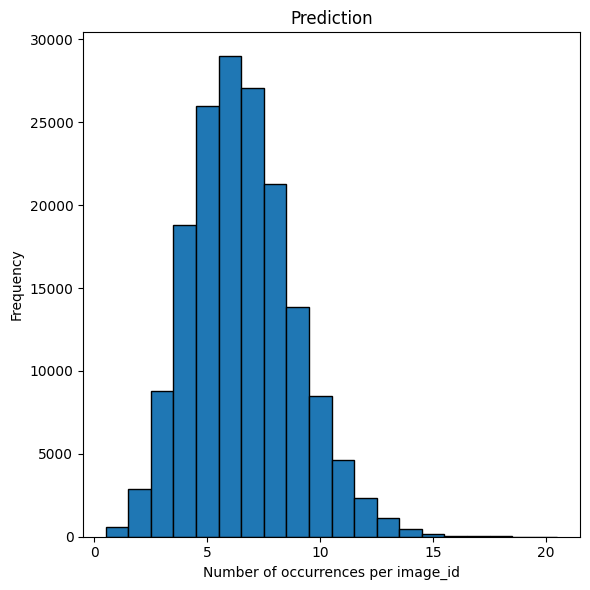

In [108]:
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300, sharey=True)

# plot_occurrence_counts(axes[0], annotation_ground_truth, ylabel='Occurrences', title='Ground Truth Occurrences')
# plot_occurrence_counts(axes[1], annotation_prediction, ylabel='Occurrences', title='Prediction Occurrences')

# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 6), dpi=100, sharey=True)

plot_occurrence_counts(ax, annotation_prediction, ylabel='Frequency', xlabel='Number of occurrences per image_id', title='Prediction')

plt.tight_layout()
plt.show()

In [109]:
def plot_prediction_score(ax, dataframe, xlabel, ylabel, title):
    
    ax.hist(
        dataframe['score'],
        bins=20,
        edgecolor='black',
        align='left'
    )
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)


In [125]:
def dataframe_topk_score(dataframe, K):
    topk_df = (
      dataframe.sort_values('score', ascending=False)
        .groupby(['replay', 'image_id'], group_keys=False)
        .head(K)
    )
    return topk_df.sort_values(['replay', 'image_id'])

In [126]:
top1_annotation_prediction = dataframe_topk_score(annotation_prediction, 1)
top3_annotation_prediction = dataframe_topk_score(annotation_prediction, 3)
top5_annotation_prediction = dataframe_topk_score(annotation_prediction, 5)

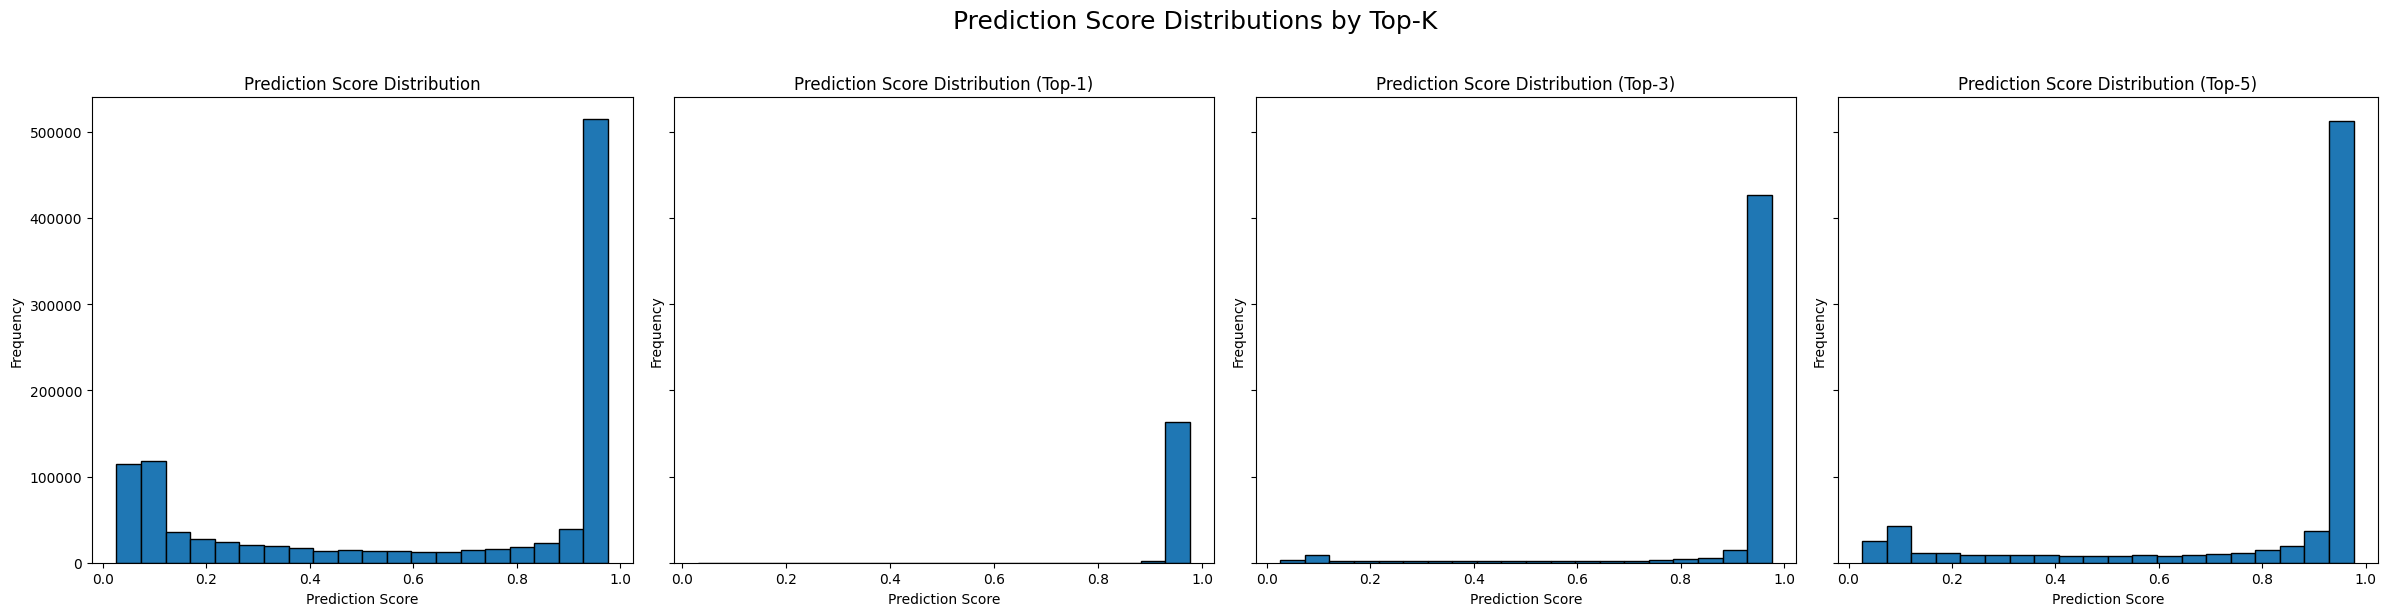

In [129]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100, sharey=True)

plot_prediction_score(axes[0], annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution')
plot_prediction_score(axes[1], top1_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-1)')
plot_prediction_score(axes[2], top3_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-3)')
plot_prediction_score(axes[3], top5_annotation_prediction, xlabel='Prediction Score', ylabel='Frequency', title='Prediction Score Distribution (Top-5)')

fig.suptitle("Prediction Score Distributions by Top-K", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

In [140]:
def compute_iou_box(box1, box2):
    # box: [x, y, w, h] → convert to (x1, y1, x2, y2)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)

    inter_area = max(xi2 - xi1, 0) * max(yi2 - yi1, 0)
    union_area = w1 * h1 + w2 * h2 - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [141]:
def evaluate_iou(gt_df, pred_df, iou_threshold=0.5):
    results = []
    keys_gt = set(zip(gt_df['replay'], gt_df['image_id']))
    keys_pred = set(zip(pred_df['replay'], pred_df['image_id']))
    shared_keys = sorted(keys_gt.intersection(keys_pred))  # 공통된 (replay, id)

    for replay, frame_id in shared_keys:
        gt_boxes = gt_df[(gt_df['replay'] == replay) & (gt_df['image_id'] == frame_id)]
        pred_boxes = pred_df[(pred_df['replay'] == replay) & (pred_df['image_id'] == frame_id)]

        matched_gt = set()
        tp = 0
        fp = 0
        ious = []

        for _, pred_row in pred_boxes.iterrows():
            best_iou = 0
            best_gt_idx = None
            for _, gt_row in gt_boxes.iterrows():
                if gt_row['image_id'] in matched_gt:
                    continue
                iou = compute_iou_box(pred_row['bbox'], gt_row['bbox'])
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_row['image_id']
            if best_iou >= iou_threshold:
                tp += 1
                matched_gt.add(best_gt_idx)
                ious.append(best_iou)
            else:
                fp += 1

        fn = len(gt_boxes) - len(matched_gt)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        results.append({
            'replay': replay,
            'image_id': frame_id,
            'precision': precision,
            'recall': recall,
            'mean_iou': np.mean(ious) if ious else 0,
            'tp': tp,
            'fp': fp,
            'fn': fn
        })

    return pd.DataFrame(results)

In [142]:
def evaluate_single_iou_pre_split(args):
    (replay, image_id), gt_bboxes, pred_bboxes, iou_threshold = args

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    gt_boxes = torch.tensor(gt_bboxes, dtype=torch.float, device=device)
    pred_boxes = torch.tensor(pred_bboxes, dtype=torch.float, device=device)

    matched_gt = set()
    tp, fp, fn = 0, 0, 0
    ious = []

    if len(gt_boxes) == 0:
        tp, fp = 0, len(pred_boxes)
    elif len(pred_boxes) == 0:
        fn = len(gt_boxes)
    else:
        iou_matrix = box_iou(pred_boxes, gt_boxes)
        for pred_idx in range(iou_matrix.size(0)):
            ious_row = iou_matrix[pred_idx]
            best_iou, best_gt_idx = torch.max(ious_row, dim=0)
            if best_iou >= iou_threshold and best_gt_idx.item() not in matched_gt:
                tp += 1
                ious.append(best_iou.item())
                matched_gt.add(best_gt_idx.item())
            else:
                fp += 1
        fn = len(gt_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if tp + fp > 0 else 0
    recall = tp / (tp + fn) if tp + fn > 0 else 0

    return {
        'replay': replay,
        'image_id': image_id,
        'precision': precision,
        'recall': recall,
        'mean_iou': np.mean(ious) if ious else 0,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }


In [143]:
from collections import defaultdict

def make_frame_dict(df):
    frame_dict = defaultdict(list)
    for _, row in df.iterrows():
        key = (row['replay'], row['image_id'])
        frame_dict[key].append(row['bbox'])
    return {k: np.array(v) for k, v in frame_dict.items()}

In [144]:
from multiprocessing import Pool

def evaluate_iou_pre_split_parallel(gt_df, pred_df, iou_threshold=0.5, num_workers=None):
    if num_workers is None:
        from multiprocessing import cpu_count
        num_workers = cpu_count()

    gt_dict = make_frame_dict(gt_df)
    pred_dict = make_frame_dict(pred_df)
    shared_keys = sorted(set(gt_dict) & set(pred_dict))

    args_list = [
        ((replay, image_id), gt_dict[(replay, image_id)], pred_dict[(replay, image_id)], iou_threshold)
        for (replay, image_id) in shared_keys
    ]

    with Pool(processes=num_workers) as pool:
        results = pool.map(evaluate_single_iou_pre_split, args_list)

    return pd.DataFrame(results)


In [145]:
results = evaluate_iou_pre_split_parallel(annotation_ground_truth, annotation_prediction)

In [146]:
results_top1 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top1_annotation_prediction)
results_top3 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top3_annotation_prediction)
results_top5 = evaluate_iou_pre_split_parallel(annotation_ground_truth, top5_annotation_prediction)

In [167]:
def get_statistics(dataframe, label):
    stats = {
        "mean_precision": dataframe["precision"].mean(),
        "mean_recall": dataframe["recall"].mean(),
        "mean_iou": dataframe["mean_iou"].mean(),
        "total_tp": dataframe["tp"].sum(),
        "total_fp": dataframe["fp"].sum(),
        "total_fn": dataframe["fn"].sum()
    }

    # 전체 F1-score (마이크로 방식)
    if stats["total_tp"] > 0:
        stats["f1_score"] = 2 * stats["total_tp"] / (2 * stats["total_tp"] + stats["total_fp"] + stats["total_fn"])
    else:
        stats["f1_score"] = 0.0

    return pd.Series(stats, name=label)


In [173]:
train_set = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep']
test_set = ['6254.rep']

In [175]:
stat_train = get_statistics(results.loc[results['replay'].isin(train_set)], 'total')
stat_train_top1 = get_statistics(results_top1.loc[results_top1['replay'].isin(train_set)], 'top1')
stat_train_top3 = get_statistics(results_top3.loc[results_top3['replay'].isin(train_set)], 'top3')
stat_train_top5 = get_statistics(results_top5.loc[results_top5['replay'].isin(train_set)], 'top5')

In [176]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.concat([stat_train, stat_train_top1, stat_train_top3, stat_train_top5], axis=1)

,total,top1,top3,top5
mean_precision,0.0614,0.1149,0.0972,0.0784
mean_recall,0.0766,0.0230,0.0583,0.0750
mean_iou,0.3094,0.1074,0.2446,0.3079
total_tp,53847.0000,16151.0000,40981.0000,52709.0000
total_fp,898300.0000,124412.0000,378286.0000,617101.0000
total_fn,648968.0000,686664.0000,661834.0000,650106.0000
f1_score,0.0651,0.0383,0.0730,0.0768


In [177]:
stat_test = get_statistics(results.loc[results['replay'].isin(test_set)], 'total')
stat_test_top1 = get_statistics(results_top1.loc[results_top1['replay'].isin(test_set)], 'top1')
stat_test_top3 = get_statistics(results_top3.loc[results_top3['replay'].isin(test_set)], 'top3')
stat_test_top5 = get_statistics(results_top5.loc[results_top5['replay'].isin(test_set)], 'top5')

In [178]:
pd.concat([stat_test, stat_test_top1, stat_test_top3, stat_test_top5], axis=1)

,total,top1,top3,top5
mean_precision,0.0609,0.1371,0.0903,0.0670
mean_recall,0.0634,0.0274,0.0538,0.0603
mean_iou,0.2545,0.1195,0.2205,0.2429
total_tp,7869.0000,3405.0000,6684.0000,7492.0000
total_fp,123714.0000,21434.0000,66262.0000,102437.0000
total_fn,116326.0000,120790.0000,117511.0000,116703.0000
f1_score,0.0615,0.0457,0.0678,0.0640


In [182]:
# results_vanilla['model'] = 'vanilla'
# results_kbrs['model'] = 'kbrs'

# combined_results = pd.concat([results_vanilla, results_kbrs], ignore_index=True)
# summary = combined_results.groupby('model')[['precision', 'recall', 'mean_iou']].mean()

# summary

In [183]:
def compute_frame_coverage(bboxes, frame_size=(128, 128)):
    mask = np.zeros(frame_size, dtype=bool)
    for bbox in bboxes:
        x, y, w, h = map(int, bbox)
        x1, y1 = max(x, 0), max(y, 0)
        x2 = min(x + w, frame_size[1])
        y2 = min(y + h, frame_size[0])
        mask[y1:y2, x1:x2] = True
    return np.sum(mask) / (frame_size[0] * frame_size[1])

In [184]:
def compare_coverage_single_frame(args):
    replay, frame_id, gt_dict, pred_dict, frame_size = args
    gt_bboxes = gt_dict.get((replay, frame_id), [])
    gt_cov = compute_frame_coverage(gt_bboxes, frame_size)

    entry = {
        'replay': replay,
        'image_id': frame_id,
        'gt_coverage': gt_cov,
    }

    for model_name, model_dict in pred_dict.items():
        pred_bboxes = model_dict.get((replay, frame_id), [])
        pred_cov = compute_frame_coverage(pred_bboxes, frame_size)
        entry[f'{model_name}_coverage'] = pred_cov
        entry[f'{model_name}_diff'] = abs(gt_cov - pred_cov)

    return entry

In [185]:
def compare_coverage_multiple_parallel(gt_df, pred_dict, frame_size=(128, 128), num_workers=None):
    if num_workers is None:
        num_workers = os.cpu_count()

    # GT dict
    gt_dict = {
        (row['replay'], row['image_id']): []
        for _, row in gt_df.iterrows()
    }
    for _, row in gt_df.iterrows():
        gt_dict[(row['replay'], row['image_id'])].append(row['bbox'])

    # 각 모델 예측 dict
    pred_dict_by_model = {}
    all_keys = set(gt_dict.keys())

    for model_name, df in pred_dict.items():
        model_dict = {}
        for _, row in df.iterrows():
            key = (row['replay'], row['image_id'])
            model_dict.setdefault(key, []).append(row['bbox'])
            all_keys.add(key)
        pred_dict_by_model[model_name] = model_dict

    # 작업 리스트
    task_args = [
        (replay, image_id, gt_dict, pred_dict_by_model, frame_size)
        for (replay, image_id) in sorted(all_keys)
    ]

    with Pool(processes=num_workers) as pool:
        results = pool.map(compare_coverage_single_frame, task_args)

    return pd.DataFrame(results)


In [186]:
coverage_df = compare_coverage_multiple_parallel(
    gt_df=annotation_ground_truth,
    pred_dict={
        'vanilla': annotation_prediction,
    }
)

Process ForkPoolWorker-249:
Process ForkPoolWorker-250:
Process ForkPoolWorker-251:
Process ForkPoolWorker-248:
Process ForkPoolWorker-235:
Process ForkPoolWorker-227:
Process ForkPoolWorker-232:
Process ForkPoolWorker-201:
Process ForkPoolWorker-214:
Process ForkPoolWorker-230:
Process ForkPoolWorker-205:
Process ForkPoolWorker-236:
Process ForkPoolWorker-229:
Process ForkPoolWorker-228:
Process ForkPoolWorker-231:
Process ForkPoolWorker-211:
Process ForkPoolWorker-209:
Process ForkPoolWorker-239:
Process ForkPoolWorker-210:
Process ForkPoolWorker-218:
Process ForkPoolWorker-204:
Process ForkPoolWorker-208:
Process ForkPoolWorker-207:
Process ForkPoolWorker-213:
Process ForkPoolWorker-221:
Process ForkPoolWorker-222:
Process ForkPoolWorker-212:
Process ForkPoolWorker-202:
Process ForkPoolWorker-206:
Process ForkPoolWorker-223:
Process ForkPoolWorker-219:
Process ForkPoolWorker-226:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):

KeyboardInterrupt: 

In [33]:
coverage_df[['gt_coverage', 'vanilla_coverage', 'vanilla_diff', 'kbrs_coverage', 'kbrs_diff']].describe()

,gt_coverage,vanilla_coverage,vanilla_diff,kbrs_coverage,kbrs_diff
count,140578.000000,140578.000000,140578.000000,140578.000000,140578.000000
mean,0.048611,0.056483,0.011056,0.086297,0.038307
std,0.014087,0.021122,0.010400,0.026588,0.021292
min,0.014648,0.000000,0.000000,0.000000,0.000000
25%,0.037842,0.041138,0.003113,0.068848,0.022461
50%,0.049561,0.057373,0.008057,0.087891,0.037903
75%,0.060059,0.071655,0.015381,0.104980,0.052795
max,0.073242,0.136292,0.077759,0.188293,0.132324


In [38]:
def draw_overview(data, rep_name, frame, ground_truths=None, segmentations_list=None):
    plt.figure(figsize=(6, 6), dpi=300)

    # Terrain & resource
    plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'

    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    # Player 1 & 2 - air
    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

    ax = plt.gca()

    # --- Segmentation Overlays (여러 개) ---
    if segmentations_list is not None:
        colors = ['red', 'blue']  # 두 개 세그먼트용 색상
        for seg_idx, segmentations in enumerate(segmentations_list):
            for seg in segmentations:
                coords = np.array(seg[0]).reshape(-1, 2)
                polygon = patches.Polygon(
                    coords,
                    linewidth=1,
                    edgecolor=colors[seg_idx % len(colors)],
                    linestyle='--',
                    facecolor='none'
                )
                ax.add_patch(polygon)

    # --- Ground Truth Overlay ---
    if ground_truths is not None:
        gt_color = 'green'
        for gt in ground_truths:
            coords = np.array(gt[0]).reshape(-1, 2)
            polygon = patches.Polygon(
                coords,
                linewidth=1,
                edgecolor=gt_color,
                facecolor='none',
                linestyle='--'
            )
            ax.add_patch(polygon)

    plt.title(f'{rep_name} - Frame {frame}', fontsize=10, pad=5, loc='center')
    plt.axis('off')
    plt.tight_layout()

    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(
        f'figures/{rep_name}/{rep_name}_{frame}_Overview.png',
        bbox_inches='tight',
        pad_inches=0
    )
    # plt.show()


In [51]:
# tuple로 공통 키 추출
vanilla_keys = set(zip(annotations_vanilla['replay'], annotations_vanilla['image_id']))
kbrs_keys = set(zip(annotations_kbrs['replay'], annotations_kbrs['image_id']))
common_keys = list(vanilla_keys & kbrs_keys)

# 랜덤 1개 선택 (또는 n개)
random_key = common_keys[np.random.choice(len(common_keys))]
replay, image_id = random_key

print(f"Randomly selected frame: {replay}, image_id: {image_id}")


Randomly selected frame: 212.rep, image_id: 25696


In [52]:
prediction_vanilla_results = annotations_vanilla[
    (annotations_vanilla['replay'] == replay) &
    (annotations_vanilla['image_id'] == image_id)
]
prediction_kbrs_results = annotations_kbrs[
    (annotations_kbrs['replay'] == replay) &
    (annotations_kbrs['image_id'] == image_id)
]

print(f"Vanilla predictions: {len(prediction_vanilla_results)}, KBRS: {len(prediction_kbrs_results)}")


Vanilla predictions: 7, KBRS: 6


In [58]:
image_path = next(
    (img for pred in predictions_vanilla_data
         for img in pred['images']
         if img['id'] == image_id and img['file_name'].startswith(f'{replay}/')),
    None
)

In [57]:
predictions_vanilla_data

[{'info': {'description': 'Predictions for replay 36', 'version': '1.0'},
  'licenses': [],
  'images': [{'id': 0,
    'file_name': '36.rep/0.npy',
    'width': 128,
    'height': 128},
   {'id': 1, 'file_name': '36.rep/1.npy', 'width': 128, 'height': 128},
   {'id': 2, 'file_name': '36.rep/2.npy', 'width': 128, 'height': 128},
   {'id': 3, 'file_name': '36.rep/3.npy', 'width': 128, 'height': 128},
   {'id': 4, 'file_name': '36.rep/4.npy', 'width': 128, 'height': 128},
   {'id': 5, 'file_name': '36.rep/5.npy', 'width': 128, 'height': 128},
   {'id': 6, 'file_name': '36.rep/6.npy', 'width': 128, 'height': 128},
   {'id': 7, 'file_name': '36.rep/7.npy', 'width': 128, 'height': 128},
   {'id': 8, 'file_name': '36.rep/8.npy', 'width': 128, 'height': 128},
   {'id': 9, 'file_name': '36.rep/9.npy', 'width': 128, 'height': 128},
   {'id': 10, 'file_name': '36.rep/10.npy', 'width': 128, 'height': 128},
   {'id': 11, 'file_name': '36.rep/11.npy', 'width': 128, 'height': 128},
   {'id': 12, 'fil

In [60]:
image_path = next(
    (img for pred in predictions_vanilla_data
         for img in pred['images']
         if img['id'] == image_id and img['file_name'].startswith(f'{replay}/')),
    None
)

In [62]:
input_root = os.path.join(os.path.split(os.getcwd())[0], "data", "input", "dst")
input_path = os.path.join(input_root, image_path['file_name'])
input_numpy = np.load(input_path)

rep_name, frame_npy = image_path['file_name'].split('/')

ground_truth_root = os.path.join(os.path.split(os.getcwd())[0], "data", "label", "dst")
ground_truth_path = os.path.join(ground_truth_root, rep_name, 'all_correct.json')
ground_truth_all_correct = json.load(open(ground_truth_path, 'r'))

df_gt = pd.DataFrame(ground_truth_all_correct['annotations'])
ground_truths = df_gt[df_gt['image_id'] == int(frame_npy.split('.')[0])]  # frame_npy = '01234.npy'


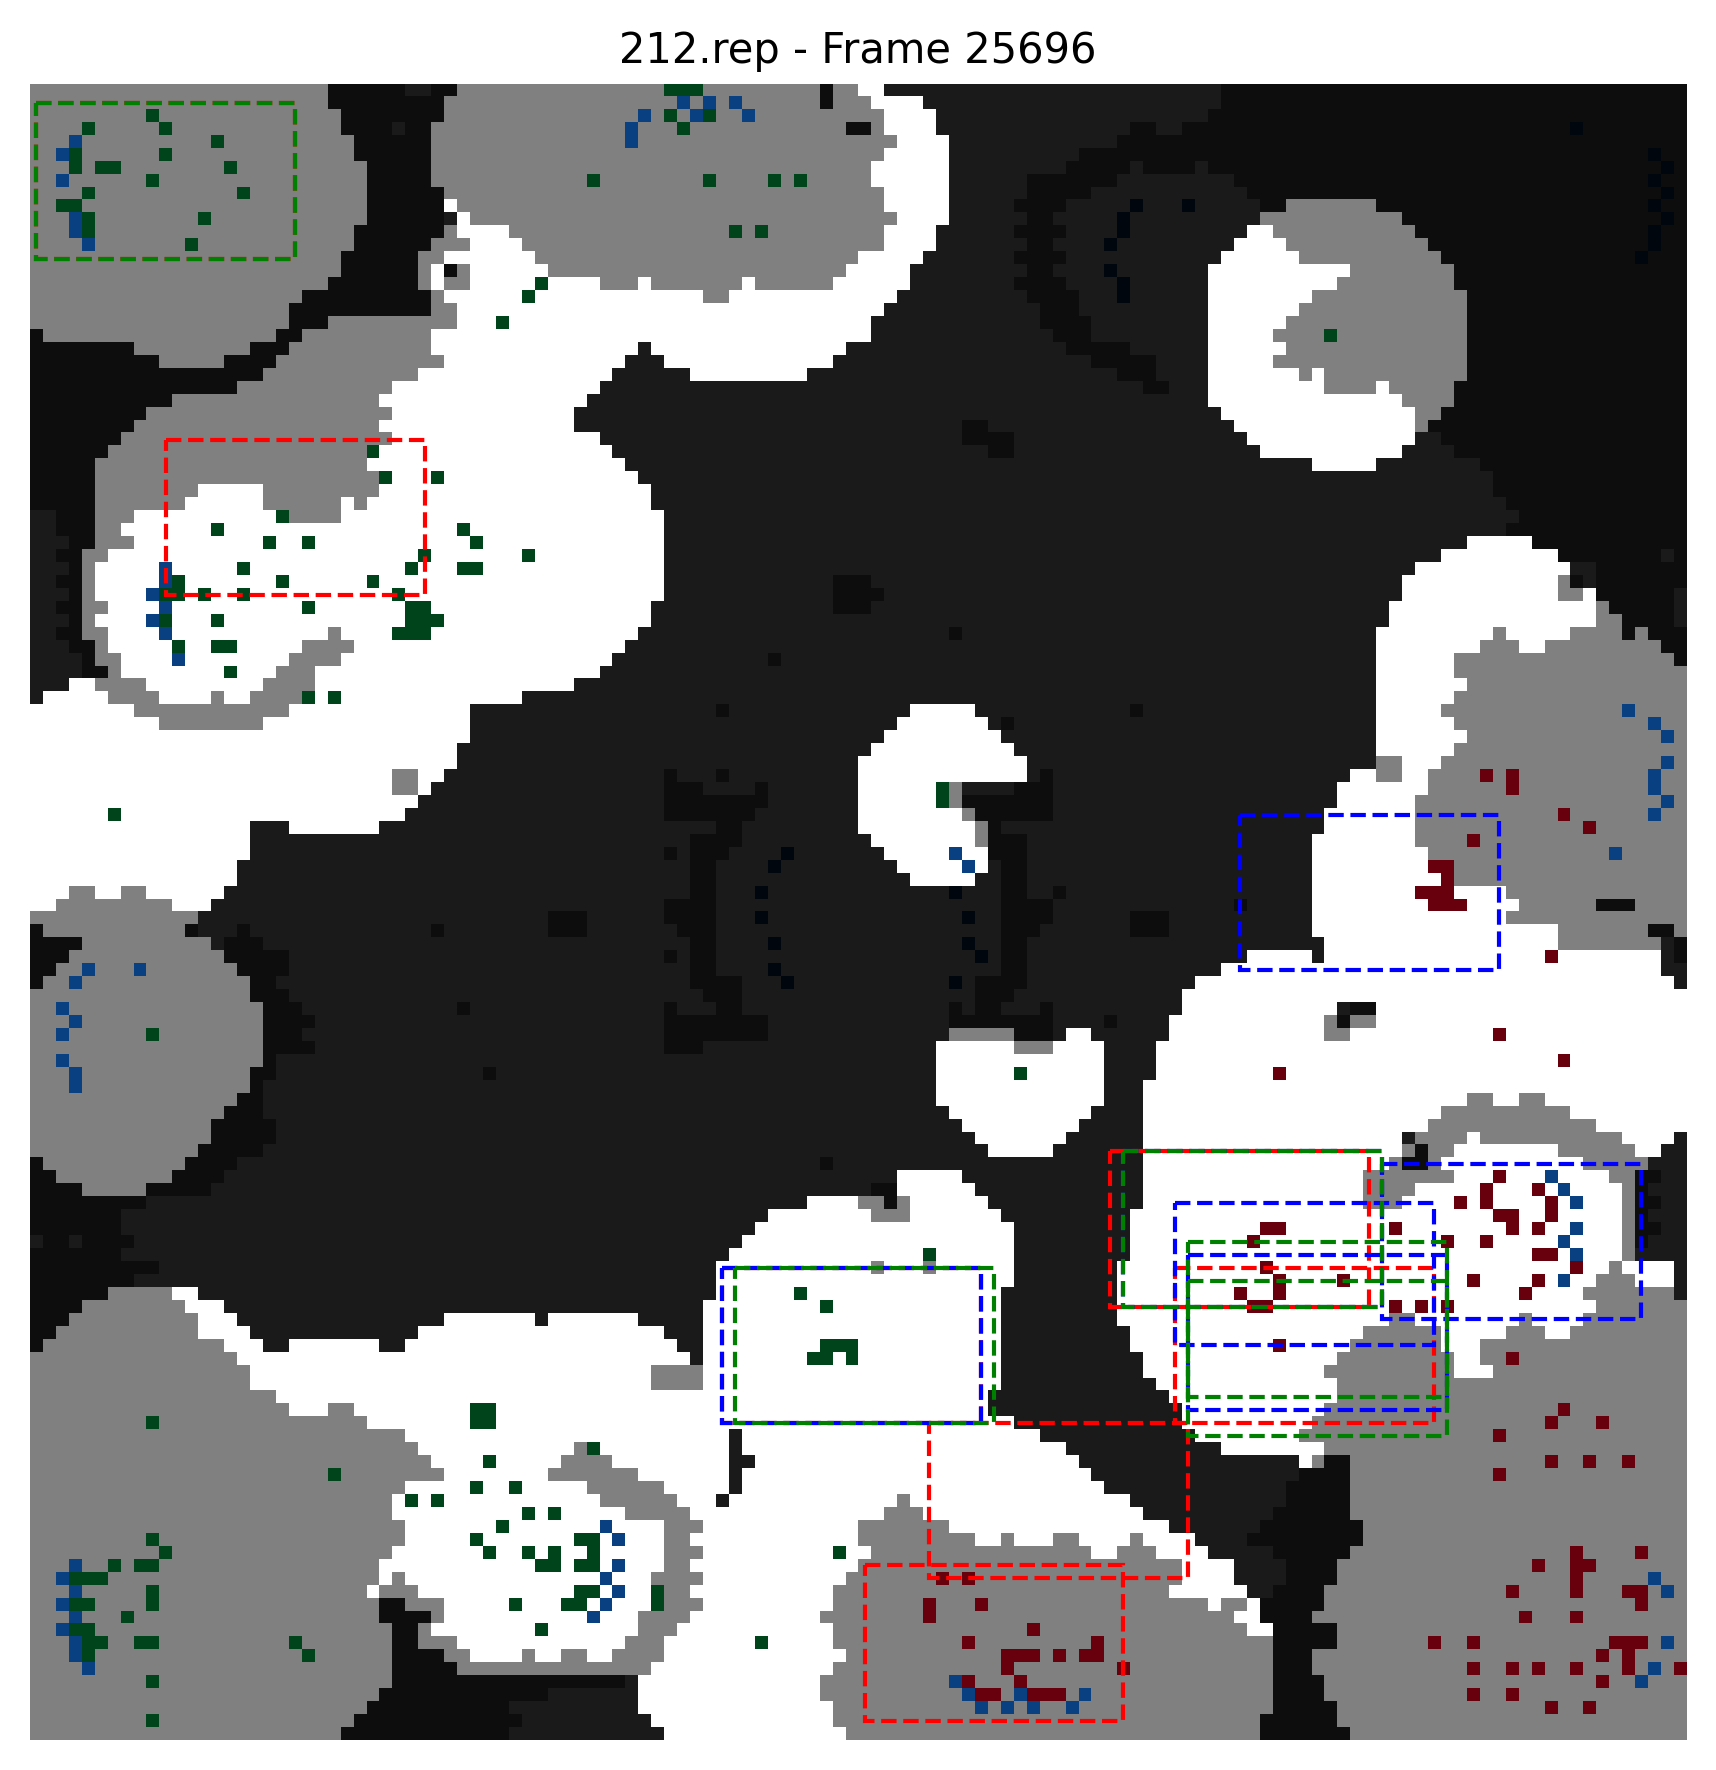

In [64]:
draw_overview(input_numpy,
              rep_name,
              frame_npy.split('.')[0], 
              ground_truths=ground_truths['segmentation'],
              segmentations_list=[prediction_vanilla_results['segmentation'].tolist(), prediction_kbrs_results['segmentation']])

---
## 📌 Section: rtdetr_compare.ipynb


In [1]:
import os
import json
import pandas as pd
from tqdm import tqdm

In [12]:
from sort import Sort

In [2]:
rtdetr_kbrs_win1_275_path = "/mnt/nas/baecm/starcraft-vision/predictions/rtdetr_kbrs_win1_fold1_s123_kbrs025_20260615_045121/model_030/275.rep/all_correct.json"
rtdetr_kbrs_win4_275_path = "/mnt/nas/baecm/starcraft-vision/predictions/rtdetr_kbrs_win4_fold1_s123_kbrs025_20260615_045128/model_030/275.rep/all_correct.json"

maskrcnn_kbrs_win4_275_path = "/mnt/nas/baecm/starcraft-vision/predictions/maskrcnn_win4_kbrs_fold1_s123_kbrs025_base_score_20251219_080334/model_030/275.rep/all_correct.json"
maskrcnn_vanilla_win4_275_path = "/mnt/nas/baecm/starcraft-vision/predictions/maskrcnn_win4_vanilla_fold1_s123_20251201_072032/model_030/275.rep/all_correct.json"

In [3]:
with open(rtdetr_kbrs_win1_275_path, "r") as f:
    rkw1 = json.load(f)

In [4]:
with open(rtdetr_kbrs_win4_275_path, "r") as f:
    rkw4 = json.load(f)

In [5]:
with open(maskrcnn_kbrs_win4_275_path, "r") as f:
    mkw4 = json.load(f)

In [6]:
with open(maskrcnn_vanilla_win4_275_path, "r") as f:
    mvw4 = json.load(f)

In [13]:
def load_coco_and_prepare(coco_input):
    """COCO JSON 데이터를 읽어 Tracking에 적합한 DataFrame으로 정제합니다."""
    if isinstance(coco_input, str):
        with open(coco_input, 'r') as f:
            coco_data = json.load(f)
    elif isinstance(coco_input, dict):
        coco_data = coco_input
    else:
        raise ValueError("입력값은 파일 경로(str) 또는 딕셔너리(dict)여야 합니다.")
        
    df = pd.DataFrame(coco_data['annotations'])
    if df.empty:
        return df

    # [x_min, y_min, w, h] 포맷을 [x1, y1, x2, y2]로 변환
    bbox_df = pd.DataFrame(df['bbox'].tolist(), columns=['x', 'y', 'w', 'h'])
    df['x1'] = bbox_df['x']
    df['y1'] = bbox_df['y']
    df['x2'] = bbox_df['x'] + bbox_df['w']
    df['y2'] = bbox_df['y'] + bbox_df['h']
    
    return df

In [14]:
def get_spatially_distributed_top_k(frame_data, min_distance=30.0, top_k=5):
    """
    공간 클러스터링(Spatial NMS):
    가장 점수가 높은 객체를 선발하고, 지정된 반경(min_distance) 내의 다른 객체는 무시하여
    물리적으로 겹치지 않는 Top-K 지역 대표를 추출합니다.
    """
    # 중심점 계산
    cx = (frame_data['x1'] + frame_data['x2']) / 2.0
    cy = (frame_data['y1'] + frame_data['y2']) / 2.0
    frame_data = frame_data.assign(cx=cx, cy=cy)
    
    # 점수 내림차순 정렬
    frame_data = frame_data.sort_values(by='score', ascending=False)
    
    keep_indices = []
    kept_centers = []
    
    for idx, row in frame_data.iterrows():
        is_too_close = False
        
        # 선발된 대표 객체들과의 유클리드 거리 비교
        for kc in kept_centers:
            dist = np.sqrt((row['cx'] - kc[0])**2 + (row['cy'] - kc[1])**2)
            if dist < min_distance:
                is_too_close = True
                break
                
        # 충분히 멀리 떨어져 있다면 합격
        if not is_too_close:
            keep_indices.append(idx)
            kept_centers.append((row['cx'], row['cy']))
            
        # 목표 K개를 채우면 즉시 종료
        if top_k is not None and len(keep_indices) >= top_k:
            break
            
    return frame_data.loc[keep_indices]

In [15]:
def simulate_tracking(df, top_k_dets=None, min_score_threshold=0.0, min_distance=30.0):
    """
    정제된 프레임 데이터를 순회하며 공간 분산 필터링 후 SORT 추적을 수행합니다.
    """
    tracker = Sort(max_age=3, min_hits=3, iou_threshold=0.3)
    tracked_results = []
    frame_ids = sorted(df['image_id'].unique())
    
    for frame_id in tqdm(frame_ids, desc="Tracking Objects", unit="frame"):
        frame_data = df[df['image_id'] == frame_id]
        
        if not frame_data.empty:
            # 1. 최소 점수 미달 노이즈 컷
            if min_score_threshold > 0.0:
                frame_data = frame_data[frame_data['score'] >= min_score_threshold]
                
            # 2. 공간 분산이 보장된 Top-K 지역 대표 추출
            if top_k_dets is not None and not frame_data.empty:
                frame_data = get_spatially_distributed_top_k(
                    frame_data, 
                    min_distance=min_distance, 
                    top_k=top_k_dets
                )
                
        # 필터링 후 남은 객체가 없으면 칼만 필터 빈 업데이트 처리
        if frame_data.empty:
            tracker.update(np.empty((0, 5))) 
            continue

        dets = frame_data[['x1', 'y1', 'x2', 'y2', 'score']].values
        tracks = tracker.update(dets)
        
        for track in tracks:
            tracked_results.append({
                'image_id': frame_id,
                'track_id': int(track[4]),
                'bbox_xyxy': [track[0], track[1], track[2], track[3]]
            })
            
    return pd.DataFrame(tracked_results)

In [35]:
from tqdm import tqdm
import pandas as pd
import numpy as np
from sort import Sort

def get_spatially_distributed_top_k(frame_data, min_distance=30.0, top_k=5):
    """
    공간 클러스터링(Spatial NMS):
    가장 점수가 높은 객체를 선발하고, 지정된 반경(min_distance) 내의 다른 객체는 무시하여
    물리적으로 겹치지 않는 Top-K 지역 대표를 추출합니다.
    """
    cx = (frame_data['x1'] + frame_data['x2']) / 2.0
    cy = (frame_data['y1'] + frame_data['y2']) / 2.0
    frame_data = frame_data.assign(cx=cx, cy=cy)
    
    frame_data = frame_data.sort_values(by='score', ascending=False)
    
    keep_indices = []
    kept_centers = []
    
    for idx, row in frame_data.iterrows():
        is_too_close = False
        
        for kc in kept_centers:
            dist = np.sqrt((row['cx'] - kc[0])**2 + (row['cy'] - kc[1])**2)
            if dist < min_distance:
                is_too_close = True
                break
                
        if not is_too_close:
            keep_indices.append(idx)
            kept_centers.append((row['cx'], row['cy']))
            
        if top_k is not None and len(keep_indices) >= top_k:
            break
            
    return frame_data.loc[keep_indices]


def simulate_tracking_multi(df, top_k_dets=3, min_score_threshold=0.0, min_distance=30.0):
    """
    한 번의 루프(Single Pass)로 다음 4가지 결과를 동시에 산출합니다.
    (Tracked Top-K에는 공간 분산 클러스터링이 적용됩니다.)
    """
    tracker_all = Sort(max_age=3, min_hits=3, iou_threshold=0.3)
    tracker_topk = Sort(max_age=3, min_hits=3, iou_threshold=0.3)
     n
    results_raw_all = []
    results_raw_top1 = []
    results_tracked_all = []
    results_tracked_topk = []
    
    frame_ids = sorted(df['image_id'].unique())
    
    for frame_id in tqdm(frame_ids, desc="Processing All Pipelines", unit="frame"):
        frame_data = df[df['image_id'] == frame_id]
        
        if min_score_threshold > 0.0 and not frame_data.empty:
            frame_data = frame_data[frame_data['score'] >= min_score_threshold]
            
        if frame_data.empty:
            tracker_all.update(np.empty((0, 5)))
            tracker_topk.update(np.empty((0, 5)))
            continue

        frame_data = frame_data.sort_values(by='score', ascending=False)

        # ==========================================
        # [A & B] Raw 탐지 결과 저장
        # ==========================================
        for _, row in frame_data.iterrows():
            results_raw_all.append({
                'image_id': frame_id,
                'bbox_xyxy': [row['x1'], row['y1'], row['x2'], row['y2']],
                'score': row['score'] 
            })
            
        top1_row = frame_data.iloc[0]
        results_raw_top1.append({
            'image_id': frame_id,
            'bbox_xyxy': [top1_row['x1'], top1_row['y1'], top1_row['x2'], top1_row['y2']],
            'score': top1_row['score']
        })

        # ==========================================
        # [C] 전체 탐지 (All) 추적 실행
        # ==========================================
        dets_all = frame_data[['x1', 'y1', 'x2', 'y2', 'score']].values
        tracks_all = tracker_all.update(dets_all)
        
        for track in tracks_all:
            results_tracked_all.append({
                'image_id': frame_id,
                'track_id': int(track[4]),
                'bbox_xyxy': [track[0], track[1], track[2], track[3]]
            })

        # ==========================================
        # [D] Top-K 탐지 추적 실행 (★ 공간 분산 로직 적용 ★)
        # ==========================================
        # 단순 .head()가 아니라, 거리가 떨어진 3곳(top_k)의 대표를 뽑습니다.
        topk_data = get_spatially_distributed_top_k(
            frame_data, 
            min_distance=min_distance, 
            top_k=top_k_dets
        )
        
        dets_topk = topk_data[['x1', 'y1', 'x2', 'y2', 'score']].values
        tracks_topk = tracker_topk.update(dets_topk)
        
        for track in tracks_topk:
            results_tracked_topk.append({
                'image_id': frame_id,
                'track_id': int(track[4]),
                'bbox_xyxy': [track[0], track[1], track[2], track[3]]
            })

    return (
        pd.DataFrame(results_raw_all), 
        pd.DataFrame(results_raw_top1), 
        pd.DataFrame(results_tracked_all), 
        pd.DataFrame(results_tracked_topk)
    )

In [36]:
_ = load_coco_and_prepare(mkw4)
mkw4_all, mkw4_top1, mkw4_sort_all, mkw4_sort_top3 = simulate_tracking_multi(_, top_k_dets=3)

Processing All Pipelines: 100%|█████████████████████████| 66679/66679 [06:31<00:00, 170.21frame/s]


In [37]:
_ = load_coco_and_prepare(mvw4)
mvw4_all, mvw4_top1, mvw4_sort_all, mvw4_sort_top3 = simulate_tracking_multi(_, top_k_dets=3)

Processing All Pipelines: 100%|█████████████████████████| 66673/66673 [06:38<00:00, 167.36frame/s]


In [38]:
_ = load_coco_and_prepare(rkw4)
rkw4_all, rkw4_top1, rkw4_sort_all, rkw4_sort_top3 = simulate_tracking_multi(_, top_k_dets=3)

Processing All Pipelines: 100%|█████████████████████████| 66667/66667 [06:24<00:00, 173.47frame/s]


In [39]:
def select_sequence_range(df, start, finish):
    return df.iloc[df["image_id"] >= start].iloc[df["image_id"] < finish]

In [40]:
mkw4_all_seq = select_sequence_range(mkw4_all, 30000, 32400)
mkw4_top1_seq = select_sequence_range(mkw4_top1, 30000, 32400)
mkw4_sort_all_seq = select_sequence_range(mkw4_sort_all, 30000, 32400)
mkw4_sort_top3_seq = select_sequence_range(mkw4_sort_top3, 30000, 32400)

mvw4_all_seq = select_sequence_range(mvw4_all, 30000, 32400) 
mvw4_top1_seq = select_sequence_range(mvw4_top1, 30000, 32400) 
mvw4_sort_all_seq = select_sequence_range(mvw4_sort_all, 30000, 32400) 
mvw4_sort_top3_seq = select_sequence_range(mvw4_sort_top3, 30000, 32400) 

rkw4_all_seq = select_sequence_range(rkw4_all, 30000, 32400)
rkw4_top1_seq = select_sequence_range(rkw4_top1, 30000, 32400)
rkw4_sort_all_seq = select_sequence_range(rkw4_sort_all, 30000, 32400)
rkw4_sort_top3_seq = select_sequence_range(rkw4_sort_top3, 30000, 32400)

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from tqdm import tqdm

def adjust_bbox_for_pyplot(bbox, fixed_w=20, fixed_h=12):
    x1, y1, x2, y2 = bbox
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    x_min = cx - (fixed_w / 2.0)
    y_min = cy - (fixed_h / 2.0)
    return x_min, y_min, fixed_w, fixed_h

def create_tracking_animation(tracking_df, output_file="tracking_output", grid_size=128, fps=24, save_mp4=True, save_gif=False, title="Tracking Process"):
    fig, ax = plt.subplots(figsize=(6, 6))
    frame_ids = sorted(tracking_df['image_id'].unique())
    
    cmap = plt.get_cmap('tab20')
    color_map = {}
    
    def update(frame_index):
        ax.clear()
        frame_id = frame_ids[frame_index]
        
        ax.set_xlim(0, grid_size)
        ax.set_ylim(grid_size, 0) 
        ax.set_title(f"{title} - Frame: {frame_id}")
        
        ax.set_xticks(np.arange(0, grid_size+1, 16))
        ax.set_yticks(np.arange(0, grid_size+1, 16))
        ax.grid(True, linestyle='--', alpha=0.5)
        
        current_data = tracking_df[tracking_df['image_id'] == frame_id]
        
        has_track_id = 'track_id' in current_data.columns
        
        # [핵심 수정 부분] 
        local_idx = 0 # Raw 데이터용 프레임 내 순위 인덱스
        
        for _, row in current_data.iterrows():
            if has_track_id:
                # 1. 추적 데이터(Tracked)인 경우: 고유 UID를 그대로 사용 (색상 일관성 유지)
                uid = int(row['track_id'])
                label_text = f"ID: {uid}"
            else:
                # 2. 원본 데이터(Raw)인 경우: 현재 프레임 내의 '점수 순위'를 임시 ID로 사용
                # (가장 점수가 높은 객체는 항상 같은 색으로 표시됨)
                uid = local_idx 
                label_text = f"Rank: {uid + 1}"
                local_idx += 1
            
            original_bbox = row['bbox_xyxy']
            x_min, y_min, w, h = adjust_bbox_for_pyplot(original_bbox, fixed_w=20, fixed_h=12)
            
            # 색상 매핑 (딕셔너리에 없으면 새로운 색상 할당)
            if uid not in color_map:
                color_map[uid] = cmap(len(color_map) % 20)
            color = color_map[uid]
            
            # 바운딩 박스 렌더링
            rect = patches.Rectangle((x_min, y_min), w, h, 
                                     linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            
            # 텍스트 렌더링
            ax.text(x_min, y_min - 2, label_text, color=color, 
                    fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    ani = FuncAnimation(fig, update, frames=len(frame_ids), interval=1000/fps)
    
    print(f"총 {len(frame_ids)}개의 프레임 렌더링을 시작합니다... [{title}]")

    if save_mp4:
        with tqdm(total=len(frame_ids), desc="Rendering MP4", unit="frame") as pbar:
            def update_progress_mp4(current_frame, total_frames):
                pbar.update(1)
            ani.save(f"{output_file}.mp4", writer='ffmpeg', fps=fps, progress_callback=update_progress_mp4)
            
    if save_gif:
        with tqdm(total=len(frame_ids), desc="Rendering GIF", unit="frame") as pbar:
            def update_progress_gif(current_frame, total_frames):
                pbar.update(1)
            ani.save(f"{output_file}.gif", writer='pillow', fps=fps, progress_callback=update_progress_gif)
    
    print(f"렌더링 완료! 파일이 저장되었습니다: {output_file}")
    plt.close(fig)

In [34]:
# from tqdm import tqdm
# import pandas as pd
# import numpy as np
# from sort import Sort

# def get_spatially_distributed_top_k(frame_data, min_distance=30.0, top_k=5):
#     """
#     점수가 높은 순으로 탐색하되, 이미 선택된 '지역 대표'와 
#     min_distance 이내로 가까운 위치에 있는 객체는 무시합니다.
#     """
#     # 1. 중심점 계산 (그룹화의 기준)
#     cx = (frame_data['x1'] + frame_data['x2']) / 2.0
#     cy = (frame_data['y1'] + frame_data['y2']) / 2.0
#     frame_data = frame_data.assign(cx=cx, cy=cy)
    
#     # 2. Score 기준으로 내림차순 정렬 (가장 확신하는 객체부터 탐색)
#     frame_data = frame_data.sort_values(by='score', ascending=False)
    
#     keep_indices = []
#     kept_centers = []
    
#     for idx, row in frame_data.iterrows():
#         is_too_close = False
        
#         # 3. 이미 선발된 지역 대표들과의 거리 측정
#         for kc in kept_centers:
#             dist = np.sqrt((row['cx'] - kc[0])**2 + (row['cy'] - kc[1])**2)
#             if dist < min_distance:
#                 is_too_close = True
#                 break  # 하나라도 너무 가까우면 이 객체는 탈락
                
#         # 4. 충분히 멀리 떨어져 있다면 새로운 지역 대표로 선발
#         if not is_too_close:
#             keep_indices.append(idx)
#             kept_centers.append((row['cx'], row['cy']))
            
#         # 5. 원하는 K개를 모두 찾았다면 조기 종료
#         if top_k is not None and len(keep_indices) >= top_k:
#             break
            
#     # 선발된 인덱스만 필터링하여 반환
#     return frame_data.loc[keep_indices]


# def simulate_tracking(df, top_k_dets=None, min_score_threshold=0.0, min_distance=30.0):
#     tracker = Sort(max_age=3, min_hits=3, iou_threshold=0.3)
#     tracked_results = []
#     frame_ids = sorted(df['image_id'].unique())
    
#     for frame_id in tqdm(frame_ids, desc="Tracking Objects", unit="frame"):
#         frame_data = df[df['image_id'] == frame_id]
        
#         if frame_data.empty:
#             tracker.update(np.empty((0, 5))) 
#             continue
            
#         # 1. 최소 점수 미달 노이즈 컷
#         if min_score_threshold > 0.0:
#             frame_data = frame_data[frame_data['score'] >= min_score_threshold]
            
#         # =======================================================
#         # ★ [수정된 로직] 단순 Top-K가 아닌 '공간적 분산이 보장된' Top-K 추출
#         # =======================================================
#         if top_k_dets is not None and not frame_data.empty:
#             frame_data = get_spatially_distributed_top_k(
#                 frame_data, 
#                 min_distance=min_distance, # 이 반경 내에서는 1등 하나만 살아남음
#                 top_k=top_k_dets
#             )
#         # =======================================================
        
#         if frame_data.empty:
#             tracker.update(np.empty((0, 5))) 
#             continue

#         dets = frame_data[['x1', 'y1', 'x2', 'y2', 'score']].values
#         tracks = tracker.update(dets)
        
#         for track in tracks:
#             tracked_results.append({
#                 'image_id': frame_id,
#                 'track_id': int(track[4]),
#                 'bbox_xyxy': [track[0], track[1], track[2], track[3]]
#             })
            
#     return pd.DataFrame(tracked_results)

# # --- 실행 예시 ---
# # 반경 30 픽셀 내에서는 가장 점수가 높은 1개만 남기고, 화면 전체에서 최대 5개의 독립된 구역을 추적
# # tracking_result_df = simulate_tracking(coco_df, top_k_dets=5, min_score_threshold=0.3, min_distance=30.0)

In [48]:
create_tracking_animation(mvw4_all_seq, output_file="mvw4_all_seq", title="Mask RCNN", grid_size=128, fps=24)

총 2400개의 프레임 렌더링을 시작합니다... [Mask RCNN]


Rendering GIF: 100%|███████████████████████████████████████| 2400/2400 [06:23<00:00,  6.25frame/s]

렌더링 완료! 파일이 저장되었습니다: mvw4_all_seq


In [55]:
create_tracking_animation(mkw4_all_seq, output_file="mkw4_all_seq", title="Mask RCNN + Saliency Guide", grid_size=128, fps=24)

총 2400개의 프레임 렌더링을 시작합니다... [Mask RCNN + Saliency Guide]


Rendering MP4: 100%|███████████████████████████████████████| 2400/2400 [04:22<00:00,  9.13frame/s]

렌더링 완료! 파일이 저장되었습니다: mkw4_all_seq


In [56]:
create_tracking_animation(mkw4_sort_all_seq, output_file="mkw4_sort_all_seq", title="Mask RCNN + Saliency Guide + Post-processing (all)", grid_size=128, fps=24)

총 2400개의 프레임 렌더링을 시작합니다... [Mask RCNN + Saliency Guide + Post-processing (all)]


Rendering MP4: 100%|███████████████████████████████████████| 2400/2400 [04:20<00:00,  9.22frame/s]

렌더링 완료! 파일이 저장되었습니다: mkw4_sort_all_seq


In [57]:
create_tracking_animation(mkw4_sort_top3_seq, output_file="mkw4_sort_top3_seq", title="Mask RCNN + Saliency Guide + Post-processing (top-3)", grid_size=128, fps=24)

총 2400개의 프레임 렌더링을 시작합니다... [Mask RCNN + Saliency Guide + Post-processing (top-3)]


Rendering MP4: 100%|███████████████████████████████████████| 2400/2400 [03:54<00:00, 10.22frame/s]

렌더링 완료! 파일이 저장되었습니다: mkw4_sort_top3_seq


In [65]:
create_tracking_animation(rkw4_all_seq, output_file="rkw4_all_seq", title="RT-DETR + Saliency (all)", grid_size=128, fps=24)

총 2400개의 프레임 렌더링을 시작합니다... [RT-DETR + Saliency (all)]


Rendering MP4: 100%|███████████████████████████████████████| 2400/2400 [04:07<00:00,  9.70frame/s]

렌더링 완료! 파일이 저장되었습니다: rkw4_all_seq


In [62]:
create_tracking_animation(rkw4_top1_seq, output_file="rkw4_top1_seq", title="RT-DETR + Saliency (top-1)", grid_size=128, fps=24)

총 2400개의 프레임 렌더링을 시작합니다... [RT-DETR + Saliency (top-1)]


Rendering MP4: 100%|███████████████████████████████████████| 2400/2400 [03:39<00:00, 10.94frame/s]

렌더링 완료! 파일이 저장되었습니다: rkw4_top1_seq


In [63]:
create_tracking_animation(rkw4_sort_all_seq, output_file="rkw4_sort_all_seq", title="RT-DETR + Saliency + Post-processing (all)", grid_size=128, fps=24)

총 2385개의 프레임 렌더링을 시작합니다... [RT-DETR + Saliency + Post-processing (all)]


Rendering MP4: 100%|███████████████████████████████████████| 2385/2385 [04:01<00:00,  9.87frame/s]

렌더링 완료! 파일이 저장되었습니다: rkw4_sort_all_seq


In [64]:
create_tracking_animation(rkw4_sort_top3_seq, output_file="rkw4_sort_top3_seq", title="RT-DETR + Saliency + Post-processing (top-3)", grid_size=128, fps=24)

총 2287개의 프레임 렌더링을 시작합니다... [RT-DETR + Saliency + Post-processing (top-3)]


Rendering MP4: 100%|███████████████████████████████████████| 2287/2287 [03:41<00:00, 10.32frame/s]

렌더링 완료! 파일이 저장되었습니다: rkw4_sort_top3_seq


In [109]:
import pandas as pd
import numpy as np

def analyze_track_consistency(tracking_df, fps=24, jump_threshold=50.0, gap_tolerance=3):
    """
    정답(GT) 없이 DataFrame 자체의 물리적 타당성을 기반으로 추적 일관성을 평가합니다.
    - jump_threshold: 1프레임당 이동할 수 있는 최대 허용 픽셀 거리
    - gap_tolerance: 추적이 끊겨도 같은 객체로 인정해 주는 최대 누락 프레임 수
    """
    df = tracking_df.copy()
    
    # 1. 중심점 좌표(cx, cy) 계산
    bbox = pd.DataFrame(df['bbox_xyxy'].tolist(), columns=['x1', 'y1', 'x2', 'y2'])
    df['cx'] = (bbox['x1'] + bbox['x2']) / 2.0
    df['cy'] = (bbox['y1'] + bbox['y2']) / 2.0
    
    # 프레임 순서대로 정렬
    df = df.sort_values(by=['track_id', 'image_id'])
    
    # 이전 프레임 데이터 및 프레임 차이(gap) 계산
    df['prev_frame'] = df.groupby('track_id')['image_id'].shift(1)
    df['prev_cx'] = df.groupby('track_id')['cx'].shift(1)
    df['prev_cy'] = df.groupby('track_id')['cy'].shift(1)
    
    # 프레임 간격(Delta Frame) 및 픽셀 이동 거리 계산
    df['frame_diff'] = df['image_id'] - df['prev_frame']
    df['pixel_jump'] = np.sqrt((df['cx'] - df['prev_cx'])**2 + (df['cy'] - df['prev_cy'])**2)
    
    # ========================================================
    # ★ 핵심 로직: 프레임 간격에 따른 상태 분류
    # ========================================================
    
    # Case 1: 연속 탐지 중 비정상 도약 (1프레임 만에 임계값 초과)
    df['switch_consecutive'] = (df['frame_diff'] == 1) & (df['pixel_jump'] > jump_threshold)
    
    # Case 2: 허용 범위 내 누락 후 복귀 성공 (정상적인 Occlusion 처리)
    # 누락된 프레임 수만큼 허용 거리도 비례해서 늘려줍니다. (선형 등속 운동 가정)
    max_allowed_jump = jump_threshold * df['frame_diff']
    df['valid_occlusion'] = (df['frame_diff'] > 1) & (df['frame_diff'] <= gap_tolerance) & (df['pixel_jump'] <= max_allowed_jump)
    
    # Case 3: 허용 범위 내 누락이 있었으나, 엉뚱한 위치에서 나타남 (가려진 사이 다른 객체로 ID 튐)
    df['switch_gap'] = (df['frame_diff'] > 1) & (df['frame_diff'] <= gap_tolerance) & (df['pixel_jump'] > max_allowed_jump)
    
    # Case 4: 허용 범위를 초과하여 너무 오랜만에 과거 ID가 부활함 (Tracker 오류)
    df['switch_over_tolerance'] = df['frame_diff'] > gap_tolerance

    # ========================================================
    
    # Track ID별로 통계 집계
    track_stats = df.groupby('track_id').agg(
        frame_count=('image_id', 'count'),
        first_frame=('image_id', 'min'),
        last_frame=('image_id', 'max'),
        valid_occlusions=('valid_occlusion', 'sum'),
        err_consecutive=('switch_consecutive', 'sum'),
        err_gap=('switch_gap', 'sum'),
        err_over_tolerance=('switch_over_tolerance', 'sum')
    )
    
    track_stats['lifespan'] = track_stats['last_frame'] - track_stats['first_frame'] + 1
    
    # 총 에러(비정상 도약) 횟수 합산
    track_stats['total_id_switches'] = track_stats['err_consecutive'] + track_stats['err_gap'] + track_stats['err_over_tolerance']
    
    # 불리언(True/False) 합산을 정수형으로 변환
    cols_to_int = ['valid_occlusions', 'err_consecutive', 'err_gap', 'err_over_tolerance', 'total_id_switches']
    track_stats[cols_to_int] = track_stats[cols_to_int].astype(int)
    
    # --- 전체 요약 리포트 출력 ---
    print("========== 추적 일관성 정밀 진단 리포트 ==========")
    print(f"분석 대상 고유 객체(UID) 수: {len(track_stats)}")
    print(f"평균 추적 수명: {track_stats['lifespan'].mean():.1f} 프레임")
    
    short_tracks = len(track_stats[track_stats['lifespan'] < (fps * 1.0)])
    print(f"1초({fps}프레임) 미만 단명 객체 비율: {short_tracks/len(track_stats)*100:.1f}%")
    print("-" * 50)
    print(f"✅ 정상적인 가림(Occlusion) 극복 횟수: {track_stats['valid_occlusions'].sum()} 회")
    print(f"❌ 총 ID Switch 의심 횟수: {track_stats['total_id_switches'].sum()} 회")
    print(f"   ├─ 연속 프레임 도약 (단순 추적 튐): {track_stats['err_consecutive'].sum()} 회")
    print(f"   ├─ 짧은 가림 중 도약 (다른 객체로 옮겨감): {track_stats['err_gap'].sum()} 회")
    print(f"   └─ 긴 공백 후 부활 (과거 ID 잘못 꺼냄): {track_stats['err_over_tolerance'].sum()} 회")
    print("==================================================\n")
    
    return track_stats, df

# --- 실행 예시 ---
# gap_tolerance는 SORT의 'max_age' 파라미터 값과 동일하거나 약간 크게 설정하는 것이 좋습니다.
# stats_df, detailed_df = analyze_track_consistency(b, fps=24, jump_threshold=30.0, gap_tolerance=3)

In [110]:
# 실행 예시
rkw1_track_stats_df, rkw1_detailed_df = analyze_track_consistency(rkw1_tracked, fps=24, jump_threshold=30.0, gap_tolerance=5)
rkw4_track_stats_df, rkw4_detailed_df = analyze_track_consistency(rkw4_tracked, fps=24, jump_threshold=30.0, gap_tolerance=5)
mkw4_track_stats_df, mkw4_detailed_df = analyze_track_consistency(mkw4_tracked, fps=24, jump_threshold=30.0, gap_tolerance=5)
mvw4_track_stats_df, mvw4_detailed_df = analyze_track_consistency(mvw4_tracked, fps=24, jump_threshold=30.0, gap_tolerance=5)

========== 추적 일관성 정밀 진단 리포트 ==========
분석 대상 고유 객체(UID) 수: 3317
평균 추적 수명: 39.6 프레임
1초(24프레임) 미만 단명 객체 비율: 66.7%
--------------------------------------------------
✅ 정상적인 가림(Occlusion) 극복 횟수: 1434 회
❌ 총 ID Switch 의심 횟수: 733 회
   ├─ 연속 프레임 도약 (단순 추적 튐): 0 회
   ├─ 짧은 가림 중 도약 (다른 객체로 옮겨감): 0 회
   └─ 긴 공백 후 부활 (과거 ID 잘못 꺼냄): 733 회

========== 추적 일관성 정밀 진단 리포트 ==========
분석 대상 고유 객체(UID) 수: 3712
평균 추적 수명: 38.1 프레임
1초(24프레임) 미만 단명 객체 비율: 66.9%
--------------------------------------------------
✅ 정상적인 가림(Occlusion) 극복 횟수: 1768 회
❌ 총 ID Switch 의심 횟수: 906 회
   ├─ 연속 프레임 도약 (단순 추적 튐): 0 회
   ├─ 짧은 가림 중 도약 (다른 객체로 옮겨감): 0 회
   └─ 긴 공백 후 부활 (과거 ID 잘못 꺼냄): 906 회

========== 추적 일관성 정밀 진단 리포트 ==========
분석 대상 고유 객체(UID) 수: 1681
평균 추적 수명: 102.4 프레임
1초(24프레임) 미만 단명 객체 비율: 60.4%
--------------------------------------------------
✅ 정상적인 가림(Occlusion) 극복 횟수: 773 회
❌ 총 ID Switch 의심 횟수: 354 회
   ├─ 연속 프레임 도약 (단순 추적 튐): 0 회
   ├─ 짧은 가림 중 도약 (다른 객체로 옮겨감): 0 회
   └─ 긴 공백 후 부활 (과거 ID 잘못 꺼냄): 354 회

========== 추적

In [105]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def analyze_spatial_coverage(tracking_df, grid_size=128):
    """
    128x128 그리드 내에서 매 프레임별 바운딩 박스들이 
    실제로 커버하는 순수 면적(합집합)과 비율을 계산합니다.
    """
    df = tracking_df.copy()
    
    # 결과를 담을 리스트
    coverage_results = []
    
    # 프레임 오름차순 정렬
    frame_ids = sorted(df['image_id'].unique())
    total_area = grid_size * grid_size # 128 * 128 = 16384
    
    for frame_id in tqdm(frame_ids, desc="Calculating Coverage", unit="frame"):
        frame_data = df[df['image_id'] == frame_id]
        
        # 1. 128x128 크기의 False로 채워진 빈 캔버스(Mask) 생성
        mask = np.zeros((grid_size, grid_size), dtype=bool)
        
        for _, row in frame_data.iterrows():
            # 박스 좌표 추출 (앞서 20x12로 고정한 좌표를 사용하셔도 됩니다)
            x1, y1, x2, y2 = row['bbox_xyxy']
            
            # 2. 캔버스 밖으로 나가는 좌표를 0 ~ 128 사이로 잘라냄(Clipping)
            # (박스가 화면 모서리에 걸쳐 있을 때 인덱스 에러 방지)
            x1_clip, x2_clip = np.clip([int(x1), int(x2)], 0, grid_size)
            y1_clip, y2_clip = np.clip([int(y1), int(y2)], 0, grid_size)
            
            # 3. 박스 영역을 True로 활성화 (겹치는 부분은 알아서 덮어씌워짐)
            # 주의: numpy 배열 슬라이싱은 [y축, x축] 순서입니다.
            mask[y1_clip:y2_clip, x1_clip:x2_clip] = True
            
        # 4. 활성화된(True) 픽셀의 총합 = 실제 커버된 면적
        covered_pixels = np.sum(mask)
        coverage_ratio = (covered_pixels / total_area) * 100.0
        
        coverage_results.append({
            'image_id': frame_id,
            'object_count': len(frame_data),
            'covered_pixels': covered_pixels,
            'coverage_ratio_%': coverage_ratio
        })
        
    # DataFrame으로 변환
    coverage_df = pd.DataFrame(coverage_results)
    
    # --- 전체 요약 리포트 출력 ---
    mean_ratio = coverage_df['coverage_ratio_%'].mean()
    max_ratio = coverage_df['coverage_ratio_%'].max()
    max_frame = coverage_df.loc[coverage_df['coverage_ratio_%'].idxmax(), 'image_id']
    
    print("\n========== 공간 커버리지 진단 리포트 ==========")
    print(f"전체 화면 크기: {grid_size} x {grid_size} ({total_area} 픽셀)")
    print(f"평균 화면 커버리지: {mean_ratio:.2f}%")
    print(f"최대 화면 커버리지: {max_ratio:.2f}% (발생 프레임: {max_frame})")
    print("===============================================\n")
    
    return coverage_df

# --- 실행 예시 ---
# coverage_stats_df = analyze_spatial_coverage(b, grid_size=128)
# print(coverage_stats_df.head(10))

In [111]:
coverage_stats_rkw1 = analyze_spatial_coverage(rkw1_tracked, grid_size=128)
coverage_stats_rkw4 = analyze_spatial_coverage(rkw4_tracked, grid_size=128)
coverage_stats_mkw4 = analyze_spatial_coverage(mkw4_tracked, grid_size=128)
coverage_stats_mvw4 = analyze_spatial_coverage(mvw4_tracked, grid_size=128)

Calculating Coverage: 100%|████████████████████████████| 63860/63860 [00:42<00:00, 1502.17frame/s]



========== 공간 커버리지 진단 리포트 ==========
전체 화면 크기: 128 x 128 (16384 픽셀)
평균 화면 커버리지: 2.79%
최대 화면 커버리지: 5.08% (발생 프레임: 18180)



Calculating Coverage: 100%|████████████████████████████| 64531/64531 [00:44<00:00, 1454.12frame/s]



========== 공간 커버리지 진단 리포트 ==========
전체 화면 크기: 128 x 128 (16384 픽셀)
평균 화면 커버리지: 2.95%
최대 화면 커버리지: 5.08% (발생 프레임: 36412)



Calculating Coverage: 100%|████████████████████████████| 66567/66567 [00:50<00:00, 1317.66frame/s]



========== 공간 커버리지 진단 리포트 ==========
전체 화면 크기: 128 x 128 (16384 픽셀)
평균 화면 커버리지: 3.66%
최대 화면 커버리지: 5.05% (발생 프레임: 3081)



Calculating Coverage: 100%|████████████████████████████| 66474/66474 [00:50<00:00, 1309.75frame/s]



========== 공간 커버리지 진단 리포트 ==========
전체 화면 크기: 128 x 128 (16384 픽셀)
평균 화면 커버리지: 3.75%
최대 화면 커버리지: 5.04% (발생 프레임: 48539)



In [71]:
rkw4_track_stats_df.sort_values(by='suspected_id_switches', ascending=False)

,frame_count,first_frame,last_frame,lifespan,missing_frames,missing_ratio (%),suspected_id_switches
track_id,,,,,,,
20940,235,3,237,235,0,0.00,0
20941,106,3,108,106,0,0.00,0
20942,235,3,237,235,0,0.00,0
20943,237,3,239,237,0,0.00,0
20944,235,3,237,235,0,0.00,0
...,...,...,...,...,...,...,...
36733,11,66593,66603,11,0,0.00,0
36734,91,66594,66687,94,3,3.19,0
36735,2,66597,66598,2,0,0.00,0


In [72]:
mkw4_track_stats_df.sort_values(by='suspected_id_switches', ascending=False)

,frame_count,first_frame,last_frame,lifespan,missing_frames,missing_ratio (%),suspected_id_switches
track_id,,,,,,,
36754,4631,3,4655,4653,22,0.47,0
36755,4672,3,4677,4675,3,0.06,0
36756,2,238,239,2,0,0.00,0
36758,3,260,262,3,0,0.00,0
36759,226,302,527,226,0,0.00,0
...,...,...,...,...,...,...,...
47230,19,66669,66687,19,0,0.00,0
47232,10,66678,66687,10,0,0.00,0
47233,7,66681,66687,7,0,0.00,0


In [73]:
mvw4_track_stats_df.sort_values(by='suspected_id_switches', ascending=False)

,frame_count,first_frame,last_frame,lifespan,missing_frames,missing_ratio (%),suspected_id_switches
track_id,,,,,,,
47237,2241,3,2247,2245,4,0.18,0
47238,2514,3,2516,2514,0,0.00,0
47239,8,198,205,8,0,0.00,0
47240,113,241,353,113,0,0.00,0
47241,41,305,345,41,0,0.00,0
...,...,...,...,...,...,...,...
61218,14,66671,66687,17,3,17.65,0
61219,11,66668,66678,11,0,0.00,0
61220,7,66681,66687,7,0,0.00,0


---
## 📌 Section: view_coords.ipynb


In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation

from IPython.display import HTML

from sklearn.cluster import DBSCAN

In [3]:
NAS_ROOT = os.path.join("/", "mnt", "nas", "baecm", "starcraft-vision")
NAS_ROOT

'/mnt/nas/baecm/starcraft-vision'

In [4]:
PRED_ROOT = os.path.join(NAS_ROOT, "models", "predictions")

In [5]:
ID_STRING = "all_correct_win4_vanilla_fold1_s123_20251201_072032"
EPOCH = 30
REPLAY_ID = 1725
LABEL_METHOD = "all_correct"

In [6]:
# sample_json = PRED_ROOT/{id_string}/model_{model_number:03d}/{replay_id}.rep/{label_method}.json
sample_json = os.path.join(PRED_ROOT, ID_STRING, f"model_{EPOCH:03d}", f"{REPLAY_ID}.rep", f"{LABEL_METHOD}.json")

In [7]:
import json
with open(sample_json, "r") as f:
    jobj = json.load(f)

In [8]:
def describe_json_jobj(obj):
    print("INFO\n" + str(obj["info"]))
    print("LICENCES\n" + str(obj["licenses"]))
    print("IMAGES\n" + str(obj["images"][:1]))
    print("ANNOTATIONS\n" + str(obj["annotations"][:1]))
    print("CATEGORIES\n" + str(obj["categories"]))

In [9]:
describe_json_jobj(jobj)

INFO
{'description': 'Predictions for replay 1725', 'version': '1.0', 'label_method': 'all_correct'}
LICENCES
[]
IMAGES
[{'id': 3, 'file_name': '1725.rep/3.npy', 'width': 128, 'height': 128}]
ANNOTATIONS
[{'id': 1, 'image_id': 3, 'category_id': 1, 'bbox': [0, 0, 19, 12], 'score': 0.7964596152305603, 'area': 228, 'segmentation': [[0, 0, 19, 0, 19, 12, 0, 12]], 'iscrowd': 0}]
CATEGORIES
[{'id': 1, 'name': 'viewport', 'supercategory': 'viewport'}]


In [10]:
anno = pd.DataFrame(jobj["annotations"])
anno[["x", "y"]] = pd.DataFrame(anno["bbox"].tolist(), index=anno.index)[[0, 1]]

In [11]:
xys = anno[["image_id", "x", "y", "score"]]
xys = xys.sort_values(["image_id", "score"], ascending=[True, False])

In [72]:
xys

,image_id,x,y,score
0,3,0,0,0.796460
1,3,108,114,0.732251
2,4,0,0,0.796460
3,4,108,114,0.732251
4,5,0,0,0.796460
...,...,...,...,...
108818,18187,97,85,0.999327
108819,18187,91,84,0.995479
108820,18187,4,108,0.816467
108821,18187,66,111,0.799796


In [73]:
# xys[xys.groupby("image_id").transform("size") > 2]

In [74]:
xys.describe()

,image_id,x,y,score
count,108823.000000,108823.000000,108823.000000,108823.000000
mean,9750.447856,58.925944,53.265890,0.748617
std,5171.039437,41.770344,41.683078,0.150518
min,3.000000,0.000000,0.000000,0.500005
25%,5194.000000,7.000000,9.000000,0.618059
50%,9974.000000,75.000000,38.000000,0.739722
75%,14458.000000,98.000000,86.000000,0.878017
max,18187.000000,109.000000,116.000000,0.999653


In [75]:
xys.loc[xys["score"] > 0.7]

,image_id,x,y,score
0,3,0,0,0.796460
1,3,108,114,0.732251
2,4,0,0,0.796460
3,4,108,114,0.732251
4,5,0,0,0.796460
...,...,...,...,...
108816,18186,66,111,0.804967
108818,18187,97,85,0.999327
108819,18187,91,84,0.995479
108820,18187,4,108,0.816467


In [12]:
# tmp = xys.sort_values(["image_id", "score"], ascending=[True, False]).copy()
# tmp["k"] = tmp.groupby("image_id").cumcount() + 1
# tmp["xy"] = list(zip(tmp["x"], tmp["y"]))

# wide_xy = (
#     tmp.pivot(index="image_id", columns="k", values="xy")
#        .add_prefix("xy")
#        .reset_index()
# )

# wide_xy

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def show_boxes_anim(
    df,
    *,
    x_col="x",
    y_col="y",
    frame_col="image_id",
    W=20,
    H=12,
    canvas_size=(128, 128),
    figsize=(4, 4),
    dpi=150,
    interval=80,
    cmap="gray",
    edgecolor="white",
    linewidth=2,
    blit=False,
    close_fig=True,   # 핵심: fig 자동 출력 방지
):
    df2 = df.sort_values([frame_col]).copy()
    frame_ids = df2[frame_col].drop_duplicates().to_numpy()

    groups = {
        fid: g[[x_col, y_col]].to_numpy()
        for fid, g in df2.groupby(frame_col, sort=False)
    }

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    bg = np.zeros(canvas_size, dtype=np.uint8)
    ax.imshow(bg, cmap=cmap)
    ax.set_xlim(0, canvas_size[1])
    ax.set_ylim(canvas_size[0], 0)
    ax.set_aspect("equal")
    ax.axis("off")

    title = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top", ha="left")
    rects = []

    def init():
        title.set_text("")
        return [title]

    def update(i):
        fid = frame_ids[i]
        title.set_text(f"{frame_col} = {fid}")

        for r in rects:
            r.remove()
        rects.clear()

        pts = groups.get(fid)
        if pts is not None:
            for x, y in pts:
                rect = patches.Rectangle(
                    (x, y), W, H,
                    fill=False, linewidth=linewidth, edgecolor=edgecolor
                )
                ax.add_patch(rect)
                rects.append(rect)

        return [title] + rects

    anim = FuncAnimation(
        fig, update, frames=len(frame_ids),
        init_func=init, interval=interval, blit=blit
    )
    # anim.save("boxes.gif", writer="pillow", fps=12)
    html = HTML(anim.to_jshtml())

    if close_fig:
        plt.close(fig)  # <- fig 출력이 안 뜨고 anim만 남음

    return html

In [14]:
df2 = xys[4000:5000]
show_boxes_anim(df2, W=20, H=12, interval=8)

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def plot_xy_heatmaps(
    d,
    *,
    mode="all",            # "all" | "topk"
    k=1,                   # mode="topk"일 때만 사용
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",     # mode="topk"일 때 필요
    size=128,
    clip=True,
    round_mode="rint",     # "rint" | "floor" | "ceil"
    per_frame_unique=False,# mode="topk"에서 같은 frame 내 (x,y) 중복 카운트 방지
    log_transform=True,
    figsize=(8, 4),
    dpi=150,
    show_colorbar=True,
    origin="upper",
):
    """
    mode="all"  : 모든 (x,y)를 누적 heatmap
    mode="topk" : frame별 score 상위 k개 (x,y)를 누적 heatmap

    Returns
    -------
    selected_df : DataFrame (mode에 따라 all 또는 top-k 결과)
    heat : (size,size) int32
    heat_log : (size,size) float or None
    fig, axes(or ax)
    """
    if mode not in ("all", "topk"):
        raise ValueError('mode must be "all" or "topk"')

    if mode == "all":
        selected = d
    else:
        if k < 1:
            raise ValueError("k must be >= 1 for mode='topk'")
        d2 = d.sort_values([frame_col, score_col], ascending=[True, False])
        selected = d2.groupby(frame_col, sort=False).head(k)
        if per_frame_unique:
            selected = selected.drop_duplicates([frame_col, x_col, y_col], keep="first")

    # 좌표 정수화
    x = np.asarray(selected[x_col])
    y = np.asarray(selected[y_col])

    if round_mode == "rint":
        xs = np.rint(x).astype(int)
        ys = np.rint(y).astype(int)
    elif round_mode == "floor":
        xs = np.floor(x).astype(int)
        ys = np.floor(y).astype(int)
    elif round_mode == "ceil":
        xs = np.ceil(x).astype(int)
        ys = np.ceil(y).astype(int)
    else:
        raise ValueError('round_mode must be one of: "rint", "floor", "ceil"')

    if clip:
        xs = np.clip(xs, 0, size - 1)
        ys = np.clip(ys, 0, size - 1)

    heat = np.zeros((size, size), dtype=np.int32)
    np.add.at(heat, (ys, xs), 1)

    # 타이틀
    if mode == "all":
        t0 = "count"
        t1 = "log1p(count)"
    else:
        t0 = f"top-{k} count"
        t1 = f"top-{k} log1p(count)"

    # 플롯
    if log_transform:
        heat_log = np.log1p(heat)
        fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=dpi)

        im0 = axes[0].imshow(heat, origin=origin)
        axes[0].set_title(t0)
        axes[0].axis("off")
        if show_colorbar:
            plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

        im1 = axes[1].imshow(heat_log, origin=origin)
        axes[1].set_title(t1)
        axes[1].axis("off")
        if show_colorbar:
            plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()
        return selected, heat, heat_log, fig, axes

    else:
        fig, ax = plt.subplots(1, 1, figsize=(figsize[0] / 2, figsize[1]), dpi=dpi)
        im = ax.imshow(heat, origin=origin)
        ax.set_title(t0)
        ax.axis("off")
        if show_colorbar:
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()
        return selected, heat, None, fig, ax

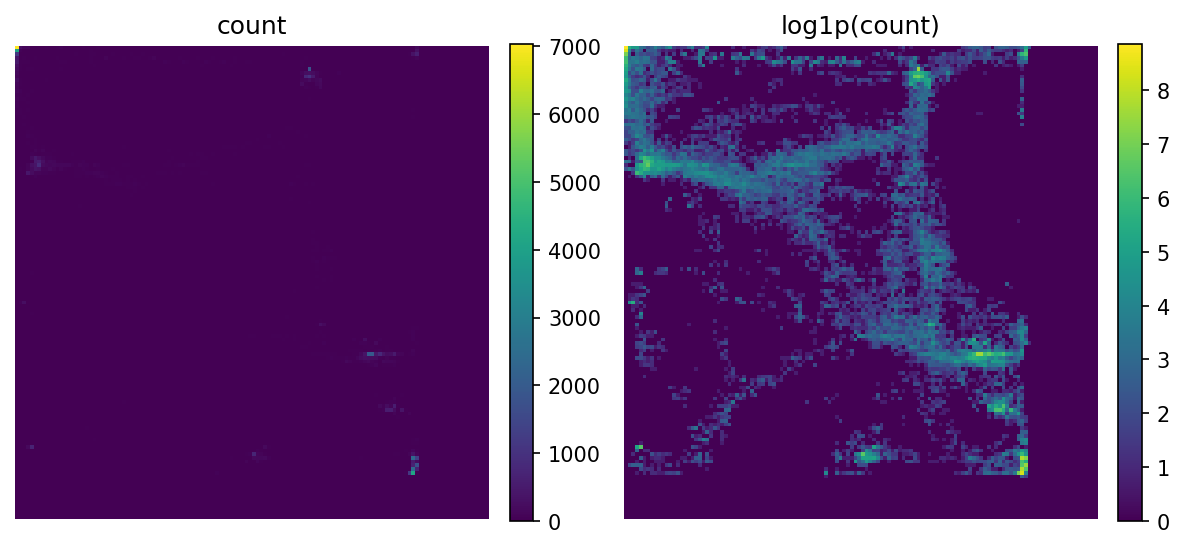

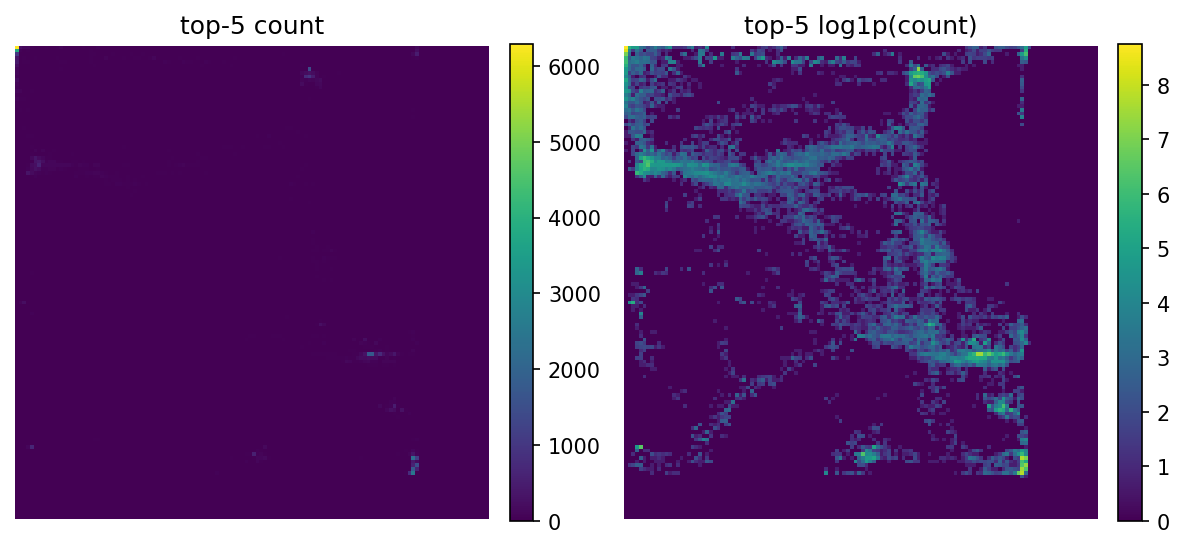

In [19]:
# 1) 기존 plot_xy_heatmaps 대체 (전체 점)
sel, heat, heat_log, fig, axes = plot_xy_heatmaps(xys, mode="all")

# 2) 기존 plot_topk_xy_heatmaps 대체 (프레임별 top-5)
sel, heat, heat_log, fig, axes = plot_xy_heatmaps(xys, mode="topk", k=5)

In [20]:
import pandas as pd
from sklearn.cluster import DBSCAN

def dbscan_cluster_by_frame(
    df,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    eps=4.0,
    min_samples=1,
    coerce_numeric=True,
    dropna=True,
    sort=True,
    out_cluster_col="cluster_id",
):
    """
    frame_col 기준으로 그룹을 나눈 뒤, 각 프레임 내부에서 (x,y)에 DBSCAN을 적용해 cluster_id를 붙여 반환.

    Returns
    -------
    clustered_df : DataFrame
        원본 컬럼 + out_cluster_col (+ frame_col이 group key였더라도 컬럼 유지)
    """
    df2 = df.copy()

    if coerce_numeric:
        df2[x_col] = pd.to_numeric(df2[x_col], errors="coerce")
        df2[y_col] = pd.to_numeric(df2[y_col], errors="coerce")

    if dropna:
        df2 = df2.dropna(subset=[frame_col, x_col, y_col])

    if sort:
        df2 = df2.sort_values([frame_col])

    def _cluster_frame(g: pd.DataFrame) -> pd.DataFrame:
        X = g[[x_col, y_col]].to_numpy(dtype=float)
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        out = g.copy()
        out[out_cluster_col] = labels
        out[frame_col] = g.name  # group key를 컬럼으로 복원(안전)
        return out

    clustered = (
        df2.groupby(frame_col, group_keys=False)
           .apply(_cluster_frame)
           .reset_index(drop=True)
    )
    return clustered

In [21]:
clustered = dbscan_cluster_by_frame(xys, eps=4.0, min_samples=1)
clustered.head()

,x,y,score,cluster_id,image_id
0,0,0,0.796460,0,3
1,108,114,0.732251,1,3
2,0,0,0.796460,0,4
3,108,114,0.732251,1,4
4,0,0,0.796460,0,5


In [22]:
def plot_rep_xy_path(
    df,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
    canvas_size=128,
    figsize=(4, 4),
    dpi=150,
    draw="scatter",      # "scatter" | "line" | "both"
    scatter_s=1,
    scatter_alpha=0.8,
    line_width=0.6,
    line_alpha=0.8,
    show_quiver=False,
    quiver_kwargs=None,
    bg=None,             # None이면 0배경
    cmap="gray",
    bg_vmin=0,
    bg_vmax=1,
):
    """
    frame별 score 최상위 1개(rep)를 뽑아 (x,y) 점/선(옵션)으로 궤적을 그림.
    Returns: rep_df, (fig, ax)
    """
    rep = (
        df.sort_values([frame_col, score_col], ascending=[True, False])
          .groupby(frame_col, as_index=False)
          .first()
    )

    xs = rep[x_col].to_numpy()
    ys = rep[y_col].to_numpy()

    if bg is None:
        bg = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(bg, cmap=cmap, vmin=bg_vmin, vmax=bg_vmax)

    if draw in ("line", "both"):
        ax.plot(xs, ys, linewidth=line_width, alpha=line_alpha, color="white")
    if draw in ("scatter", "both"):
        ax.scatter(xs, ys, s=scatter_s, alpha=scatter_alpha, color="white")

    if show_quiver and len(xs) >= 2:
        x0, y0 = xs[:-1], ys[:-1]
        dx, dy = xs[1:] - xs[:-1], ys[1:] - ys[:-1]
        qkw = dict(
            angles="xy",
            scale_units="xy",
            scale=1,
            width=0.003,
            headwidth=4,
            headlength=5,
            color="white",
            alpha=0.9,
        )
        if quiver_kwargs:
            qkw.update(quiver_kwargs)
        ax.quiver(x0, y0, dx, dy, **qkw)

    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

    return rep, fig, ax

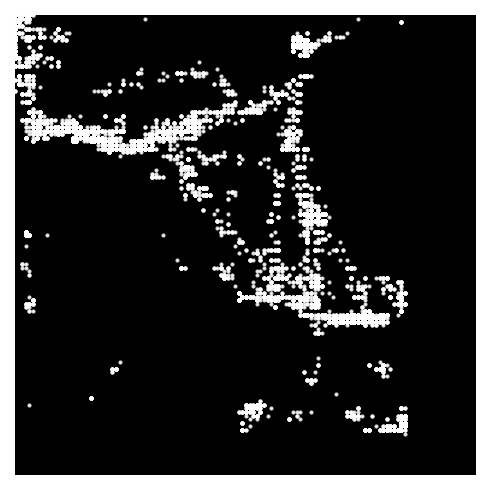

In [23]:
rep, fig, ax = plot_rep_xy_path(clustered, draw="scatter")

In [24]:
def bfill_frames_with_copy(
    df,
    *,
    frame_col="image_id",
    score_col="score",
    frame_start=0,          # 확장 시작 frame
    frame_end=None,         # None이면 max(frame_col)
    sort=True,
    drop_frame_in_records=True,
    mark_filled_score_nan=True,
):
    """
    누락된 frame을 '다음 존재하는 frame의 rows를 복사(bfill)'해서 채운 뒤, 다시 long-form DataFrame으로 풀어준다.
    (원본에 있던 frame은 그대로 유지)

    Parameters
    ----------
    frame_start : int
        확장할 frame 범위 시작.
    frame_end : int | None
        확장할 frame 범위 끝(포함). None이면 df[frame_col].max().
    mark_filled_score_nan : bool
        복사로 생성된 frame의 score_col만 NaN 처리(컬럼이 있을 때만).

    Returns
    -------
    out : DataFrame
        frame_col 포함한 long-form DataFrame
    """
    df2 = df.copy()
    df2[frame_col] = pd.to_numeric(df2[frame_col], errors="coerce")
    df2 = df2.dropna(subset=[frame_col])
    df2[frame_col] = df2[frame_col].astype(int)

    if sort:
        df2 = df2.sort_values(frame_col)

    if frame_end is None:
        frame_end = int(df2[frame_col].max())

    orig_ids = set(df2[frame_col].unique())

    # frame별 rows를 list[dict]로 pack
    def _pack(g):
        gg = g
        if drop_frame_in_records:
            gg = gg.drop(columns=[frame_col], errors="ignore")
        return gg.to_dict("records")

    packed = (
        df2.groupby(frame_col, sort=True)
           .apply(_pack)
           .rename("rows")
           .to_frame()
    )

    # frame range 확장 + bfill
    packed = packed.reindex(range(int(frame_start), int(frame_end) + 1)).bfill()

    # 다시 long-form으로 풀기
    out = packed.reset_index(names=frame_col).explode("rows", ignore_index=True)
    out = pd.concat(
        [out.drop(columns=["rows"]), pd.json_normalize(out["rows"])],
        axis=1
    )

    # 복사로 채워진 frame만 score를 NaN으로
    if mark_filled_score_nan and (score_col in out.columns):
        filled_mask = ~out[frame_col].isin(orig_ids)
        out.loc[filled_mask, score_col] = np.nan

    return out

In [25]:
out = bfill_frames_with_copy(clustered, frame_col="image_id", score_col="score")
out.head(5)

,image_id,x,y,score,cluster_id
0,0,0,0,NaN,0
1,0,108,114,NaN,1
2,1,0,0,NaN,0
3,1,108,114,NaN,1
4,2,0,0,NaN,0


In [26]:
import numpy as np
import matplotlib.pyplot as plt

def compute_rep_steps(
    df,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
):
    """frame별 top-1 대표점(rep)과 프레임간 이동(step)을 계산."""
    rep = (
        df.sort_values([frame_col, score_col], ascending=[True, False])
          .groupby(frame_col, as_index=False)
          .first()
    )
    xs = rep[x_col].to_numpy(float)
    ys = rep[y_col].to_numpy(float)

    dx = xs[1:] - xs[:-1]
    dy = ys[1:] - ys[:-1]
    step = np.hypot(dx, dy)
    return rep, xs, ys, dx, dy, step


def classify_steps(step, *, dist_thr=12, win=8, min_big=2):
    """
    step을 3종류로 분류:
      - blue  : small (<= dist_thr)
      - orange: big   (> dist_thr) but not burst
      - red   : burst big jump (big & big_count>=min_big)
    """
    big = (step > dist_thr).astype(int)
    big_count = np.convolve(big, np.ones(win, dtype=int), mode="same")
    burst = (big == 1) & (big_count >= min_big)

    mask_red = burst
    mask_orange = (~burst) & (step > dist_thr)
    mask_blue = (step <= dist_thr)
    return mask_blue, mask_orange, mask_red


def plot_rep_segments(
    df,
    *,
    # rep 추출
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
    # 분류 파라미터
    dist_thr=12,
    win=8,
    min_big=2,
    # 표시 옵션
    show=("blue", "orange", "red"),   # 그릴 세그먼트 종류
    show_points=True,
    points_kwargs=None,
    line_width=0.3,
    line_alpha=0.9,
    # 배경/캔버스
    canvas_size=128,
    bg=None,
    cmap="gray",
    bg_vmin=0,
    bg_vmax=1,
    figsize=(4, 4),
    dpi=150,
    # quiver
    show_quiver=False,
    quiver_kwargs=None,
    # 기타
    return_masks=True,
):
    """
    1) frame별 top-1 rep 궤적을 만든다
    2) dist_thr/win/min_big로 blue/orange/red 세그먼트를 분류한다
    3) 선택된 show 종류만 그린다(점은 옵션)

    Returns
    -------
    result : dict (optional masks 포함)
    """
    rep, xs, ys, dx, dy, step = compute_rep_steps(
        df, frame_col=frame_col, x_col=x_col, y_col=y_col, score_col=score_col
    )
    mask_blue, mask_orange, mask_red = classify_steps(
        step, dist_thr=dist_thr, win=win, min_big=min_big
    )

    # 색 매핑 (원 코드 기준)
    colors = {"blue": "blue", "orange": "orange", "red": "red"}
    masks = {"blue": mask_blue, "orange": mask_orange, "red": mask_red}

    if bg is None:
        bg = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.imshow(bg, cmap=cmap, vmin=bg_vmin, vmax=bg_vmax)

    if show_points:
        pk = dict(s=1, color="white", alpha=0.5)
        if points_kwargs:
            pk.update(points_kwargs)
        ax.scatter(xs, ys, **pk)

    # 세그먼트 그리기 (i = 0..len(step)-1)
    show_set = set(show)
    for key in ("red", "orange", "blue"):
        if key not in show_set:
            continue
        m = masks[key]
        idxs = np.where(m)[0]
        for i in idxs:
            ax.plot(xs[i:i+2], ys[i:i+2], linewidth=line_width, color=colors[key], alpha=line_alpha)

    if show_quiver and len(step) > 0:
        # show에 포함된 세그먼트만 quiver로 표시
        qmask = np.zeros_like(step, dtype=bool)
        for key in show_set:
            if key in masks:
                qmask |= masks[key]
        qkw = dict(
            angles="xy", scale_units="xy", scale=1,
            width=0.003, headwidth=1, headlength=1,
            alpha=0.9
        )
        if quiver_kwargs:
            qkw.update(quiver_kwargs)
        ax.quiver(xs[:-1][qmask], ys[:-1][qmask], dx[qmask], dy[qmask],
                  color="white", **qkw)

    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

    result = {"rep": rep, "xs": xs, "ys": ys, "step": step, "fig": fig, "ax": ax}
    if return_masks:
        result.update(
            mask_blue=mask_blue,
            mask_orange=mask_orange,
            mask_red=mask_red,
            counts=dict(
                blue=int(mask_blue.sum()),
                orange=int(mask_orange.sum()),
                red=int(mask_red.sum()),
                total=int(len(step)),
            ),
            ratios=dict(
                blue=float(mask_blue.sum() / max(len(step), 1)),
                orange=float(mask_orange.sum() / max(len(step), 1)),
                red=float(mask_red.sum() / max(len(step), 1)),
            ),
        )
    return result

In [27]:
def interactive_rep_segments(
    df,
    *,
    dist_thr=12,
    win=8,
    min_big=2,
    **plot_kwargs,
):
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    show_blue   = widgets.Checkbox(value=True,  description="blue (small)")
    show_orange = widgets.Checkbox(value=True,  description="orange (big)")
    show_red    = widgets.Checkbox(value=True,  description="red (burst)")
    ui = widgets.HBox([show_blue, show_orange, show_red])
    out_area = widgets.Output()

    def draw(*_):
        with out_area:
            clear_output(wait=True)
            show = []
            if show_blue.value:   show.append("blue")
            if show_orange.value: show.append("orange")
            if show_red.value:    show.append("red")

            res = plot_rep_segments(
                df,
                dist_thr=dist_thr, win=win, min_big=min_big,
                show=tuple(show),
                **plot_kwargs,
            )

            c = res["counts"]; r = res["ratios"]; total = max(c["total"], 1)
            print("segments count")
            print(f"  blue  (small) : {c['blue']}")
            print(f"  orange(big)   : {c['orange']}")
            print(f"  red   (burst) : {c['red']}")
            print(f"  total         : {c['total']}")
            print("ratio (%)")
            print(f"  blue  : {100*r['blue']:.2f}")
            print(f"  orange: {100*r['orange']:.2f}")
            print(f"  red   : {100*r['red']:.2f}")

    for w in (show_blue, show_orange, show_red):
        w.observe(draw, names="value")

    display(ui, out_area)
    draw()
    return ui, out_area

In [28]:
# # 정적 플롯(세그먼트 3색 모두)
# res = plot_rep_segments(out, dist_thr=12, win=8, min_big=2, show=("blue","orange","red"))

# 토글 UI
interactive_rep_segments(out, dist_thr=12, win=8, min_big=2, line_width=0.3)

Output()

(HBox(children=(Checkbox(value=True, description='blue (small)'), Checkbox(value=True, description='orange (big)'), Checkbox(value=True, description='red (burst)'))),
 Output())

In [29]:
def _pairwise_l2(a, b):
    # a: (M,2), b: (N,2) -> (M,N)
    aa = (a**2).sum(1, keepdims=True)
    bb = (b**2).sum(1, keepdims=True).T
    ab = a @ b.T
    d2 = np.maximum(aa + bb - 2*ab, 0.0)
    return np.sqrt(d2)


In [30]:
def _bbox_iou_matrix(A, B):
    """
    A: (M,4) [x1,y1,x2,y2], B: (N,4)
    return: (M,N) IoU
    """
    if len(A) == 0 or len(B) == 0:
        return np.zeros((len(A), len(B)), dtype=float)

    ax1, ay1, ax2, ay2 = A[:,0:1], A[:,1:2], A[:,2:3], A[:,3:4]
    bx1, by1, bx2, by2 = B[:,0][None,:], B[:,1][None,:], B[:,2][None,:], B[:,3][None,:]

    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = np.maximum(0.0, ax2 - ax1) * np.maximum(0.0, ay2 - ay1)
    area_b = np.maximum(0.0, bx2 - bx1) * np.maximum(0.0, by2 - by1)

    union = area_a + area_b - inter + 1e-9
    return (inter / union)


In [31]:
# --------------------------
# 0) 유틸: 거리 / IoU
# --------------------------
def _pairwise_l2(a, b):
    # a: (M,2), b: (N,2) -> (M,N)
    aa = (a**2).sum(1, keepdims=True)
    bb = (b**2).sum(1, keepdims=True).T
    ab = a @ b.T
    d2 = np.maximum(aa + bb - 2*ab, 0.0)
    return np.sqrt(d2)

def _bbox_iou_matrix(A, B):
    """
    A: (M,4) [x1,y1,x2,y2], B: (N,4)
    return: (M,N) IoU
    """
    if len(A) == 0 or len(B) == 0:
        return np.zeros((len(A), len(B)), dtype=float)

    ax1, ay1, ax2, ay2 = A[:,0:1], A[:,1:2], A[:,2:3], A[:,3:4]
    bx1, by1, bx2, by2 = B[:,0][None,:], B[:,1][None,:], B[:,2][None,:], B[:,3][None,:]

    inter_x1 = np.maximum(ax1, bx1)
    inter_y1 = np.maximum(ay1, by1)
    inter_x2 = np.minimum(ax2, bx2)
    inter_y2 = np.minimum(ay2, by2)

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = np.maximum(0.0, ax2 - ax1) * np.maximum(0.0, ay2 - ay1)
    area_b = np.maximum(0.0, bx2 - bx1) * np.maximum(0.0, by2 - by1)

    union = area_a + area_b - inter + 1e-9
    return (inter / union)

In [32]:
# --------------------------
# 1) 프레임별 DBSCAN
# --------------------------
def _dbscan_per_frame(df, frame_col, x_col, y_col, eps, min_samples):
    df2 = df.copy()
    df2[x_col] = pd.to_numeric(df2[x_col], errors="coerce")
    df2[y_col] = pd.to_numeric(df2[y_col], errors="coerce")
    df2[frame_col] = pd.to_numeric(df2[frame_col], errors="coerce")
    df2 = df2.dropna(subset=[frame_col, x_col, y_col])
    df2[frame_col] = df2[frame_col].astype(int)
    df2 = df2.sort_values([frame_col])

    out = []
    for fid, g in df2.groupby(frame_col, sort=True):
        X = g[[x_col, y_col]].to_numpy(float)
        local = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)  # -1 noise 포함
        gg = g.copy()
        gg["_local"] = local
        out.append(gg)
    return pd.concat(out, ignore_index=True)


In [33]:
# --------------------------
# 2) 클러스터 요약(centroid / bbox)
# --------------------------
def _summarize_clusters(g, x_col, y_col, local_col="_local", drop_noise=True):
    """
    g: 특정 frame의 rows
    return: summary_df with columns: _local, cx, cy, x1,y1,x2,y2, n
    """
    gg = g
    if drop_noise:
        gg = gg[gg[local_col] != -1]
    if len(gg) == 0:
        return pd.DataFrame(columns=[local_col,"cx","cy","x1","y1","x2","y2","n"])

    rows = []
    for cid, h in gg.groupby(local_col, sort=True):
        xs = h[x_col].to_numpy(float)
        ys = h[y_col].to_numpy(float)
        rows.append({
            local_col: int(cid),
            "cx": float(xs.mean()),
            "cy": float(ys.mean()),
            "x1": float(xs.min()),
            "y1": float(ys.min()),
            "x2": float(xs.max()),
            "y2": float(ys.max()),
            "n": int(len(h)),
        })
    return pd.DataFrame(rows)

In [34]:
# --------------------------
# 3) 매칭( greedy / hungarian )
# --------------------------
def _match_greedy(cost, valid_mask=None):
    """
    cost: (M,N) 작은게 좋은 비용
    valid_mask: (M,N) True만 허용 (게이팅)
    return pairs list of (i,j)
    """
    M, N = cost.shape
    if M == 0 or N == 0:
        return []
    if valid_mask is None:
        valid_mask = np.ones_like(cost, dtype=bool)

    # 허용되는 후보만 펼쳐서 비용순 정렬
    ii, jj = np.where(valid_mask)
    if len(ii) == 0:
        return []
    order = np.argsort(cost[ii, jj])
    used_i = set()
    used_j = set()
    pairs = []
    for k in order:
        i = int(ii[k]); j = int(jj[k])
        if i in used_i or j in used_j:
            continue
        pairs.append((i, j))
        used_i.add(i); used_j.add(j)
    return pairs

def _match_hungarian(cost, valid_mask=None):
    """
    cost: (M,N)
    valid_mask: (M,N) 게이팅 (False는 매우 큰 비용)
    """
    M, N = cost.shape
    if M == 0 or N == 0:
        return []
    if valid_mask is None:
        valid_mask = np.ones_like(cost, dtype=bool)

    big = cost.max() + 1e6
    cost2 = cost.copy()
    cost2[~valid_mask] = big

    try:
        from scipy.optimize import linear_sum_assignment
        r, c = linear_sum_assignment(cost2)
        pairs = [(int(i), int(j)) for i, j in zip(r, c) if valid_mask[i, j]]
        return pairs
    except Exception:
        # scipy 없거나 실패하면 greedy 폴백
        return _match_greedy(cost, valid_mask=valid_mask)

In [35]:
# --------------------------
# 4) 메인: temporal cluster_id 부여
# --------------------------
def dbscan_track_clusters(
    df,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    eps=4.0,
    min_samples=1,
    # 매칭 옵션
    metric="centroid",         # "centroid" | "bbox_iou"
    matcher="greedy",          # "greedy" | "hungarian"
    max_link_dist=6.0,         # metric="centroid"일 때 게이팅
    min_iou=0.1,               # metric="bbox_iou"일 때 게이팅
    # noise 처리
    drop_noise_in_tracking=True,   # noise(-1)는 추적 제외
    noise_policy="new_id",         # "new_id" | "keep_-1"
    out_cluster_col="cluster_id",
):
    """
    프레임별 DBSCAN으로 local cluster 생성 후, 이전 프레임과 매칭해 global cluster_id(=track id)를 부여.
    """
    df_loc = _dbscan_per_frame(df, frame_col, x_col, y_col, eps, min_samples)

    # 매칭 함수 선택
    match_fn = _match_hungarian if matcher == "hungarian" else _match_greedy
    if metric not in ("centroid", "bbox_iou"):
        raise ValueError('metric must be "centroid" or "bbox_iou"')
    if matcher not in ("greedy", "hungarian"):
        raise ValueError('matcher must be "greedy" or "hungarian"')
    if noise_policy not in ("new_id", "keep_-1"):
        raise ValueError('noise_policy must be "new_id" or "keep_-1"')

    df_loc[out_cluster_col] = -1

    next_gid = 0
    prev_summary = None   # DataFrame: prev clusters summary + gid
    prev_gids = None      # np array aligned with prev_summary rows

    for fid, g in df_loc.groupby(frame_col, sort=True):
        # 현재 프레임 local cluster 요약
        cur_sum = _summarize_clusters(g, x_col, y_col, local_col="_local",
                                     drop_noise=drop_noise_in_tracking)
        if len(cur_sum) == 0:
            # 클러스터가 없으면 noise만 처리
            if noise_policy == "new_id":
                idx = g.index.to_numpy()
                is_noise = (g["_local"].to_numpy() == -1)
                gids = np.full(len(g), -1, dtype=int)
                for i in np.where(is_noise)[0]:
                    gids[i] = next_gid; next_gid += 1
                df_loc.loc[idx, out_cluster_col] = gids
            else:
                # keep_-1: 그대로 -1
                df_loc.loc[g.index, out_cluster_col] = -1
            prev_summary, prev_gids = None, None
            continue

        # 매칭으로 local->global 매핑 만들기
        local_to_gid = {}

        if prev_summary is None or len(prev_summary) == 0:
            # 첫 프레임(또는 이전 프레임에 클러스터 없음): 전부 새 ID
            for cid in cur_sum["_local"].to_numpy(int):
                local_to_gid[int(cid)] = next_gid
                next_gid += 1
        else:
            if metric == "centroid":
                A = cur_sum[["cx","cy"]].to_numpy(float)
                B = prev_summary[["cx","cy"]].to_numpy(float)
                cost = _pairwise_l2(A, B)  # 거리=비용
                valid = cost <= max_link_dist
            else:  # bbox_iou
                A = cur_sum[["x1","y1","x2","y2"]].to_numpy(float)
                B = prev_summary[["x1","y1","x2","y2"]].to_numpy(float)
                iou = _bbox_iou_matrix(A, B)
                cost = 1.0 - iou          # iou 최대화 <-> cost 최소화
                valid = iou >= min_iou

            pairs = match_fn(cost, valid_mask=valid)

            used_cur = set()
            used_prev = set()
            for i, j in pairs:
                cid = int(cur_sum.iloc[i]["_local"])
                gid = int(prev_gids[j])
                local_to_gid[cid] = gid
                used_cur.add(i); used_prev.add(j)

            # 매칭 안 된 현재 클러스터는 새 ID
            for i, cid in enumerate(cur_sum["_local"].to_numpy(int)):
                if i not in used_cur:
                    local_to_gid[int(cid)] = next_gid
                    next_gid += 1

        # 현재 프레임의 각 row에 global id 부여
        idx = g.index.to_numpy()
        local = g["_local"].to_numpy(int)
        gids = np.full(len(g), -1, dtype=int)

        for i, cid in enumerate(local):
            if cid == -1:
                if noise_policy == "new_id":
                    gids[i] = next_gid; next_gid += 1
                else:
                    gids[i] = -1
            else:
                gids[i] = local_to_gid[int(cid)]

        df_loc.loc[idx, out_cluster_col] = gids

        # 다음 프레임을 위한 prev_summary 갱신: gid 붙여 저장
        prev_summary = cur_sum.copy()
        prev_gids = np.array([local_to_gid[int(cid)] for cid in prev_summary["_local"].to_numpy(int)], dtype=int)

    return df_loc.drop(columns=["_local"], errors="ignore")

In [36]:
def plot_tracks_by_cluster_id_ax(
    tracked,
    ax,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    cid_col="cluster_id",
    canvas_size=128,
    bg=None,
    cmap="gray",
    bg_vmin=0,
    bg_vmax=1,
    # 표시 옵션
    draw_points=True,
    point_s=2,
    point_alpha=0.6,
    draw_lines=True,
    line_width=0.4,
    line_alpha=0.8,
    # 필터
    keep_cids=None,
    drop_cid_values=(-1,),
    max_tracks=None,
):
    df = tracked.copy()
    if drop_cid_values is not None:
        df = df[~df[cid_col].isin(drop_cid_values)]
    if keep_cids is not None:
        df = df[df[cid_col].isin(set(keep_cids))]
    if max_tracks is not None:
        top = df[cid_col].value_counts().head(max_tracks).index
        df = df[df[cid_col].isin(top)]

    if bg is None:
        bg = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    ax.imshow(bg, cmap=cmap, vmin=bg_vmin, vmax=bg_vmax)

    for cid, g in df.sort_values(frame_col).groupby(cid_col, sort=True):
        xs = g[x_col].to_numpy(float)
        ys = g[y_col].to_numpy(float)

        if draw_lines and len(xs) >= 2:
            ax.plot(xs, ys, linewidth=line_width, alpha=line_alpha)
        if draw_points:
            ax.scatter(xs, ys, s=point_s, alpha=point_alpha)

    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

In [37]:
def plot_frame_rep_points_with_cluster_ax(
    tracked,
    ax,
    *,
    rep="top1",               # "top1" | "centroid"
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
    cid_col="cluster_id",
    canvas_size=128,
    bg=None,
    cmap="gray",
    bg_vmin=0,
    bg_vmax=1,
    drop_cid_values=(-1,),
):
    df = tracked.copy()
    if drop_cid_values is not None and cid_col in df.columns:
        df = df[~df[cid_col].isin(drop_cid_values)]

    if rep == "top1":
        rep_df = (df.sort_values([frame_col, score_col], ascending=[True, False])
                    .groupby(frame_col, as_index=False)
                    .first())
        # top1은 프레임당 1점이라 cid별 색 구분 이점이 작을 수 있음(그래도 가능)
        if cid_col in rep_df.columns:
            for cid, g in rep_df.groupby(cid_col, sort=True):
                ax.scatter(g[x_col], g[y_col], s=4, alpha=0.8)
        else:
            ax.scatter(rep_df[x_col], rep_df[y_col], s=4, alpha=0.8)

    elif rep == "centroid":
        # 프레임별/클러스터별 centroid 점
        rep_df = (df.groupby([frame_col, cid_col], as_index=False)[[x_col, y_col]].mean())
        for cid, g in rep_df.groupby(cid_col, sort=True):
            ax.scatter(g[x_col], g[y_col], s=4, alpha=0.8)
    else:
        raise ValueError('rep must be "top1" or "centroid"')

    if bg is None:
        bg = np.zeros((canvas_size, canvas_size), dtype=np.uint8)

    ax.imshow(bg, cmap=cmap, vmin=bg_vmin, vmax=bg_vmax)

    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    return rep_df, ax

In [38]:
def _bg_imshow(ax, canvas_size=128, bg=None, cmap="gray", vmin=0, vmax=1):
    if bg is None:
        bg = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    ax.imshow(bg, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xlim(0, canvas_size)
    ax.set_ylim(canvas_size, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

In [39]:
def plot_cluster_centroid_tracks_ax(
    tracked,
    ax,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    cid_col="cluster_id",
    drop_cid_values=(-1,),
    max_tracks=30,             # centroid track too many -> limit
    canvas_size=128,
    bg=None, cmap="gray", bg_vmin=0, bg_vmax=1,
    draw_lines=True, line_width=0.6, line_alpha=0.9,
    draw_points=True, point_s=6, point_alpha=0.8,
):
    """
    cluster_id별로 (frame마다) centroid를 계산해서 그 centroid 궤적을 그림.
    """
    df = tracked.copy()
    if drop_cid_values is not None:
        df = df[~df[cid_col].isin(drop_cid_values)]
    if max_tracks is not None:
        top = df[cid_col].value_counts().head(max_tracks).index
        df = df[df[cid_col].isin(top)]

    # frame별/cluster별 centroid
    ctr = (df.groupby([frame_col, cid_col], as_index=False)[[x_col, y_col]].mean()
             .sort_values([cid_col, frame_col]))

    _bg_imshow(ax, canvas_size, bg, cmap, bg_vmin, bg_vmax)

    for cid, g in ctr.groupby(cid_col, sort=True):
        xs = g[x_col].to_numpy(float)
        ys = g[y_col].to_numpy(float)
        if draw_lines and len(xs) >= 2:
            ax.plot(xs, ys, linewidth=line_width, alpha=line_alpha)
        if draw_points:
            ax.scatter(xs, ys, s=point_s, alpha=point_alpha)

    return ctr, ax

In [40]:
def plot_frame_topk_points_ax(
    tracked,
    ax,
    *,
    k=5,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
    cid_col="cluster_id",
    drop_cid_values=(-1,),
    canvas_size=128,
    bg=None, cmap="gray", bg_vmin=0, bg_vmax=1,
    s=3, alpha=0.7,
):
    """
    frame별 score 상위 k개 점을 찍음(클러스터 색 자동).
    """
    df = tracked.copy()
    if drop_cid_values is not None and cid_col in df.columns:
        df = df[~df[cid_col].isin(drop_cid_values)]

    df2 = df.sort_values([frame_col, score_col], ascending=[True, False])
    topk = df2.groupby(frame_col, sort=False).head(k)

    _bg_imshow(ax, canvas_size, bg, cmap, bg_vmin, bg_vmax)

    if cid_col in topk.columns:
        for cid, g in topk.groupby(cid_col, sort=True):
            ax.scatter(g[x_col], g[y_col], s=s, alpha=alpha)
    else:
        ax.scatter(topk[x_col], topk[y_col], s=s, alpha=alpha)

    return topk, ax

In [41]:
def plot_track_size_bar_ax(
    tracked,
    ax,
    *,
    cid_col="cluster_id",
    drop_cid_values=(-1,),
    top_n=20,
):
    """
    cluster_id별 점 개수(=track 길이) 상위 N개 bar.
    """
    df = tracked.copy()
    if drop_cid_values is not None:
        df = df[~df[cid_col].isin(drop_cid_values)]

    counts = df[cid_col].value_counts().head(top_n)
    ax.bar(np.arange(len(counts)), counts.to_numpy())
    ax.set_xticks(np.arange(len(counts)))
    ax.set_xticklabels(counts.index.to_numpy(), rotation=90)
    ax.set_ylabel("count")
    ax.set_xlabel("cluster_id")
    return counts, ax

In [42]:
def plot_rep_step_timeseries_ax(
    df,
    ax,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
    thr=12,
):
    """
    frame별 top1 대표점(rep)의 step(프레임간 이동거리) 시계열.
    """
    rep = (df.sort_values([frame_col, score_col], ascending=[True, False])
             .groupby(frame_col, as_index=False)
             .first())
    xs = rep[x_col].to_numpy(float)
    ys = rep[y_col].to_numpy(float)

    step = np.hypot(xs[1:] - xs[:-1], ys[1:] - ys[:-1])
    ax.plot(step, linewidth=0.8)
    ax.axhline(thr, linewidth=0.8)
    ax.set_ylabel("step")
    ax.set_xlabel("t (segment index)")
    return rep, step, ax

In [43]:
def plot_step_hist_ax(
    df,
    ax,
    *,
    frame_col="image_id",
    x_col="x",
    y_col="y",
    score_col="score",
    bins=50,
    thr=12,
):
    rep = (df.sort_values([frame_col, score_col], ascending=[True, False])
             .groupby(frame_col, as_index=False)
             .first())
    xs = rep[x_col].to_numpy(float)
    ys = rep[y_col].to_numpy(float)
    step = np.hypot(xs[1:] - xs[:-1], ys[1:] - ys[:-1])

    ax.hist(step, bins=bins)
    ax.axvline(thr, linewidth=0.8)
    ax.set_xlabel("step")
    ax.set_ylabel("count")
    return rep, step, ax


In [44]:
def plot_tracking_panel_1x4(
    tracked,
    *,
    # 공통 캔버스 옵션(각 plot_*_ax 함수에 전달)
    canvas_size=128,
    bg=None,
    cmap="gray",
    bg_vmin=0,
    bg_vmax=1,
    drop_cid_values=(-1,),
    # top-k
    topk=5,
    # track 제한(필요하면)
    max_tracks_points=None,
    max_tracks_centroids=None,
    # figure
    figsize=(15, 3),
    dpi=300,
    # title
    suptitle=None,
    suptitle_y=1.02,
):
    """
    1x4 패널:
      [0] tracks(points)
      [1] tracks(centroids)
      [2] frame rep: top1
      [3] frame top-k
    """
    fig, axes = plt.subplots(1, 4, figsize=figsize, dpi=dpi)

    # 0) raw tracks
    plot_tracks_by_cluster_id_ax(
        tracked, axes[0],
        canvas_size=canvas_size, bg=bg, cmap=cmap, bg_vmin=bg_vmin, bg_vmax=bg_vmax,
        drop_cid_values=drop_cid_values,
        max_tracks=max_tracks_points,
    )
    axes[0].set_title("tracks (points)")

    # 1) centroid tracks
    plot_cluster_centroid_tracks_ax(
        tracked, axes[1],
        canvas_size=canvas_size, bg=bg, cmap=cmap, bg_vmin=bg_vmin, bg_vmax=bg_vmax,
        drop_cid_values=drop_cid_values,
        max_tracks=max_tracks_centroids,
    )
    axes[1].set_title("tracks (centroids)")

    # 2) frame rep top1
    rep_top1, _ = plot_frame_rep_points_with_cluster_ax(
        tracked, axes[2],
        rep="top1",
        canvas_size=canvas_size, bg=bg, cmap=cmap, bg_vmin=bg_vmin, bg_vmax=bg_vmax,
        drop_cid_values=drop_cid_values,
    )
    axes[2].set_title("frame rep: top1")

    # 3) frame top-k
    topk_df, _ = plot_frame_topk_points_ax(
        tracked, axes[3],
        k=topk,
        canvas_size=canvas_size, bg=bg, cmap=cmap, bg_vmin=bg_vmin, bg_vmax=bg_vmax,
        drop_cid_values=drop_cid_values,
    )
    axes[3].set_title(f"frame top-{topk}")

    if suptitle is not None:
        fig.suptitle(suptitle, y=suptitle_y)

    plt.tight_layout()
    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "rep_top1": rep_top1,
        "topk": topk_df,
    }


In [45]:
# centroid 거리 최소 매칭 (greedy)
tracked_centroid_greedy = dbscan_track_clusters(
    clustered, eps=4.0, min_samples=1,
    metric="centroid", matcher="greedy",
    max_link_dist=6.0
)

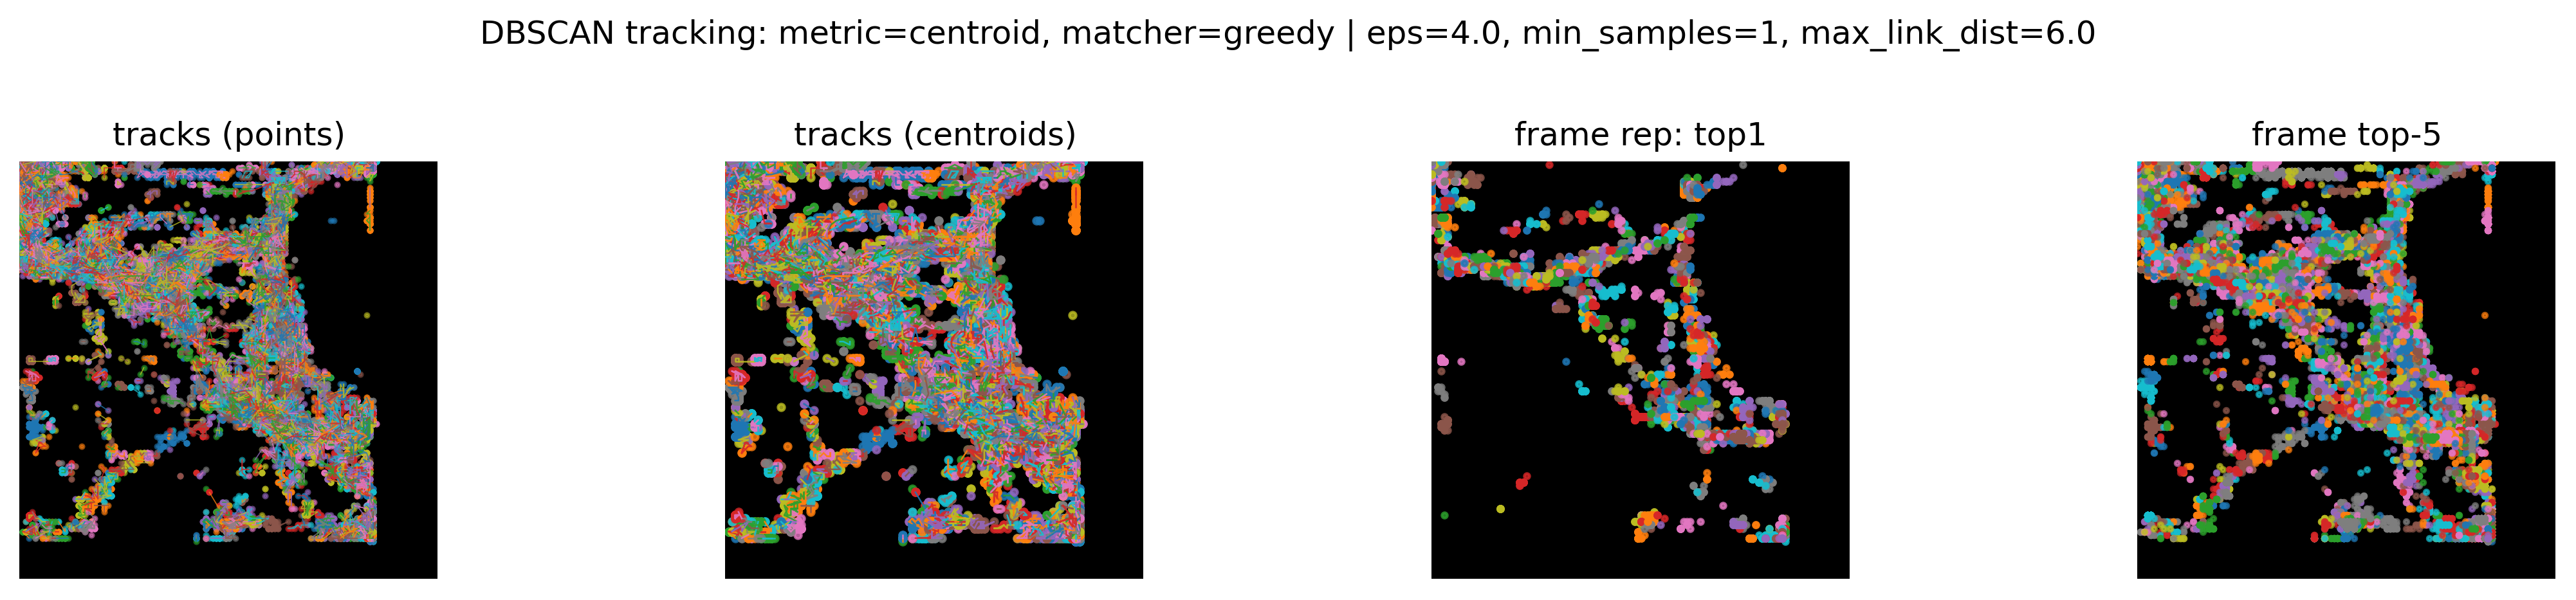

In [213]:
res_centroid_greedy = plot_tracking_panel_1x4(
    tracked_centroid_greedy,
    topk=5,
    suptitle="DBSCAN tracking: metric=centroid, matcher=greedy | eps=4.0, min_samples=1, max_link_dist=6.0",
)


In [214]:
# bbox IoU 기반 매칭 (greedy)
tracked_bbox_iou_greedy = dbscan_track_clusters(
    clustered, eps=4.0, min_samples=1,
    metric="bbox_iou", matcher="greedy",
    min_iou=0.1
)


In [ ]:
res_bbox_iou_greedy = plot_tracking_panel_1x4(
    tracked_bbox_iou_greedy,
    topk=5,
    suptitle="DBSCAN tracking: metric=bbox_iou, matcher=greedy | eps=4.0, min_samples=1, min_iou=0.1",
)


In [ ]:
# Hungarian assignment (centroid or IoU 둘 다 가능)
tracked_centroid_hungarian = dbscan_track_clusters(
    clustered, eps=4.0, min_samples=1,
    metric="centroid", matcher="hungarian",
    max_link_dist=6.0
)
# 또는 bbox_iou + hungarian

In [ ]:
res_centroid_hungarian = plot_tracking_panel_1x4(
    tracked,
    topk=5,
    suptitle="DBSCAN tracking: metric=centroid, matcher=hungarian | eps=4.0, min_samples=1, max_link_dist=6.0"
)
